Modularized code

In [ ]:
code = """
import cupy as cp
from cupyx.scipy.ndimage import gaussian_filter, center_of_mass, map_coordinates
import numpy as np
import matplotlib.pyplot as plt
import gc


class aberration:
    #A class describing electron lens aberrations.

    def __init__(self, Krivanek, Haider, Description, amplitude, angle, n, m):
        self.Krivanek = Krivanek
        self.Haider = Haider
        self.Description = Description
        self.amplitude = amplitude
        self.m = m
        self.n = n
        if m > 0:
            self.angle = angle
        else:
            self.angle = 0

    def __str__(self):
        if self.m > 0:
            return (
                "{0:17s} ({1:2s}) -- {2:3s} = {3:9.2e} \u00E5 \u03B8 = "
                + "{4:4d}\u00B0 "
            ).format(
                self.Description,
                self.Haider,
                self.Krivanek,
                self.amplitude,
                int(cp.rad2deg(self.angle)),
            )
        else:
            return " {0:17s} ({1:2s}) -- {2:3s} = {3:9.2e} \u00E5".format(
                self.Description, self.Haider, self.Krivanek, self.amplitude
            )

def chi(q, qphi, lam, df=0.0, aberrations=[]):
    qlam = q * lam
    chi_ = qlam ** 2 / 2 * df
    for ab in aberrations:
        chi_ += (
            qlam ** (ab.n + 1)
            * ab.amplitude
            / (ab.n + 1)
            * cp.cos(ab.m * (qphi - ab.angle))
        )
    return 2 * cp.pi * chi_ / lam

def wavev(E):
    #
    #Evaluate the relativistically corrected wavenumber of an electron with energy E.
    #Energy E must be in electron-volts, see Eq. (2.5) in Kirkland's Advanced
    #Computing in electron microscopy

    # Planck's constant times speed of light in eV Angstrom
    hc = 1.23984193e4
    # Electron rest mass in eV
    m0c2 = 5.109989461e5
    return cp.sqrt(E * (E + 2 * m0c2)) / hc

def convert_tilt_angles(tilt, tilt_units, rsize, eV, invA_out=False):

    # Convert  tilt to pixel or inverse Angstroms units regardless of input units.
    # Input units can be mrad, pixels or inverse Angstrom
    # Parameters
    # ----------
    # tilt : array_like
    #     Tilt in units of mrad, pixels or inverse Angstrom
    # tilt_units : string
    #     Units of specimen and beam tilt, can be 'mrad','pixels' or 'invA'
    # rsize : (2,) array_like
    #     The size of the grid in Angstrom
    # eV : float
    #     Probe energy in electron volts
    # invA_out : bool
    #     Pass True if inverse Angstrom units are desired.

    # If units of the tilt are given in mrad, convert to inverse Angstrom
    if tilt_units == "mrad":
        k = wavev(eV)
        tilt_ = cp.asarray(tilt) * 1e-3 * k
    else:
        tilt_ = tilt

    # If inverse Angstroms are requested our work here is done
    if invA_out:
        return tilt_

    # Convert inverse Angstrom to pixel coordinates, this will be rounded
    # to the nearest pixel
    if tilt_units != "pixels":
        tilt_ = cp.round(tilt_ * rsize[:2]).astype(int)
    return tilt_

# def q_space_array(pix_dim, real_dim):
#     qx = cp.fft.fftfreq(pix_dim[0], real_dim[0] / pix_dim[0])
#     qy = cp.fft.fftfreq(pix_dim[1], real_dim[1] / pix_dim[1])
#     q = cp.meshgrid(qx, qy, indexing="ij")
#     return q
def q_space_array(pixels, gridsize):

    # Return the appropriately scaled 2D reciprocal space coordinates.

    # Parameters
    # -----------
    # pixels : (2,) array_like
    #     Pixels in each dimension of a 2D array
    # gridsize : (2,) array_like
    #     Dimensions of the array in real space units

    qspace = [cp.fft.fftfreq(pixels[i], d=gridsize[i] / pixels[i]) for i in [0, 1]]
    return [
        cp.broadcast_to(q, pixels) for q in [qspace[0][:, None], qspace[1][None, :]]
    ]

def make_contrast_transfer_function(
    pix_dim,
    real_dim,
    eV,
    app,
    optic_axis=[0, 0],
    aperture_shift=[0, 0],
    tilt_units="mrad",
    df=100,
    C1_offset_sequence=None,
    A3_amp_sequence=None,
    A2_amp_sequence=None,
    C1_sequence=None,
    C3_sequence=None,
    A1_amp_sequence=None,
    A1_phase_sequence=None,
    A2_phase_sequence=None,
    A3_phase_sequence=None,
    q=None,
    app_units="mrad",
    batch_index=0,
    batch_size=2880
):
    if q is None:
        q = q_space_array(pix_dim, real_dim[:2])
    k = wavev(eV)

    optic_axis_ = convert_tilt_angles(
        optic_axis, tilt_units, real_dim, eV, invA_out=True
    )
    aperture_shift_ = convert_tilt_angles(
        aperture_shift, tilt_units, real_dim, eV, invA_out=True
    )

    if app is None:
        app_ = cp.amax(cp.abs(q))
    else:
        app_ = convert_tilt_angles(app, app_units, real_dim, eV, invA_out=True)

    total_combinations = (len(C1_offset_sequence) *
                          len(A3_amp_sequence) *
                          len(A2_amp_sequence) *
                          len(C1_sequence) *
                          len(C3_sequence) *
                          len(A1_amp_sequence) *
                          len(A1_phase_sequence) *
                          len(A2_phase_sequence) *
                          len(A3_phase_sequence))

    # Calculate start and end indices for the current batch
    start_index = batch_index * batch_size
    end_index = min(start_index + batch_size, total_combinations)

    # Initialize the tensor for the current batch
    batch_size_actual = end_index - start_index
    CTF_shape = (pix_dim[0], pix_dim[1], batch_size_actual)
    CTF_tensor = cp.zeros(CTF_shape, dtype=complex)
    chi_temp = cp.zeros(pix_dim, dtype=complex)

    qarray1 = cp.sqrt(
        cp.square(q[0] - optic_axis_[0]) + cp.square(q[1] - optic_axis_[1])
    )

    qarray2 = cp.square(q[0] - optic_axis_[0] - aperture_shift_[0]) + cp.square(
        q[1] - optic_axis_[1] - aperture_shift_[1]
    )

    qphi = cp.arctan2(q[0] - optic_axis_[0], q[1] - optic_axis_[1])

    # Calculate the mask for the aperture region
    mask = qarray2 <= app_ ** 2

    # Create a meshgrid of all parameter combinations
    C1_offsets, A3_amps, A2_amps, C1s, C3s, A1_amps, A1_phases, A2_phases, A3_phases = cp.meshgrid(
        C1_offset_sequence,
        A3_amp_sequence,
        A2_amp_sequence,
        C1_sequence,
        C3_sequence,
        A1_amp_sequence,
        A1_phase_sequence,
        A2_phase_sequence,
        A3_phase_sequence,
        indexing="ij",
    )

    # Flatten the meshgrid outputs
    C1_offsets_flat = C1_offsets.ravel()
    A3_amps_flat = A3_amps.ravel()
    A2_amps_flat = A2_amps.ravel()
    C1s_flat = C1s.ravel()
    C3s_flat = C3s.ravel()
    A1_amps_flat = A1_amps.ravel()
    A1_phases_flat = A1_phases.ravel()
    A2_phases_flat = A2_phases.ravel()
    A3_phases_flat = A3_phases.ravel()

    # Process the batch
    for i in range(start_index, end_index):
        aberrations = [
            aberration("C1", "C1", "Defocus", 10 * C1s_flat[i] + 10 * C1_offsets_flat[i], 0, 1, 0),
            aberration("A1", "A1", "2-Fold Astigmatism", 10 * A1_amps_flat[i], -cp.radians(A1_phases_flat[i]), 1, 2),
            aberration("A2", "A2", "3-Fold Astigmatism", 1e4 * A2_amps_flat[i], -cp.radians(A2_phases_flat[i]), 2, 3),
            aberration("A3", "A3", "4-Fold Astigmatism", 1e4 * A3_amps_flat[i], -cp.radians(A3_phases_flat[i]), 3, 4),
            aberration("C3", "C3", "Spherical Aberration", 1e7 * C3s_flat[i], 0, 3, 0)
        ]
        chi_temp[mask] = chi(qarray1[mask], qphi[mask], 1.0 / k, df, aberrations)
        CTF_tensor[:, :, i - start_index][mask] = cp.exp(-1j * chi_temp[mask])

    # Free GPU memory from chi_temp after usage
    del chi_temp
    cp.get_default_memory_pool().free_all_blocks()
    gc.collect()

    return CTF_tensor


def compute_probe_image(CTF_tensor, Sigma=2):

    # Step 1: Perform 2D FFT on the first two indices of the CTF tensor
    CTF_real = cp.fft.ifft2(CTF_tensor, axes=(0, 1)) # real space

    # Step 2: Free memory from intermediate CTF
    del CTF_tensor
    cp.get_default_memory_pool().free_all_blocks()
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()
    gc.collect()

    # Step 3: Calculate the Final probe image
    CTF_real_shifted = cp.fft.fftshift(CTF_real, axes=(0, 1))
    # Probe_image = abs(CTF_real_shifted)**2
    Probe_image = abs(CTF_real_shifted*cp.conj(CTF_real_shifted))

    # Step 4: Free memory from CTF_real and CTF_real_shifted
    del CTF_real
    del CTF_real_shifted
    cp.get_default_memory_pool().free_all_blocks()
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()
    gc.collect()

    # Step 5: Apply Gaussian filter to the probe image
    #
    sigma = (Sigma, Sigma) + (0,) * (Probe_image.ndim - 2)  # Example value for the Gaussian filter's sigma
    Probe_image_Final = gaussian_filter(Probe_image, sigma=sigma, mode='constant')

    del Probe_image
    cp.get_default_memory_pool().free_all_blocks()
    gc.collect()
    return Probe_image_Final

def save_results(Probe_image_Final, aberrations, filename):
    results = {
        'Probe_image_Final': Probe_image_Final.get(),
        'aberrations': aberrations
    }
    with open(filename, 'wb') as f:
        cp.save(f, results)



def calculate_center_of_mass_3d(image_stack):
    # Get the dimensions
    height, width, num_images = image_stack.shape

    # Create a meshgrid of coordinates
    x_coords, y_coords = cp.meshgrid(cp.arange(width), cp.arange(height))

    # Reshape coordinates to match the image stack shape
    x_coords = x_coords[:, :, cp.newaxis]
    y_coords = y_coords[:, :, cp.newaxis]

    # Compute the sums needed for the center of mass calculation

    total_intensity = cp.sum(image_stack, axis=(0, 1))  # Sum over the first two dimensions
    print("Shape of total_intensity",total_intensity.shape)
    print("Shape of x_coords",x_coords.shape)
    print("Shape of y_coords",y_coords.shape)


    x_center_of_mass = cp.sum(x_coords * image_stack, axis=(0, 1)) / total_intensity
    y_center_of_mass = cp.sum(y_coords * image_stack, axis=(0, 1)) / total_intensity


    return x_center_of_mass, y_center_of_mass

def extract_line_profiles(image_stack, x_coords, y_coords):
    # image_stack: shape (256, 256, 1440)
    # x_coords: shape (36, 161, 1440)
    # y_coords: shape (36, 161, 1440)

    # Reshape the coordinates to be compatible with map_coordinates
    num_lines_per_image, num_pixels_per_line, num_images = x_coords.shape
    x_coords_flat = x_coords.reshape(num_lines_per_image, -1)
    y_coords_flat = y_coords.reshape(num_lines_per_image, -1)

    # Stack the coordinates
    coordinates = np.vstack((y_coords_flat, x_coords_flat))

    # Flatten the image stack
    flattened_image_stack = image_stack.reshape(256, 256 * num_images)

    # Print shape of the flattened image stack
    print(f"Shape of flattened_image_stack: {flattened_image_stack.shape}")  # (256, 256 * 1440)

    # Ensure coordinates are in the correct shape for map_coordinates
    coordinates_flat = coordinates.reshape(2, -1)

    # Print shape of reshaped coordinates
    print(f"Shape of coordinates_flat: {coordinates_flat.shape}")  # (2, 36 * 161 * 1440)

    # Use map_coordinates to extract the line profiles
    line_profiles_flat = map_coordinates(flattened_image_stack, coordinates_flat, order=1, mode='nearest')

    # Reshape the result to get the original structure back
    line_profiles = line_profiles_flat.reshape(num_lines_per_image, num_pixels_per_line, num_images).transpose(1, 2, 0)

    # Print shapes for debugging
    print(f"Shape of image_stack: {image_stack.shape}")  # (256, 256, 1440)
    print(f"Shape of x_coords: {x_coords.shape}")  # (36, 161, 1440)
    print(f"Shape of y_coords: {y_coords.shape}")  # (36, 161, 1440)
    print(f"Shape of x_coords_flat: {x_coords_flat.shape}")  # (36, 58080)
    print(f"Shape of y_coords_flat: {y_coords_flat.shape}")  # (36, 58080)
    print(f"Shape of coordinates: {coordinates.shape}")  # (2, 58080)
    print(f"Shape of coordinates_flat: {coordinates_flat.shape}")  # (2, 58080)
    print(f"Shape of line_profiles_flat: {line_profiles_flat.shape}")  # (58080,)
    print(f"Shape of line_profiles: {line_profiles.shape}")  # (161, 1440, 36)

    return line_profiles





# The following section works but duplicate the line profile
# def extract_features_vectorized(Probe_image_Final, num_lines=37, pixel_size=1, r=80):
#     angles = cp.linspace(0, 180, num_lines)
#     j_list = pixel_size * (cp.arange(2 * r + 1) - r)
#     j_list_nonzero = cp.concatenate((j_list[:r], j_list[-r:]))

#     print(f"Shape of angles: {angles.shape}")
#     print(f"Shape of j_list: {j_list.shape}")
#     print(f"Shape of j_list_nonzero: {j_list_nonzero.shape}")

#     batch_shape = Probe_image_Final.shape[2:]
#     num_images = cp.prod(cp.array(batch_shape)).item()  # Convert to an integer

#     Xigma_UF = cp.zeros((num_images//2,num_lines - 1)) #cp.zeros((num_lines - 1, num_images//2))
#     Xigma_OF = cp.zeros((num_images//2,num_lines - 1)) #cp.zeros((num_lines - 1, num_images//2))
#     Mu_UF = cp.zeros((num_images//2,num_lines - 1))    #cp.zeros((num_lines - 1, num_images//2))
#     Mu_OF = cp.zeros((num_images//2,num_lines - 1))  #cp.zeros((num_lines - 1, num_images//2))
#     Rou_UF =cp.zeros((num_images//2,num_lines - 1))    #cp.zeros((num_lines - 1, num_images//2))
#     Rou_OF =cp.zeros((num_images//2,num_lines - 1))  #cp.zeros((num_lines - 1, num_images//2))

#     Probe_image_Final_UF = Probe_image_Final[:, :, 0::2].reshape((256, 256, num_images // 2))
#     Probe_image_Final_OF = Probe_image_Final[:, :, 1::2].reshape((256, 256, num_images // 2))

#     # Print shapes
#     print(f"Shape of Probe_image_Final_UF: {Probe_image_Final_UF.shape}")
#     # Expected shape: (256, 256, 1440)
#     print(f"Shape of Probe_image_Final_OF: {Probe_image_Final_OF.shape}")
#     # Expected shape: (256, 256, 1440)

#     # Calculate centers of mass
#     x_center_UF, y_center_UF = calculate_center_of_mass_3d(Probe_image_Final_UF)
#     x_center_OF, y_center_OF = calculate_center_of_mass_3d(Probe_image_Final_OF)

#     # Print shapes
#     print(f"Shape of x_center_UF: {x_center_UF.shape}")
#     # Expected shape: (1440,)
#     print(f"Shape of y_center_UF: {y_center_UF.shape}")
#     # Expected shape: (1440,)
#     print(f"Shape of x_center_OF: {x_center_OF.shape}")
#     # Expected shape: (1440,)
#     print(f"Shape of y_center_OF: {y_center_OF.shape}")
#     # Expected shape: (1440,)

#     theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)

#     # Print shape of theta_rad
#     print(f"Shape of theta_rad: {theta_rad.shape}")
#     # Expected shape: (36, 1)

#     x1_UF = -r * cp.cos(theta_rad) + x_center_UF
#     y1_UF = -r * cp.sin(theta_rad) + y_center_UF
#     x2_UF = r * cp.cos(theta_rad) + x_center_UF
#     y2_UF = r * cp.sin(theta_rad) + y_center_UF

#     x1_OF = -r * cp.cos(theta_rad) + x_center_OF
#     y1_OF = -r * cp.sin(theta_rad) + y_center_OF
#     x2_OF = r * cp.cos(theta_rad) + x_center_OF
#     y2_OF = r * cp.sin(theta_rad) + y_center_OF

#     # Print shapes of coordinates
#     print(f"Shape of x1_UF: {x1_UF.shape}")
#     # Expected shape: (36, 1440)
#     print(f"Shape of y1_UF: {y1_UF.shape}")
#     # Expected shape: (36, 1440)
#     print(f"Shape of x2_UF: {x2_UF.shape}")
#     # Expected shape: (36, 1440)
#     print(f"Shape of y2_UF: {y2_UF.shape}")
#     # Expected shape: (36, 1440)
#     print(f"Shape of x1_OF: {x1_OF.shape}")
#     # Expected shape: (36, 1440)
#     print(f"Shape of y1_OF: {y1_OF.shape}")
#     # Expected shape: (36, 1440)
#     print(f"Shape of x2_OF: {x2_OF.shape}")
#     # Expected shape: (36, 1440)
#     print(f"Shape of y2_OF: {y2_OF.shape}")
#     # Expected shape: (36, 1440)

#     Original code
#     y_coords_UF = cp.linspace(y1_UF[:, :, None], y2_UF[:, :, None], num=2 * r + 1, axis=2)
#     x_coords_UF = cp.linspace(x1_UF[:, :, None], x2_UF[:, :, None], num=2 * r + 1, axis=2)

#     y_coords_OF = cp.linspace(y1_OF[:, :, None], y2_OF[:, :, None], num=2 * r + 1, axis=2)
#     x_coords_OF = cp.linspace(x1_OF[:, :, None], x2_OF[:, :, None], num=2 * r + 1, axis=2)

#     # Print shapes of coordinates after linspace
#     print(f"Shape of y_coords_UF: {y_coords_UF.shape}")
#     # Expected shape: (36, 1440, 161)
#     print(f"Shape of x_coords_UF: {x_coords_UF.shape}")
#     # Expected shape: (36, 1440, 161)
#     print(f"Shape of y_coords_OF: {y_coords_OF.shape}")
#     # Expected shape: (36, 1440, 161)
#     print(f"Shape of x_coords_OF: {x_coords_OF.shape}")
#     # Expected shape: (36, 1440, 161)

#     print("y_coords_UF",y_coords_UF[0,0,:,0])
#     print("x_coords_UF",x_coords_UF[0,0,:,0])

#     # # Map coordinates to the probe image
#     # pj_UF = map_coordinates(Probe_image_Final_UF, cp.vstack((y_coords_UF, x_coords_UF)).reshape(2, -1)).reshape(2 * r + 1, num_images // 2, num_lines - 1)
#     # pj_OF = map_coordinates(Probe_image_Final_OF, cp.vstack((y_coords_OF, x_coords_OF)).reshape(2, -1)).reshape(2 * r + 1, num_images // 2, num_lines - 1)

#     # Ensure coordinates are flattened correctly to avoid duplication
#     y_coords_UF_flat = y_coords_UF.reshape(36, -1)
#     x_coords_UF_flat = x_coords_UF.reshape(36, -1)
#     y_coords_OF_flat = y_coords_OF.reshape(36, -1)
#     x_coords_OF_flat = x_coords_OF.reshape(36, -1)

#     pj_UF = map_coordinates(Probe_image_Final_UF, cp.vstack((y_coords_UF_flat, x_coords_UF_flat)).reshape(2, -1)).reshape(2 * r + 1, num_images // 2, num_lines - 1)
#     pj_OF = map_coordinates(Probe_image_Final_OF, cp.vstack((y_coords_OF_flat, x_coords_OF_flat)).reshape(2, -1)).reshape(2 * r + 1, num_images // 2, num_lines - 1)

#      # End of the original code


#     # # Start of the modifed code
#     # # Calculate the line coordinates
#     # y_coords_UF = cp.linspace(y1_UF, y2_UF, num=2 * r + 1, axis=2)
#     # x_coords_UF = cp.linspace(x1_UF, x2_UF, num=2 * r + 1, axis=2)

#     # y_coords_OF = cp.linspace(y1_OF, y2_OF, num=2 * r + 1, axis=2)
#     # x_coords_OF = cp.linspace(x1_OF, x2_OF, num=2 * r + 1, axis=2)

#     # # Ensure coordinates are flattened correctly to avoid duplication
#     # y_coords_UF_flat = y_coords_UF.reshape(36, -1)
#     # x_coords_UF_flat = x_coords_UF.reshape(36, -1)
#     # y_coords_OF_flat = y_coords_OF.reshape(36, -1)
#     # x_coords_OF_flat = x_coords_OF.reshape(36, -1)

#     # # Stack and reshape coordinates for map_coordinates
#     # coordinates_UF = cp.vstack((y_coords_UF_flat, x_coords_UF_flat)).reshape(2, -1)
#     # coordinates_OF = cp.vstack((y_coords_OF_flat, x_coords_OF_flat)).reshape(2, -1)

#     # # Use map_coordinates to extract the line profiles
#     # pj_UF = map_coordinates(Probe_image_Final_UF, coordinates_UF).reshape(2 * r + 1, num_images // 2, num_lines - 1)
#     # pj_OF = map_coordinates(Probe_image_Final_OF, coordinates_OF).reshape(2 * r + 1, num_images // 2, num_lines - 1)

#     # # End of modified code





#     # Print shapes of line profiles
#     print(f"Shape of pj_UF: {pj_UF.shape}")
#     # Expected shape: (161, 1440, 36)
#     print(f"Shape of pj_OF: {pj_OF.shape}")
#     # Expected shape: (161, 1440, 36)

#     print("Shape of coordinates of concern",cp.vstack((y_coords_UF_flat, x_coords_UF_flat)).reshape(2, -1).shape)
#     print("Shape of coordinates of concern without flattening",cp.vstack((y_coords_UF_flat, x_coords_UF_flat)).shape)
#     print("Shape of coordinates of concern without flattening", cp.vstack((y_coords_UF_flat, x_coords_UF_flat)).reshape(2, -1).reshape(2,2 * r + 1, num_images // 2, num_lines - 1).shape)

#     print("Check the y coordinates of concern",cp.vstack((y_coords_UF_flat, x_coords_UF_flat)).reshape(2, -1).reshape(2,2 * r + 1, num_images // 2, num_lines - 1)[0,:,0,0]) #(2, 161, 1440, 36)
#     print("Check the x coordinates of concern",cp.vstack((y_coords_UF_flat, x_coords_UF_flat)).reshape(2, -1).reshape(2,2 * r + 1, num_images // 2, num_lines - 1)[1,:,0,0]) #(2, 161, 1440, 36)


#     print('pj_UF',pj_UF[:,0,0])


#     # We can plot the line profiles using matplotlib on top of the first image


#     plt.figure(figsize=(10, 10))
#     plt.subplot(1, 2, 1)
#     plt.imshow(Probe_image_Final_UF[:, :, 0].get(), cmap='viridis')

#     # Plot individual lines
#     for i in range(1):
#         plt.plot([x1_UF[i, 0].get(), x2_UF[i, 0].get()], [y1_UF[i, 0].get(), y2_UF[i, 0].get()], linewidth=1)

#     plt.subplot(1, 2, 2)
#     for i in range(1):
#         plt.plot(pj_UF[:, 0, i].get())

#     plt.show()




#     W_UF = cp.sum(pj_UF, axis=0)
#     T_UF = cp.sum(pj_UF ** 2, axis=0)
#     W_OF = cp.sum(pj_OF, axis=0)
#     T_OF = cp.sum(pj_OF ** 2, axis=0)

#     # Print shapes after weights and sums
#     print(f"Shape of W_UF: {W_UF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of T_UF: {T_UF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of W_OF: {W_OF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of T_OF: {T_OF.shape}")
#     # Expected shape: (1440, 36)

#     j_list_broadcast = j_list[:,None, None]

#     print(f"Shape of j_list_broadcast: {j_list_broadcast.shape}")


#     Xigma_UF[:, :] = cp.sqrt(1 / W_UF * cp.sum(j_list_broadcast ** 2 * pj_UF, axis=0))
#     Mu_UF[:, :] = 1 / W_UF * cp.sum(j_list_broadcast * pj_UF, axis=0)
#     Xigma_OF[:, :] = cp.sqrt(1 / W_OF * cp.sum(j_list_broadcast ** 2 * pj_OF, axis=0))
#     Mu_OF[:, :] = 1 / W_OF * cp.sum(j_list_broadcast * pj_OF, axis=0)

#     # Print shapes after computation
#     print(f"Shape of Xigma_UF: {Xigma_UF.shape}")
#     # Expected shape: (36, 1440)
#     print(f"Shape of Mu_UF: {Mu_UF.shape}")
#     # Expected shape: (36, 1440)
#     print(f"Shape of Xigma_OF: {Xigma_OF.shape}")
#     # Expected shape: (36, 1440)
#     print(f"Shape of Mu_OF: {Mu_OF.shape}")
#     # Expected shape: (36, 1440)



#     pj_UF_nonzero = cp.concatenate((pj_UF[:r, :, :], pj_UF[-r:, :, :]), axis=0)
#     pj_OF_nonzero = cp.concatenate((pj_OF[:r, :, :], pj_OF[-r:, :, :]), axis=0)

#     p0_UF = pj_UF[r, :, :]
#     p0_OF = pj_OF[r, :, :]

#     print(f"Shape of pj_UF_nonzero: {pj_UF_nonzero.shape}")
#     print(f"Shape of p0_UF: {p0_UF.shape}")
#     print(f"Shape of pj_OF_nonzero: {pj_OF_nonzero.shape}")


#     print(f"Shape of j_list_nonzero: {j_list_nonzero.shape}")
#     print(f"Shape of j_list_nonzero[:, None, None]: {j_list_nonzero[:, None, None].shape}")
#     print(f"Shape of p0_UF[:, None, :]: {p0_UF[:, None, :].shape}")

#     #

#     Rou_UF[:, :] = (Xigma_UF ** 2 / T_UF) * cp.sum((1 / abs(j_list_nonzero[:, None, None])) * (pj_UF_nonzero - p0_UF[ None,:, :]) * pj_UF_nonzero, axis=0)
#     Rou_OF[:, :] = (Xigma_OF ** 2 / T_OF) * cp.sum((1 / abs(j_list_nonzero[:, None, None])) * (pj_OF_nonzero - p0_OF[ None,:, :]) * pj_OF_nonzero, axis=0)

#     # Print shapes after Rou calculation
#     print(f"Shape of Rou_UF: {Rou_UF.shape}")
#     # Expected shape: (36, 1440)
#     print(f"Shape of Rou_OF: {Rou_OF.shape}")
#     # Expected shape: (36, 1440)


#     # Free up GPU memory by deleting intermediate variables
#     del Probe_image_Final_UF, Probe_image_Final_OF
#     del y_coords_UF, x_coords_UF, y_coords_OF, x_coords_OF
#     del pj_UF, pj_OF
#     del pj_UF_nonzero, pj_OF_nonzero
#     cp.get_default_memory_pool().free_all_blocks()
#     gc.collect()

#     return Xigma_UF, Xigma_OF, Mu_UF, Mu_OF, Rou_UF, Rou_OF

# def extract_features_vectorized(Probe_image_Final, num_lines=37, pixel_size=1, r=80):
#     angles = cp.linspace(0, 180, num_lines)
#     j_list = pixel_size * (cp.arange(2 * r + 1) - r)
#     j_list_nonzero = cp.concatenate((j_list[:r], j_list[-r:]))

#     print(f"Shape of angles: {angles.shape}")
#     print(f"Shape of j_list: {j_list.shape}")
#     print(f"Shape of j_list_nonzero: {j_list_nonzero.shape}")

#     batch_shape = Probe_image_Final.shape[2:]
#     num_images = cp.prod(cp.array(batch_shape)).item()  # Convert to an integer

#     Xigma_UF = cp.zeros((num_images//2,num_lines - 1))
#     Xigma_OF = cp.zeros((num_images//2,num_lines - 1))
#     Mu_UF = cp.zeros((num_images//2,num_lines - 1))
#     Mu_OF = cp.zeros((num_images//2,num_lines - 1))
#     Rou_UF =cp.zeros((num_images//2,num_lines - 1))
#     Rou_OF =cp.zeros((num_images//2,num_lines - 1))

#     Probe_image_Final_UF = Probe_image_Final[:, :, 0::2].reshape((256, 256, num_images // 2))
#     Probe_image_Final_OF = Probe_image_Final[:, :, 1::2].reshape((256, 256, num_images // 2))

#     print(f"Shape of Probe_image_Final_UF: {Probe_image_Final_UF.shape}")
#     print(f"Shape of Probe_image_Final_OF: {Probe_image_Final_OF.shape}")

#     x_center_UF, y_center_UF = calculate_center_of_mass_3d(Probe_image_Final_UF)
#     x_center_OF, y_center_OF = calculate_center_of_mass_3d(Probe_image_Final_OF)

#     print(f"Shape of x_center_UF: {x_center_UF.shape}")
#     print(f"Shape of y_center_UF: {y_center_UF.shape}")
#     print(f"Shape of x_center_OF: {x_center_OF.shape}")
#     print(f"Shape of y_center_OF: {y_center_OF.shape}")

#     theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)

#     print(f"Shape of theta_rad: {theta_rad.shape}")

#     x1_UF = -r * cp.cos(theta_rad) + x_center_UF
#     y1_UF = -r * cp.sin(theta_rad) + y_center_UF
#     x2_UF = r * cp.cos(theta_rad) + x_center_UF
#     y2_UF = r * cp.sin(theta_rad) + y_center_UF

#     x1_OF = -r * cp.cos(theta_rad) + x_center_OF
#     y1_OF = -r * cp.sin(theta_rad) + y_center_OF
#     x2_OF = r * cp.cos(theta_rad) + x_center_OF
#     y2_OF = r * cp.sin(theta_rad) + y_center_OF

#     print(f"Shape of x1_UF: {x1_UF.shape}")
#     print(f"Shape of y1_UF: {y1_UF.shape}")
#     print(f"Shape of x2_UF: {x2_UF.shape}")
#     print(f"Shape of y2_UF: {y2_UF.shape}")
#     print(f"Shape of x1_OF: {x1_OF.shape}")
#     print(f"Shape of y1_OF: {y1_OF.shape}")
#     print(f"Shape of x2_OF: {x2_OF.shape}")
#     print(f"Shape of y2_OF: {y2_OF.shape}")

#     y_coords_UF = cp.linspace(y1_UF, y2_UF, num=2 * r + 1, axis=2)
#     x_coords_UF = cp.linspace(x1_UF, x2_UF, num=2 * r + 1, axis=2)

#     y_coords_OF = cp.linspace(y1_OF, y2_OF, num=2 * r + 1, axis=2)
#     x_coords_OF = cp.linspace(x1_OF, x2_OF, num=2 * r + 1, axis=2)

#     print(f"Shape of y_coords_UF: {y_coords_UF.shape}")
#     print(f"Shape of x_coords_UF: {x_coords_UF.shape}")
#     print(f"Shape of y_coords_OF: {y_coords_OF.shape}")
#     print(f"Shape of x_coords_OF: {x_coords_OF.shape}")

#     # Ensure coordinates are flattened correctly to avoid duplication
#     y_coords_UF_flat = y_coords_UF.reshape(36, -1)
#     x_coords_UF_flat = x_coords_UF.reshape(36, -1)
#     y_coords_OF_flat = y_coords_OF.reshape(36, -1)
#     x_coords_OF_flat = x_coords_OF.reshape(36, -1)

#     pj_UF = map_coordinates(Probe_image_Final_UF, cp.vstack((y_coords_UF_flat, x_coords_UF_flat)).reshape(2, -1)).reshape(2 * r + 1, num_images // 2, num_lines - 1)
#     pj_OF = map_coordinates(Probe_image_Final_OF, cp.vstack((y_coords_OF_flat, x_coords_OF_flat)).reshape(2, -1)).reshape(2 * r + 1, num_images // 2, num_lines - 1)

#     print(f"Shape of pj_UF: {pj_UF.shape}")
#     print(f"Shape of pj_OF: {pj_OF.shape}")

#     print("Shape of coordinates of concern", cp.vstack((y_coords_UF_flat, x_coords_UF_flat)).reshape(2, -1).shape)
#     print("Shape of coordinates of concern without flattening", cp.vstack((y_coords_UF_flat, x_coords_UF_flat)).shape)
#     print("Shape of coordinates of concern without flattening", cp.vstack((y_coords_UF_flat, x_coords_UF_flat)).reshape(2, -1).reshape(2, 2 * r + 1, num_images // 2, num_lines - 1).shape)

#     print("Check the y coordinates of concern", cp.vstack((y_coords_UF_flat, x_coords_UF_flat)).reshape(2, -1).reshape(2, 2 * r + 1, num_images // 2, num_lines - 1)[0, :, 0, 0])
#     print("Check the x coordinates of concern", cp.vstack((y_coords_UF_flat, x_coords_UF_flat)).reshape(2, -1).reshape(2, 2 * r + 1, num_images // 2, num_lines - 1)[1, :, 0, 0])

#     print('pj_UF', pj_UF[:, 0, 0])

#     plt.figure(figsize=(10, 10))
#     plt.subplot(1, 2, 1)
#     plt.imshow(Probe_image_Final_UF[:, :, 0].get(), cmap='viridis')

#     for i in range(1):
#         plt.plot([x1_UF[i, 0].get(), x2_UF[i, 0].get()], [y1_UF[i, 0].get(), y2_UF[i, 0].get()], linewidth=1)

#     plt.subplot(1, 2, 2)
#     for i in range(1):
#         plt.plot(pj_UF[:, 0, i].get())

#     plt.show()

#     W_UF = cp.sum(pj_UF, axis=0)
#     T_UF = cp.sum(pj_UF ** 2, axis=0)
#     W_OF = cp.sum(pj_OF, axis=0)
#     T_OF = cp.sum(pj_OF ** 2, axis=0)

#     print(f"Shape of W_UF: {W_UF.shape}")
#     print(f"Shape of T_UF: {T_UF.shape}")
#     print(f"Shape of W_OF: {W_OF.shape}")
#     print(f"Shape of T_OF: {T_OF.shape}")

#     j_list_broadcast = j_list[:, None, None]

#     print(f"Shape of j_list_broadcast: {j_list_broadcast.shape}")

#     Xigma_UF[:, :] = cp.sqrt(1 / W_UF * cp.sum(j_list_broadcast ** 2 * pj_UF, axis=0))
#     Mu_UF[:, :] = 1 / W_UF * cp.sum(j_list_broadcast * pj_UF, axis=0)
#     Xigma_OF[:, :] = cp.sqrt(1 / W_OF * cp.sum(j_list_broadcast ** 2 * pj_OF, axis=0))
#     Mu_OF[:, :] = 1 / W_OF * cp.sum(j_list_broadcast * pj_OF, axis=0)

#     print(f"Shape of Xigma_UF: {Xigma_UF.shape}")
#     print(f"Shape of Mu_UF: {Mu_UF.shape}")
#     print(f"Shape of Xigma_OF: {Xigma_OF.shape}")
#     print(f"Shape of Mu_OF: {Mu_OF.shape}")

#     pj_UF_nonzero = cp.concatenate((pj_UF[:r, :, :], pj_UF[-r:, :, :]), axis=0)
#     pj_OF_nonzero = cp.concatenate((pj_OF[:r, :, :], pj_OF[-r:, :, :]), axis=0)

#     p0_UF = pj_UF[r, :, :]
#     p0_OF = pj_OF[r, :, :]

#     print(f"Shape of pj_UF_nonzero: {pj_UF_nonzero.shape}")
#     print(f"Shape of p0_UF: {p0_UF.shape}")
#     print(f"Shape of pj_OF_nonzero: {pj_OF_nonzero.shape}")

#     print(f"Shape of j_list_nonzero: {j_list_nonzero.shape}")
#     print(f"Shape of j_list_nonzero[:, None, None]: {j_list_nonzero[:, None, None].shape}")
#     print(f"Shape of p0_UF[:, None, :]: {p0_UF[:, None, :].shape}")

#     Rou_UF[:, :] = (Xigma_UF ** 2 / T_UF) * cp.sum((1 / abs(j_list_nonzero[:, None, None])) * (pj_UF_nonzero - p0_UF[None, :, :]) * pj_UF_nonzero, axis=0)
#     Rou_OF[:, :] = (Xigma_OF ** 2 / T_OF) * cp.sum((1 / abs(j_list_nonzero[:, None, None])) * (pj_OF_nonzero - p0_OF[None, :, :]) * pj_OF_nonzero, axis=0)

#     print(f"Shape of Rou_UF: {Rou_UF.shape}")
#     print(f"Shape of Rou_OF: {Rou_OF.shape}")

#     del Probe_image_Final_UF, Probe_image_Final_OF
#     del y_coords_UF, x_coords_UF, y_coords_OF, x_coords_OF
#     del pj_UF, pj_OF
#     del pj_UF_nonzero, pj_OF_nonzero
#     cp.get_default_memory_pool().free_all_blocks()
#     gc.collect()

#     return Xigma_UF, Xigma_OF, Mu_UF, Mu_OF, Rou_UF, Rou_OF

# This is from May 27,2024.
# def extract_features_vectorized(Probe_image_Final, num_lines=37, pixel_size=1, r=80):
#     angles = cp.linspace(0, 180, num_lines)
#     j_list = pixel_size * (cp.arange(2 * r + 1) - r)
#     j_list_nonzero = cp.concatenate((j_list[:r], j_list[-r:]))

#     print(f"Shape of angles: {angles.shape}")
#     print(f"Shape of j_list: {j_list.shape}")
#     print(f"Shape of j_list_nonzero: {j_list_nonzero.shape}")

#     batch_shape = Probe_image_Final.shape[2:]
#     num_images = cp.prod(cp.array(batch_shape)).item()  # Convert to an integer

#     Xigma_UF = cp.zeros((num_images // 2, num_lines - 1))
#     Xigma_OF = cp.zeros((num_images // 2, num_lines - 1))
#     Mu_UF = cp.zeros((num_images // 2, num_lines - 1))
#     Mu_OF = cp.zeros((num_images // 2, num_lines - 1))
#     Rou_UF = cp.zeros((num_images // 2, num_lines - 1))
#     Rou_OF = cp.zeros((num_images // 2, num_lines - 1))

#     Probe_image_Final_UF = Probe_image_Final[:, :, 0::2].reshape((256, 256, num_images // 2))
#     Probe_image_Final_OF = Probe_image_Final[:, :, 1::2].reshape((256, 256, num_images // 2))

#     # Print shapes
#     print(f"Shape of Probe_image_Final_UF: {Probe_image_Final_UF.shape}")
#     print(f"Shape of Probe_image_Final_OF: {Probe_image_Final_OF.shape}")

#     # Calculate centers of mass
#     x_center_UF, y_center_UF = calculate_center_of_mass_3d(Probe_image_Final_UF)
#     x_center_OF, y_center_OF = calculate_center_of_mass_3d(Probe_image_Final_OF)

#     # Print shapes
#     print(f"Shape of x_center_UF: {x_center_UF.shape}")
#     print(f"Shape of y_center_UF: {y_center_UF.shape}")
#     print(f"Shape of x_center_OF: {x_center_OF.shape}")
#     print(f"Shape of y_center_OF: {y_center_OF.shape}")

#     theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)


#     # Print shape of theta_rad
#     print(f"Shape of theta_rad: {theta_rad.shape}")

#     x1_UF = -r * cp.cos(theta_rad) + x_center_UF
#     y1_UF = -r * cp.sin(theta_rad) + y_center_UF
#     x2_UF = r * cp.cos(theta_rad) + x_center_UF
#     y2_UF = r * cp.sin(theta_rad) + y_center_UF

#     x1_OF = -r * cp.cos(theta_rad) + x_center_OF
#     y1_OF = -r * cp.sin(theta_rad) + y_center_OF
#     x2_OF = r * cp.cos(theta_rad) + x_center_OF
#     y2_OF = r * cp.sin(theta_rad) + y_center_OF

#     # Print shapes of coordinates
#     print(f"Shape of x1_UF: {x1_UF.shape}")
#     print(f"Shape of y1_UF: {y1_UF.shape}")
#     print(f"Shape of x2_UF: {x2_UF.shape}")
#     print(f"Shape of y2_UF: {y2_UF.shape}")
#     print(f"Shape of x1_OF: {x1_OF.shape}")
#     print(f"Shape of y1_OF: {y1_OF.shape}")
#     print(f"Shape of x2_OF: {x2_OF.shape}")
#     print(f"Shape of y2_OF: {y2_OF.shape}")

#     y_coords_UF = cp.linspace(y1_UF[:, :, None], y2_UF[:, :, None], num=2 * r + 1, axis=2)
#     x_coords_UF = cp.linspace(x1_UF[:, :, None], x2_UF[:, :, None], num=2 * r + 1, axis=2)

#     y_coords_OF = cp.linspace(y1_OF[:, :, None], y2_OF[:, :, None], num=2 * r + 1, axis=2)
#     x_coords_OF = cp.linspace(x1_OF[:, :, None], x2_OF[:, :, None], num=2 * r + 1, axis=2)

#     # Print shapes of coordinates after linspace
#     print(f"Shape of y_coords_UF: {y_coords_UF.shape}")
#     print(f"Shape of x_coords_UF: {x_coords_UF.shape}")
#     print(f"Shape of y_coords_OF: {y_coords_OF.shape}")
#     print(f"Shape of x_coords_OF: {x_coords_OF.shape}")

#     # Ensure coordinates are flattened correctly to avoid duplication
#     y_coords_UF_flat = y_coords_UF.reshape(36 * 1440, 2 * r + 1)
#     x_coords_UF_flat = x_coords_UF.reshape(36 * 1440, 2 * r + 1)
#     y_coords_OF_flat = y_coords_OF.reshape(36 * 1440, 2 * r + 1)
#     x_coords_OF_flat = x_coords_OF.reshape(36 * 1440, 2 * r + 1)


#     print(f"Shape of y_coords_UF_flat: {y_coords_UF_flat.shape}")

#     # Stack and reshape coordinates for map_coordinates
#     coordinates_UF = cp.vstack((y_coords_UF_flat, x_coords_UF_flat)).reshape(2, -1)
#     coordinates_OF = cp.vstack((y_coords_OF_flat, x_coords_OF_flat)).reshape(2, -1)

#     print(f"Shape of coordinates_UF: {coordinates_UF.shape}")
#     print(f"Shape of coordinates_OF: {coordinates_OF.shape}")

#     # Use map_coordinates to extract the line profiles
#     pj_UF = map_coordinates(Probe_image_Final_UF, coordinates_UF).reshape(36, 1440, 2 * r + 1).transpose(2, 1, 0)
#     pj_OF = map_coordinates(Probe_image_Final_OF, coordinates_OF).reshape(36, 1440, 2 * r + 1).transpose(2, 1, 0)

#     # Print shapes of line profiles
#     print(f"Shape of pj_UF: {pj_UF.shape}")
#     # Expected shape: (161, 1440, 36)
#     print(f"Shape of pj_OF: {pj_OF.shape}")
#     # Expected shape: (161, 1440, 36)


#     plt.figure(figsize=(20, 20))
#     # Plot UF
#     plt.subplot(2, 2, 1)
#     plt.imshow(Probe_image_Final_UF[:, :, 0].get(), cmap='viridis')

#     for i in range(1):
#         plt.plot([x1_UF[i, 0].get(), x2_UF[i, 0].get()], [y1_UF[i, 0].get(), y2_UF[i, 0].get()], linewidth=1)

#     plt.subplot(2, 2, 2)
#     for i in range(1):
#         plt.plot(pj_UF[:, 0, i].get())
#         plt.plot(cp.fliplr(Probe_image_Final_UF)[127, :, 0].get())
#         plt.plot(cp.fliplr(Probe_image_Final_UF)[128, :, 0].get())

#         plt.figure(figsize=(20, 20))
#     # Plot OF
#     plt.subplot(2, 2, 3)
#     plt.imshow(Probe_image_Final_OF[:, :, 100].get(), cmap='viridis')

#     for i in range(1):
#         plt.plot([x1_OF[i, 100].get(), x2_OF[i, 100].get()], [y1_OF[i, 100].get(), y2_OF[i, 100].get()], linewidth=1)

#     plt.subplot(2, 2, 4)
#     for i in range(1):
#         plt.plot(pj_OF[:, 100, i].get())
#         plt.plot(Probe_image_Final_OF[127, :, 100].get())
#     plt.show()




#     W_UF = cp.sum(pj_UF, axis=0)
#     T_UF = cp.sum(pj_UF ** 2, axis=0)
#     W_OF = cp.sum(pj_OF, axis=0)
#     T_OF = cp.sum(pj_OF ** 2, axis=0)

#     # Print shapes after weights and sums
#     print(f"Shape of W_UF: {W_UF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of T_UF: {T_UF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of W_OF: {W_OF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of T_OF: {T_OF.shape}")
#     # Expected shape: (1440, 36)

#     j_list_broadcast = j_list[:, None, None]

#     print(f"Shape of j_list_broadcast: {j_list_broadcast.shape}")

#     Xigma_UF[:, :] = cp.sqrt(1 / W_UF * cp.sum(j_list_broadcast ** 2 * pj_UF, axis=0))
#     Mu_UF[:, :] = 1 / W_UF * cp.sum(j_list_broadcast * pj_UF, axis=0)
#     Xigma_OF[:, :] = cp.sqrt(1 / W_OF * cp.sum(j_list_broadcast ** 2 * pj_OF, axis=0))
#     Mu_OF[:, :] = 1 / W_OF * cp.sum(j_list_broadcast * pj_OF, axis=0)

#     # Print shapes after computation
#     print(f"Shape of Xigma_UF: {Xigma_UF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of Mu_UF: {Mu_UF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of Xigma_OF: {Xigma_OF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of Mu_OF: {Mu_OF.shape}")
#     # Expected shape: (1440, 36)

#     pj_UF_nonzero = cp.concatenate((pj_UF[:r, :, :], pj_UF[-r:, :, :]), axis=0)
#     pj_OF_nonzero = cp.concatenate((pj_OF[:r, :, :], pj_OF[-r:, :, :]), axis=0)

#     p0_UF = pj_UF[r, :, :]
#     p0_OF = pj_OF[r, :, :]

#     print(f"Shape of pj_UF_nonzero: {pj_UF_nonzero.shape}")
#     print(f"Shape of p0_UF: {p0_UF.shape}")
#     print(f"Shape of pj_OF_nonzero: {pj_OF_nonzero.shape}")

#     print(f"Shape of j_list_nonzero: {j_list_nonzero.shape}")
#     print(f"Shape of j_list_nonzero[:, None, None]: {j_list_nonzero[:, None, None].shape}")
#     print(f"Shape of p0_UF[:, None, :]: {p0_UF[:, None, :].shape}")

#     Rou_UF[:, :] = (Xigma_UF ** 2 / T_UF) * cp.sum((1 / abs(j_list_nonzero[:, None, None])) * (pj_UF_nonzero - p0_UF[None, :, :]) * pj_UF_nonzero, axis=0)
#     Rou_OF[:, :] = (Xigma_OF ** 2 / T_OF) * cp.sum((1 / abs(j_list_nonzero[:, None, None])) * (pj_OF_nonzero - p0_OF[None, :, :]) * pj_OF_nonzero, axis=0)

#     # Print shapes after Rou calculation
#     print(f"Shape of Rou_UF: {Rou_UF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of Rou_OF: {Rou_OF.shape}")
#     # Expected shape: (1440, 36)

#     # Free up GPU memory by deleting intermediate variables
#     del Probe_image_Final_UF, Probe_image_Final_OF
#     del y_coords_UF, x_coords_UF, y_coords_OF, x_coords_OF
#     del pj_UF, pj_OF
#     del pj_UF_nonzero, pj_OF_nonzero
#     cp.get_default_memory_pool().free_all_blocks()
#     gc.collect()

#     return Xigma_UF, Xigma_OF, Mu_UF, Mu_OF, Rou_UF, Rou_OF

# def extract_features_vectorized(Probe_image_Final, num_lines=37, pixel_size=1, r=80):
#     angles = cp.linspace(0, 180, num_lines)
#     j_list = pixel_size * (cp.arange(2 * r + 1) - r)
#     j_list_nonzero = cp.concatenate((j_list[:r], j_list[-r:]))

#     print(f"Shape of angles: {angles.shape}")
#     print(f"Shape of j_list: {j_list.shape}")
#     print(f"Shape of j_list_nonzero: {j_list_nonzero.shape}")

#     batch_shape = Probe_image_Final.shape[2:]
#     num_images = cp.prod(cp.array(batch_shape)).item()  # Convert to an integer
#     length_of_line=2*r+1
#     num_lines_per_image=num_lines-1

#     Xigma_UF = cp.zeros((num_images // 2, num_lines - 1))
#     Xigma_OF = cp.zeros((num_images // 2, num_lines - 1))
#     Mu_UF = cp.zeros((num_images // 2, num_lines - 1))
#     Mu_OF = cp.zeros((num_images // 2, num_lines - 1))
#     Rou_UF = cp.zeros((num_images // 2, num_lines - 1))
#     Rou_OF = cp.zeros((num_images // 2, num_lines - 1))

#     Probe_image_Final_UF = Probe_image_Final[:, :, 0::2]
#     Probe_image_Final_OF = Probe_image_Final[:, :, 1::2]



#     # Print shapes
#     print(f"Shape of Probe_image_Final_UF: {Probe_image_Final_UF.shape}")
#     print(f"Shape of Probe_image_Final_OF: {Probe_image_Final_OF.shape}")

#     # Calculate centers of mass
#     x_center_UF, y_center_UF = calculate_center_of_mass_3d(Probe_image_Final_UF)
#     x_center_OF, y_center_OF = calculate_center_of_mass_3d(Probe_image_Final_OF)

#     # Print shapes
#     print(f"Shape of x_center_UF: {x_center_UF.shape}")
#     print(f"Shape of y_center_UF: {y_center_UF.shape}")
#     print(f"Shape of x_center_OF: {x_center_OF.shape}")
#     print(f"Shape of y_center_OF: {y_center_OF.shape}")

#     theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)


#     # Print shape of theta_rad
#     print(f"Shape of theta_rad: {theta_rad.shape}")

#     # Get the coordinates of the ends of line profiles
#     x1_UF = -r * cp.cos(theta_rad) + x_center_UF
#     y1_UF = -r * cp.sin(theta_rad) + y_center_UF
#     x2_UF = r * cp.cos(theta_rad) + x_center_UF
#     y2_UF = r * cp.sin(theta_rad) + y_center_UF

#     x1_OF = -r * cp.cos(theta_rad) + x_center_OF
#     y1_OF = -r * cp.sin(theta_rad) + y_center_OF
#     x2_OF = r * cp.cos(theta_rad) + x_center_OF
#     y2_OF = r * cp.sin(theta_rad) + y_center_OF

#     # Print shapes of coordinates
#     print(f"Shape of x1_UF: {x1_UF.shape}")
#     print(f"Shape of y1_UF: {y1_UF.shape}")
#     print(f"Shape of x2_UF: {x2_UF.shape}")
#     print(f"Shape of y2_UF: {y2_UF.shape}")
#     print(f"Shape of x1_OF: {x1_OF.shape}")
#     print(f"Shape of y1_OF: {y1_OF.shape}")
#     print(f"Shape of x2_OF: {x2_OF.shape}")
#     print(f"Shape of y2_OF: {y2_OF.shape}")

#     print(f"x1_UF:{x1_UF[0,0]}")
#     print(f"x2_UF:{x2_UF[0,0]}")
#     print(f"y1_UF:{y1_UF[0,0]}")
#     print(f"y2_UF:{y2_UF[0,0]}")

#    # Get the coordinates of the line profiles
#     y_coords_UF = cp.linspace(y1_UF, y2_UF, num=2 * r + 1, axis=-1).transpose(0,2,1)
#     x_coords_UF = cp.linspace(x1_UF, x2_UF, num=2 * r + 1, axis=-1).transpose(0,2,1)

#     y_coords_OF = cp.linspace(y1_OF, y2_OF, num=2 * r + 1, axis=-1).transpose(0,2,1)
#     x_coords_OF = cp.linspace(x1_OF, x2_OF, num=2 * r + 1, axis=-1).transpose(0,2,1)

#     # Print shapes of coordinates after linspace
#     print(f"Shape of y_coords_UF: {y_coords_UF.shape}")
#     print(f"Shape of x_coords_UF: {x_coords_UF.shape}")
#     print(f"Shape of y_coords_OF: {y_coords_OF.shape}")
#     print(f"Shape of x_coords_OF: {x_coords_OF.shape}")


#     print(f"y_coords_UF: {y_coords_UF[0,0,:]}")
#     print(f"x_coords_UF: {x_coords_UF[0,0,:]}")

#     # Reshape coordinates to be compatible with map_coordinates
#     x_coords_UF_flat = x_coords_UF.reshape(num_lines_per_image, -1)
#     y_coords_UF_flat = y_coords_UF.reshape(num_lines_per_image, -1)
#     x_coords_OF_flat = x_coords_OF.reshape(num_lines_per_image, -1)
#     y_coords_OF_flat = y_coords_OF.reshape(num_lines_per_image, -1)


#     # Print shapes after reshaping
#     print(f"Shape of x_coords_flat: {x_coords_UF_flat.shape}")  # (36, 231840)
#     print(f"Shape of y_coords_flat: {y_coords_UF_flat.shape}")  # (36, 231840)


#     coordinates_UF = cp.vstack((y_coords_UF_flat.flatten(), x_coords_UF_flat.flatten())).reshape(2, num_lines_per_image, -1)
#     coordinates_OF = cp.vstack((y_coords_OF_flat.flatten(), x_coords_OF_flat.flatten())).reshape(2, num_lines_per_image, -1)

#     # Print shape of stacked coordinates
#     print(f"Shape of coordinates_UF: {coordinates_UF.shape}")  # (2, 36, 231840)

#     # print(f"Shape of coordinates_UF: {coordinates_UF.shape}")
#     print(f"Shape of coordinates_OF: {coordinates_OF.shape}")



#     # Vectorized extraction of line profiles
#     flattened_image_stack_UF = Probe_image_Final_UF.reshape(256, 256 * 1440)
#     flattened_image_stack_OF = Probe_image_Final_OF.reshape(256, 256 * 1440)

#     # Print shape of the flattened image stack
#     print(f"Shape of flattened_image_stack: {flattened_image_stack_UF.shape}")  # (256, 368640)

#     # # Ensure coordinates are in the correct shape for map_coordinates
#     # coordinates_UF_flat = coordinates_UF.reshape(2, -1)
#     # coordinates_OF_flat = coordinates_OF.reshape(2, -1)

#     # # Print shape of reshaped coordinates
#     # print(f"Shape of reshaped coordinates: {coordinates_UF_flat.shape}")  # (2, 36 * 231840)
#     # print(f"Shape of reshaped coordinates: {coordinates_OF_flat.shape}")  # (2, 36 * 231840)

#     pj_UF_flat = cp.zeros((num_lines_per_image, length_of_line*1440))
#     pj_OF_flat = cp.zeros((num_lines_per_image, length_of_line*1440))

#     for i in range(num_lines_per_image):
#        pj_UF_flat[i, :] = map_coordinates(flattened_image_stack_UF, coordinates_UF[:,i, :] , order=1, mode='nearest')
#        pj_OF_flat[i, :] = map_coordinates(flattened_image_stack_OF, coordinates_OF[:,i, :] , order=1, mode='nearest')

#     # Use map_coordinates to extract the line profiles
#     pj_UF = pj_UF_flat.reshape(num_lines_per_image, length_of_line, num_images//2).transpose(1, 2, 0)
#     pj_OF = pj_OF_flat.reshape(num_lines_per_image, length_of_line, num_images//2).transpose(1, 2, 0)


#     # line_profiles = line_profiles_flat.reshape(num_lines_per_image, length_of_line, 1440)

#     # Print final shape of line_profiles
#     print(f"Shape of line_profiles (final): {pj_UF.shape}")  # (161, 1440,36)
#     print(f"Shape of line_profiles (final): {pj_OF.shape}")  # (161, 1440,36)




#     # Print shapes of line profiles
#     print(f"Shape of pj_UF: {pj_UF.shape}")
#     # Expected shape: (161, 1440, 36)
#     print(f"Shape of pj_OF: {pj_OF.shape}")
#     # Expected shape: (161, 1440, 36)


#     plt.figure(figsize=(20, 20))
#     # Plot UF
#     plt.subplot(2, 2, 1)
#     plt.imshow(Probe_image_Final_UF[:, :, 0].get(), cmap='viridis')

#     for i in range(1):
#         plt.plot([x1_UF[i, 0].get(), x2_UF[i, 0].get()], [y1_UF[i, 0].get(), y2_UF[i, 0].get()], linewidth=1)

#     plt.subplot(2, 2, 2)
#     for i in range(1):
#         plt.plot(pj_UF[:, 0, i].get(),c='b')
#         plt.plot(cp.fliplr(Probe_image_Final_UF)[128, :, 0].get(),c='r')

#         plt.figure(figsize=(20, 20))
#     # Plot OF
#     plt.subplot(2, 2, 3)
#     plt.imshow(Probe_image_Final_OF[:, :, 100].get(), cmap='viridis')

#     for i in range(1):
#         plt.plot([x1_OF[i, 100].get(), x2_OF[i, 100].get()], [y1_OF[i, 100].get(), y2_OF[i, 100].get()], linewidth=1)

#     plt.subplot(2, 2, 4)
#     for i in range(1):
#         plt.plot(pj_OF[:, 100, i].get(),c='b')
#         plt.plot(Probe_image_Final_OF[127, :, 100].get(),c='r')
#     plt.show()




#     W_UF = cp.sum(pj_UF, axis=0)
#     T_UF = cp.sum(pj_UF ** 2, axis=0)
#     W_OF = cp.sum(pj_OF, axis=0)
#     T_OF = cp.sum(pj_OF ** 2, axis=0)

#     # Print shapes after weights and sums
#     print(f"Shape of W_UF: {W_UF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of T_UF: {T_UF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of W_OF: {W_OF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of T_OF: {T_OF.shape}")
#     # Expected shape: (1440, 36)

#     j_list_broadcast = j_list[:, None, None]

#     print(f"Shape of j_list_broadcast: {j_list_broadcast.shape}")

#     Xigma_UF[:, :] = cp.sqrt(1 / W_UF * cp.sum(j_list_broadcast ** 2 * pj_UF, axis=0))
#     Mu_UF[:, :] = 1 / W_UF * cp.sum(j_list_broadcast * pj_UF, axis=0)
#     Xigma_OF[:, :] = cp.sqrt(1 / W_OF * cp.sum(j_list_broadcast ** 2 * pj_OF, axis=0))
#     Mu_OF[:, :] = 1 / W_OF * cp.sum(j_list_broadcast * pj_OF, axis=0)

#     # Print shapes after computation
#     print(f"Shape of Xigma_UF: {Xigma_UF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of Mu_UF: {Mu_UF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of Xigma_OF: {Xigma_OF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of Mu_OF: {Mu_OF.shape}")
#     # Expected shape: (1440, 36)

#     pj_UF_nonzero = cp.concatenate((pj_UF[:r, :, :], pj_UF[-r:, :, :]), axis=0)
#     pj_OF_nonzero = cp.concatenate((pj_OF[:r, :, :], pj_OF[-r:, :, :]), axis=0)

#     p0_UF = pj_UF[r, :, :]
#     p0_OF = pj_OF[r, :, :]

#     print(f"Shape of pj_UF_nonzero: {pj_UF_nonzero.shape}")
#     print(f"Shape of p0_UF: {p0_UF.shape}")
#     print(f"Shape of pj_OF_nonzero: {pj_OF_nonzero.shape}")

#     print(f"Shape of j_list_nonzero: {j_list_nonzero.shape}")
#     print(f"Shape of j_list_nonzero[:, None, None]: {j_list_nonzero[:, None, None].shape}")
#     print(f"Shape of p0_UF[:, None, :]: {p0_UF[:, None, :].shape}")

#     Rou_UF[:, :] = (Xigma_UF ** 2 / T_UF) * cp.sum((1 / abs(j_list_nonzero[:, None, None])) * (pj_UF_nonzero - p0_UF[None, :, :]) * pj_UF_nonzero, axis=0)
#     Rou_OF[:, :] = (Xigma_OF ** 2 / T_OF) * cp.sum((1 / abs(j_list_nonzero[:, None, None])) * (pj_OF_nonzero - p0_OF[None, :, :]) * pj_OF_nonzero, axis=0)

#     # Print shapes after Rou calculation
#     print(f"Shape of Rou_UF: {Rou_UF.shape}")
#     # Expected shape: (1440, 36)
#     print(f"Shape of Rou_OF: {Rou_OF.shape}")
#     # Expected shape: (1440, 36)

#     # Free up GPU memory by deleting intermediate variables
#     del Probe_image_Final_UF, Probe_image_Final_OF
#     del y_coords_UF, x_coords_UF, y_coords_OF, x_coords_OF
#     del pj_UF, pj_OF
#     del pj_UF_nonzero, pj_OF_nonzero
#     cp.get_default_memory_pool().free_all_blocks()
#     gc.collect()

#     return Xigma_UF, Xigma_OF, Mu_UF, Mu_OF, Rou_UF, Rou_OF


def extract_features_vectorized(Probe_image_Final, num_lines=37, pixel_size=1, r=80):
    angles = cp.linspace(0, 180, num_lines)
    j_list = pixel_size * (cp.arange(2 * r + 1) - r)
    j_list_nonzero = cp.concatenate((j_list[:r], j_list[-r:]))

    print(f"Shape of angles: {angles.shape}")
    print(f"Shape of j_list: {j_list.shape}")
    print(f"Shape of j_list_nonzero: {j_list_nonzero.shape}")

    batch_shape = Probe_image_Final.shape[2:]
    num_images = cp.prod(cp.array(batch_shape)).item()  # Convert to an integer
    length_of_line=2*r+1
    num_lines_per_image=num_lines-1

    Xigma_UF = cp.zeros((num_images // 2, num_lines - 1))
    Xigma_OF = cp.zeros((num_images // 2, num_lines - 1))
    Mu_UF = cp.zeros((num_images // 2, num_lines - 1))
    Mu_OF = cp.zeros((num_images // 2, num_lines - 1))
    Rou_UF = cp.zeros((num_images // 2, num_lines - 1))
    Rou_OF = cp.zeros((num_images // 2, num_lines - 1))

    Probe_image_Final_UF = Probe_image_Final[:, :, 0::2]
    Probe_image_Final_OF = Probe_image_Final[:, :, 1::2]



    # Print shapes
    print(f"Shape of Probe_image_Final_UF: {Probe_image_Final_UF.shape}")
    print(f"Shape of Probe_image_Final_OF: {Probe_image_Final_OF.shape}")

    # Calculate centers of mass
    x_center_UF, y_center_UF = calculate_center_of_mass_3d(Probe_image_Final_UF)
    x_center_OF, y_center_OF = calculate_center_of_mass_3d(Probe_image_Final_OF)

    # Print shapes
    print(f"Shape of x_center_UF: {x_center_UF.shape}")
    print(f"Shape of y_center_UF: {y_center_UF.shape}")
    print(f"Shape of x_center_OF: {x_center_OF.shape}")
    print(f"Shape of y_center_OF: {y_center_OF.shape}")

    print(f"x_center_UF:{x_center_UF}")
    print(f"y_center_UF:{y_center_UF}")
    print(f"x_center_OF:{x_center_OF}")
    print(f"y_center_OF:{y_center_OF}")

    theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)


    # Print shape of theta_rad
    print(f"Shape of theta_rad: {theta_rad.shape}")

    # Get the coordinates of the ends of line profiles
    x1_UF = -r * cp.cos(theta_rad) + x_center_UF
    y1_UF = -r * cp.sin(theta_rad) + y_center_UF
    x2_UF = r * cp.cos(theta_rad) + x_center_UF
    y2_UF = r * cp.sin(theta_rad) + y_center_UF

    x1_OF = -r * cp.cos(theta_rad) + x_center_OF
    y1_OF = -r * cp.sin(theta_rad) + y_center_OF
    x2_OF = r * cp.cos(theta_rad) + x_center_OF
    y2_OF = r * cp.sin(theta_rad) + y_center_OF

    # Print shapes of coordinates
    print(f"Shape of x1_UF: {x1_UF.shape}")
    print(f"Shape of y1_UF: {y1_UF.shape}")
    print(f"Shape of x2_UF: {x2_UF.shape}")
    print(f"Shape of y2_UF: {y2_UF.shape}")
    print(f"Shape of x1_OF: {x1_OF.shape}")
    print(f"Shape of y1_OF: {y1_OF.shape}")
    print(f"Shape of x2_OF: {x2_OF.shape}")
    print(f"Shape of y2_OF: {y2_OF.shape}")

    print(f"x1_UF:{x1_UF[0,0]}")
    print(f"x2_UF:{x2_UF[0,0]}")
    print(f"y1_UF:{y1_UF[0,0]}")
    print(f"y2_UF:{y2_UF[0,0]}")

   # Get the coordinates of the line profiles
    y_coords_UF = cp.linspace(y1_UF, y2_UF, num=2 * r + 1, axis=-1).transpose(0,2,1)
    x_coords_UF = cp.linspace(x1_UF, x2_UF, num=2 * r + 1, axis=-1).transpose(0,2,1)

    y_coords_OF = cp.linspace(y1_OF, y2_OF, num=2 * r + 1, axis=-1).transpose(0,2,1)
    x_coords_OF = cp.linspace(x1_OF, x2_OF, num=2 * r + 1, axis=-1).transpose(0,2,1)

    # Print shapes of coordinates after linspace
    print(f"Shape of y_coords_UF: {y_coords_UF.shape}")
    print(f"Shape of x_coords_UF: {x_coords_UF.shape}")
    print(f"Shape of y_coords_OF: {y_coords_OF.shape}")
    print(f"Shape of x_coords_OF: {x_coords_OF.shape}")


    print(f"y_coords_UF: {y_coords_UF[0,0,:]}")
    print(f"x_coords_UF: {x_coords_UF[0,0,:]}")


    pj_UF=extract_line_profiles(Probe_image_Final_UF,y_coords_UF,x_coords_UF)
    pj_OF=extract_line_profiles(Probe_image_Final_OF,y_coords_OF,x_coords_OF)

    # Print final shape of line_profiles
    print(f"Shape of line_profiles (final): {pj_UF.shape}")  # (161, 1440,36)
    print(f"Shape of line_profiles (final): {pj_OF.shape}")  # (161, 1440,36)




    # Print shapes of line profiles
    print(f"Shape of pj_UF: {pj_UF.shape}")
    # Expected shape: (161, 1440, 36)
    print(f"Shape of pj_OF: {pj_OF.shape}")
    # Expected shape: (161, 1440, 36)


    plt.figure(figsize=(20, 20))
    # Plot UF
    plt.subplot(2, 2, 1)
    plt.imshow(Probe_image_Final_UF[:, :, 0].get(), cmap='viridis')

    for i in range(1):
        plt.plot([x1_UF[i, 0].get(), x2_UF[i, 0].get()], [y1_UF[i, 0].get(), y2_UF[i, 0].get()], linewidth=1)

    plt.subplot(2, 2, 2)
    for i in range(1):
        plt.plot(pj_UF[:, 0, i].get(),c='b')
        plt.plot(cp.fliplr(Probe_image_Final_UF)[128, :, 0].get(),c='r')

        plt.figure(figsize=(20, 20))
    # Plot OF
    plt.subplot(2, 2, 3)
    plt.imshow(Probe_image_Final_OF[:, :, 100].get(), cmap='viridis')

    for i in range(1):
        plt.plot([x1_OF[i, 100].get(), x2_OF[i, 100].get()], [y1_OF[i, 100].get(), y2_OF[i, 100].get()], linewidth=1)

    plt.subplot(2, 2, 4)
    for i in range(1):
        plt.plot(pj_OF[:, 100, i].get(),c='b')
        plt.plot(Probe_image_Final_OF[127, :, 100].get(),c='r')
    plt.show()




    W_UF = cp.sum(pj_UF, axis=0)
    T_UF = cp.sum(pj_UF ** 2, axis=0)
    W_OF = cp.sum(pj_OF, axis=0)
    T_OF = cp.sum(pj_OF ** 2, axis=0)

    # Print shapes after weights and sums
    print(f"Shape of W_UF: {W_UF.shape}")
    # Expected shape: (1440, 36)
    print(f"Shape of T_UF: {T_UF.shape}")
    # Expected shape: (1440, 36)
    print(f"Shape of W_OF: {W_OF.shape}")
    # Expected shape: (1440, 36)
    print(f"Shape of T_OF: {T_OF.shape}")
    # Expected shape: (1440, 36)

    j_list_broadcast = j_list[:, None, None]

    print(f"Shape of j_list_broadcast: {j_list_broadcast.shape}")

    Xigma_UF[:, :] = cp.sqrt(1 / W_UF * cp.sum(j_list_broadcast ** 2 * pj_UF, axis=0))
    Mu_UF[:, :] = 1 / W_UF * cp.sum(j_list_broadcast * pj_UF, axis=0)
    Xigma_OF[:, :] = cp.sqrt(1 / W_OF * cp.sum(j_list_broadcast ** 2 * pj_OF, axis=0))
    Mu_OF[:, :] = 1 / W_OF * cp.sum(j_list_broadcast * pj_OF, axis=0)

    # Print shapes after computation
    print(f"Shape of Xigma_UF: {Xigma_UF.shape}")
    # Expected shape: (1440, 36)
    print(f"Shape of Mu_UF: {Mu_UF.shape}")
    # Expected shape: (1440, 36)
    print(f"Shape of Xigma_OF: {Xigma_OF.shape}")
    # Expected shape: (1440, 36)
    print(f"Shape of Mu_OF: {Mu_OF.shape}")
    # Expected shape: (1440, 36)

    pj_UF_nonzero = cp.concatenate((pj_UF[:r, :, :], pj_UF[-r:, :, :]), axis=0)
    pj_OF_nonzero = cp.concatenate((pj_OF[:r, :, :], pj_OF[-r:, :, :]), axis=0)

    p0_UF = pj_UF[r, :, :]
    p0_OF = pj_OF[r, :, :]

    print(f"Shape of pj_UF_nonzero: {pj_UF_nonzero.shape}")
    print(f"Shape of p0_UF: {p0_UF.shape}")
    print(f"Shape of pj_OF_nonzero: {pj_OF_nonzero.shape}")

    print(f"Shape of j_list_nonzero: {j_list_nonzero.shape}")
    print(f"Shape of j_list_nonzero[:, None, None]: {j_list_nonzero[:, None, None].shape}")
    print(f"Shape of p0_UF[:, None, :]: {p0_UF[:, None, :].shape}")

    Rou_UF[:, :] = (Xigma_UF ** 2 / T_UF) * cp.sum((1 / abs(j_list_nonzero[:, None, None])) * (pj_UF_nonzero - p0_UF[None, :, :]) * pj_UF_nonzero, axis=0)
    Rou_OF[:, :] = (Xigma_OF ** 2 / T_OF) * cp.sum((1 / abs(j_list_nonzero[:, None, None])) * (pj_OF_nonzero - p0_OF[None, :, :]) * pj_OF_nonzero, axis=0)

    # Print shapes after Rou calculation
    print(f"Shape of Rou_UF: {Rou_UF.shape}")
    # Expected shape: (1440, 36)
    print(f"Shape of Rou_OF: {Rou_OF.shape}")
    # Expected shape: (1440, 36)

    # Free up GPU memory by deleting intermediate variables
    del Probe_image_Final_UF, Probe_image_Final_OF
    del y_coords_UF, x_coords_UF, y_coords_OF, x_coords_OF
    del pj_UF, pj_OF
    del pj_UF_nonzero, pj_OF_nonzero
    cp.get_default_memory_pool().free_all_blocks()
    gc.collect()

    return Xigma_UF, Xigma_OF, Mu_UF, Mu_OF, Rou_UF, Rou_OF




"""

# Write the code to a .py file
with open('aberration_computation.py', 'w') as f:
    f.write(code)

# End of modularizing the code

# Execute the module with feature extraction

Total combinations: 256608
Number of batches: 90
Processing batch 1/90
Shape of angles: (37,)
Shape of j_list: (161,)
Shape of j_list_nonzero: (160,)
Shape of Probe_image_Final_UF: (256, 256, 1440)
Shape of Probe_image_Final_OF: (256, 256, 1440)
Shape of total_intensity (1440,)
Shape of x_coords (256, 256, 1)
Shape of y_coords (256, 256, 1)
Shape of total_intensity (1440,)
Shape of x_coords (256, 256, 1)
Shape of y_coords (256, 256, 1)
Shape of x_center_UF: (1440,)
Shape of y_center_UF: (1440,)
Shape of x_center_OF: (1440,)
Shape of y_center_OF: (1440,)
x_center_UF:[127.99378479 127.99378479 128.00283896 ... 128.00676321 128.00676321
 127.98786251]
y_center_UF:[127.99730585 127.99730585 127.99730508 ... 127.99564745 127.99564745
 127.99564815]
x_center_OF:[127.99378479 128.00283896 128.00283896 ... 128.00676321 127.98786251
 127.98786251]
y_center_OF:[127.99730585 127.99730508 127.99730508 ... 127.99564745 127.99564815
 127.99564815]
Shape of theta_rad: (36, 1)
Shape of x1_UF: (36, 144

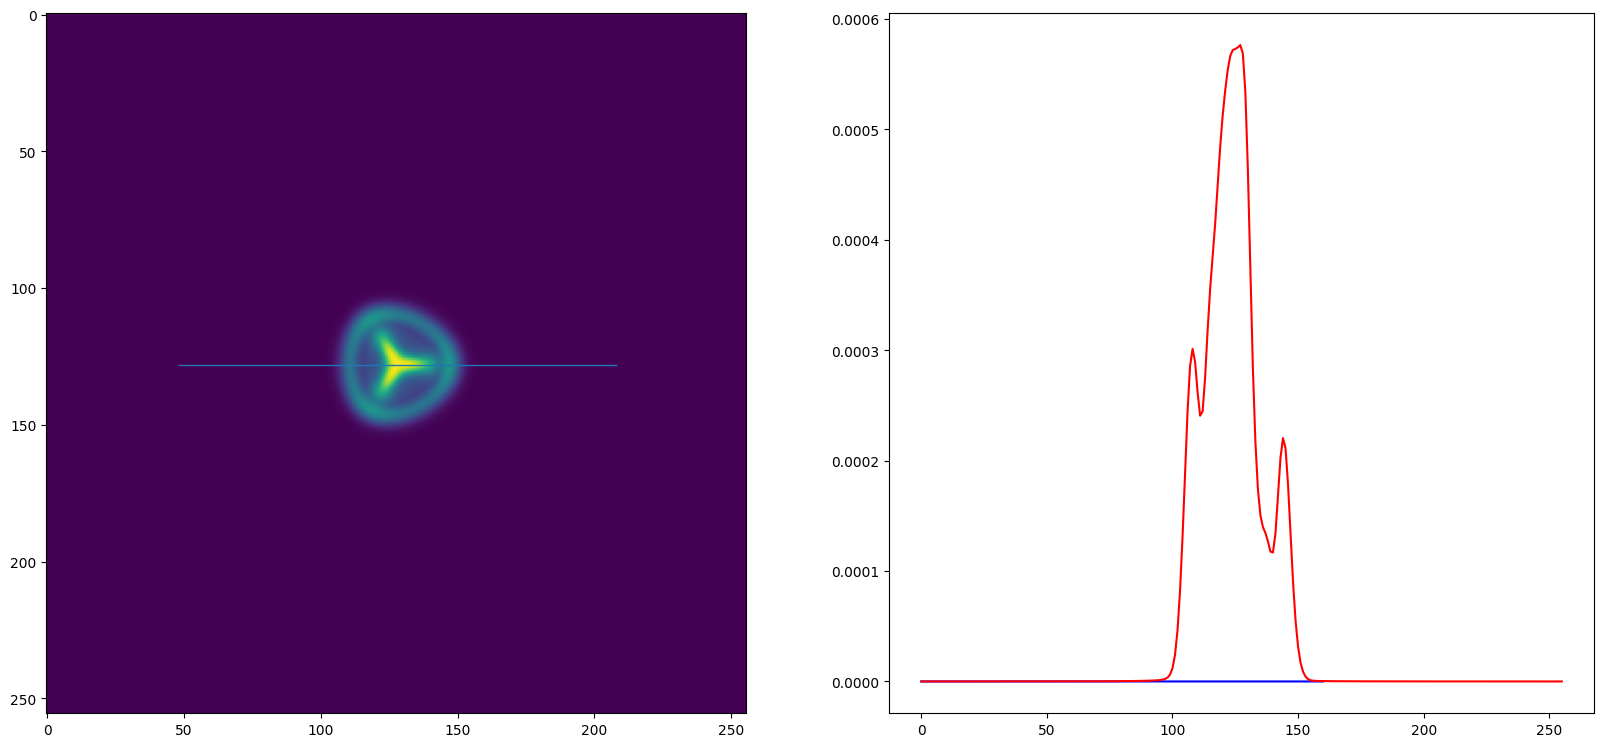

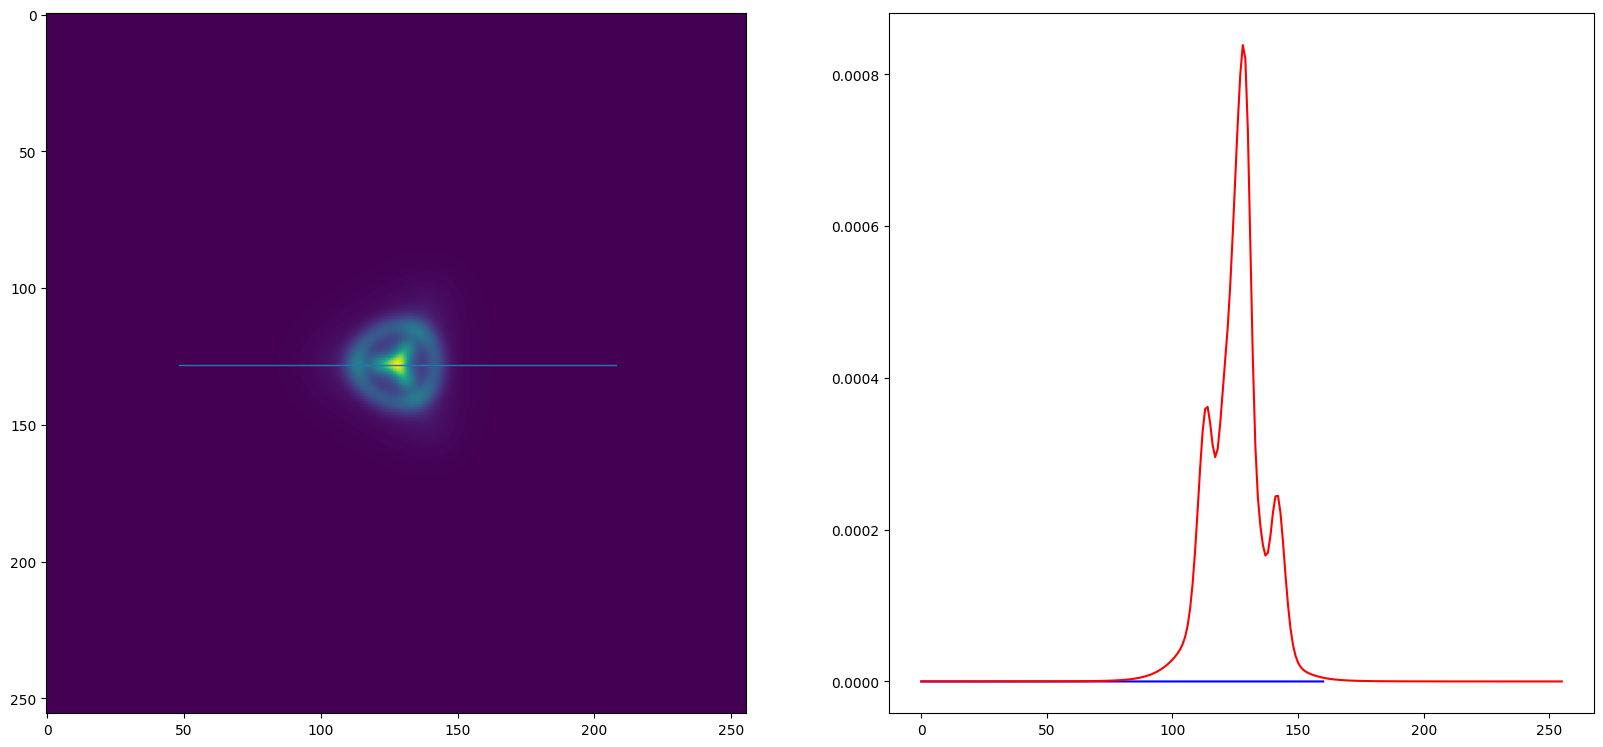

Shape of W_UF: (1440, 36)
Shape of T_UF: (1440, 36)
Shape of W_OF: (1440, 36)
Shape of T_OF: (1440, 36)
Shape of j_list_broadcast: (161, 1, 1)
Shape of Xigma_UF: (1440, 36)
Shape of Mu_UF: (1440, 36)
Shape of Xigma_OF: (1440, 36)
Shape of Mu_OF: (1440, 36)
Shape of pj_UF_nonzero: (160, 1440, 36)
Shape of p0_UF: (1440, 36)
Shape of pj_OF_nonzero: (160, 1440, 36)
Shape of j_list_nonzero: (160,)
Shape of j_list_nonzero[:, None, None]: (160, 1, 1)
Shape of p0_UF[:, None, :]: (1440, 1, 36)
Shape of Rou_UF: (1440, 36)
Shape of Rou_OF: (1440, 36)
Processing batch 2/90


OutOfMemoryError: Out of memory allocating 3,019,898,880 bytes (allocated so far: 15,099,696,640 bytes).

In [ ]:
import aberration_computation as ac
import cupy as cp
import gc
import numpy as np
import h5py  # Using HDF5 for efficient storage

# Define input sequences of aberration coefficients
C1_offset_sequence = cp.array([-909, 909])
A3_amp_sequence = cp.array([0, 10, 20, 30])
A2_amp_sequence = cp.array([2,4, 8, 16,17,18])
C1_sequence = cp.linspace(-50, 50, 11)
C3_sequence = cp.array([ 1.2, 1.5,1.8,2,2.1,2.2])
A1_amp_sequence = cp.array([0, 10, 20])
A1_phase_sequence = cp.linspace(0, 180, 3)
A2_phase_sequence = cp.linspace(0, 120, 3)
A3_phase_sequence = cp.linspace(0, 90, 3)

# Define other parameters
pix_dim = [256, 256]
real_dim = [1280, 1280]
eV = 0.8e3
app = 30  # example aperture size in mrad
optic_axis = [0, 0]  # Example optic axis
aperture_shift = [0, 0]  # Example aperture shift
tilt_units = "mrad"  # Example tilt units
df = 0  # Example defocus
app_units = "mrad"  # Example aperture units

# Calculate the total number of combinations
total_combinations = (len(C1_offset_sequence) *
                      len(A3_amp_sequence) *
                      len(A2_amp_sequence) *
                      len(C1_sequence) *
                      len(C3_sequence) *
                      len(A1_amp_sequence) *
                      len(A1_phase_sequence) *
                      len(A2_phase_sequence) *
                      len(A3_phase_sequence))

print(f"Total combinations: {total_combinations}")

# Define the batch size
batch_size = 2880

# Calculate the number of batches
num_batches = (total_combinations + batch_size - 1) // batch_size

print(f"Number of batches: {num_batches}")

# Save the results to an HDF5 file
with h5py.File('results.h5', 'w') as f:
    # Save aberration coefficients once
    f.create_dataset('C1_offset_sequence', data=C1_offset_sequence.get())
    f.create_dataset('A3_amp_sequence', data=A3_amp_sequence.get())
    f.create_dataset('A2_amp_sequence', data=A2_amp_sequence.get())
    f.create_dataset('C1_sequence', data=C1_sequence.get())
    f.create_dataset('C3_sequence', data=C3_sequence.get())
    f.create_dataset('A1_amp_sequence', data=A1_amp_sequence.get())
    f.create_dataset('A1_phase_sequence', data=A1_phase_sequence.get())
    f.create_dataset('A2_phase_sequence', data=A2_phase_sequence.get())
    f.create_dataset('A3_phase_sequence', data=A3_phase_sequence.get())

    last_Probe_image_Final = None

    # Process each batch
    for batch_index in range(num_batches):
        print(f"Processing batch {batch_index + 1}/{num_batches}")

        # Compute the CTF tensor for the current batch
        CTF_tensor_batch = ac.make_contrast_transfer_function(
            pix_dim=pix_dim,
            real_dim=real_dim,
            eV=eV,
            app=app,
            optic_axis=optic_axis,
            aperture_shift=aperture_shift,
            tilt_units=tilt_units,
            df=df,
            C1_offset_sequence=C1_offset_sequence,
            A3_amp_sequence=A3_amp_sequence,
            A2_amp_sequence=A2_amp_sequence,
            C1_sequence=C1_sequence,
            C3_sequence=C3_sequence,
            A1_amp_sequence=A1_amp_sequence,
            A1_phase_sequence=A1_phase_sequence,
            A2_phase_sequence=A2_phase_sequence,
            A3_phase_sequence=A3_phase_sequence,
            batch_index=batch_index,
            batch_size=batch_size
        )

        # Compute the probe image for the current batch
        Probe_image_Final_batch = ac.compute_probe_image(CTF_tensor_batch, Sigma=2)

        # Extract and save features for the current batch
        Xigma_UF, Xigma_OF, Mu_UF, Mu_OF, Rou_UF, Rou_OF = ac.extract_features_vectorized(Probe_image_Final_batch)

        # Save the extracted features to the HDF5 file
        group = f.create_group(f'features_batch_{batch_index}')
        group.create_dataset('Xigma_UF', data=Xigma_UF.get())
        group.create_dataset('Xigma_OF', data=Xigma_OF.get())
        group.create_dataset('Mu_UF', data=Mu_UF.get())
        group.create_dataset('Mu_OF', data=Mu_OF.get())
        group.create_dataset('Rou_UF', data=Rou_UF.get())
        group.create_dataset('Rou_OF', data=Rou_OF.get())

        # Save the last Probe_image_Final
        if batch_index == num_batches - 1:
            last_Probe_image_Final = Probe_image_Final_batch

        # Free GPU memory
        del CTF_tensor_batch, Probe_image_Final_batch
        cp.get_default_memory_pool().free_all_blocks()
        gc.collect()

    # Save the last Probe_image_Final separately
    if last_Probe_image_Final is not None:
        with open('last_Probe_image_Final.npy', 'wb') as f_probe:
            np.save(f_probe, last_Probe_image_Final.get())

print("All batches processed and saved.")


Testing the line_profile extraction using gradient images

(36, 255, 1)
(36, 255, 1)
[[[  1.        ]
  [  2.        ]
  [  3.        ]
  ...
  [253.        ]
  [254.        ]
  [255.        ]]

 [[  1.48327334]
  [  2.47946804]
  [  3.47566274]
  ...
  [252.52433726]
  [253.52053196]
  [254.51672666]]

 [[  2.92941537]
  [  3.91422312]
  [  4.89903087]
  ...
  [251.10096913]
  [252.08577688]
  [253.07058463]]

 ...

 [[250.67257994]
  [249.70665411]
  [248.74072829]
  ...
  [  7.25927171]
  [  6.29334589]
  [  5.32742006]]

 [[253.07058463]
  [252.08577688]
  [251.10096913]
  ...
  [  4.89903087]
  [  3.91422312]
  [  2.92941537]]

 [[254.51672666]
  [253.52053196]
  [252.52433726]
  ...
  [  3.47566274]
  [  2.47946804]
  [  1.48327334]]]
[[[128.        ]
  [128.        ]
  [128.        ]
  ...
  [128.        ]
  [128.        ]
  [128.        ]]

 [[116.93122067]
  [117.01837641]
  [117.10553216]
  ...
  [138.89446784]
  [138.98162359]
  [139.06877933]]

 [[105.94668144]
  [106.12032961]
  [106.29397779]
  ...
  [149.70602221]
  [149.8796703

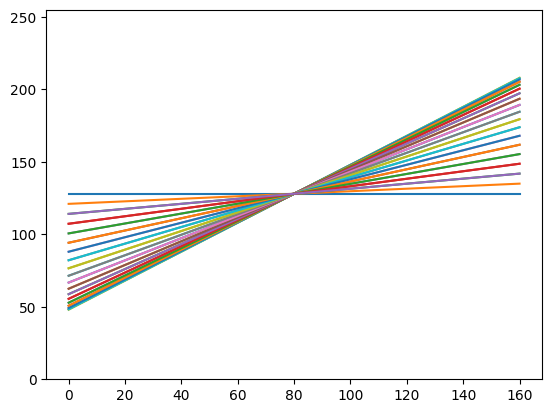

255.0
0.0


In [ ]:
import cupy as cp
from cupyx.scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt

def extract_line_profiles(image_stack, x_coords, y_coords):
    num_lines_per_image, num_pixels_per_line, num_images = x_coords.shape
    x_coords_flat = x_coords.reshape(num_lines_per_image * num_pixels_per_line, num_images)
    y_coords_flat = y_coords.reshape(num_lines_per_image * num_pixels_per_line, num_images)

    coordinates = cp.stack((y_coords_flat, x_coords_flat), axis=0)
    coordinates_flat = coordinates.reshape(2, -1)

    flattened_image_stack = image_stack.reshape(256, -1)

    line_profiles_flat = map_coordinates(flattened_image_stack, coordinates_flat, order=1, mode='nearest')
    line_profiles = line_profiles_flat.reshape(num_lines_per_image, num_pixels_per_line, num_images).transpose(1, 2, 0)

    return line_profiles

def extract_features_vectorized(Probe_image_Final, num_lines=37, pixel_size=1, r=80):
    angles = cp.linspace(0, 180, num_lines)
    j_list = pixel_size * (cp.arange(2 * r + 1) - r)
    j_list_nonzero = cp.concatenate((j_list[:r], j_list[-r:]))

    batch_shape = Probe_image_Final.shape[2:]
    num_images = cp.prod(cp.array(batch_shape)).item()
    length_of_line = 2 * r + 1
    num_lines_per_image = num_lines - 1

    Probe_image_Final_UF = Probe_image_Final[:, :, 0::2]
    Probe_image_Final_OF = Probe_image_Final[:, :, 1::2]

    x_center_UF, y_center_UF = 128, 128
    x_center_OF, y_center_OF = 128, 128

    theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)

    x1_UF = -r * cp.cos(theta_rad) + x_center_UF
    y1_UF = -r * cp.sin(theta_rad) + y_center_UF
    x2_UF = r * cp.cos(theta_rad) + x_center_UF
    y2_UF = r * cp.sin(theta_rad) + y_center_UF

    x1_OF = -r * cp.cos(theta_rad) + x_center_OF
    y1_OF = -r * cp.sin(theta_rad) + y_center_OF
    x2_OF = r * cp.cos(theta_rad) + x_center_OF
    y2_OF = r * cp.sin(theta_rad) + y_center_OF

    y_coords_UF = cp.linspace(y1_UF, y2_UF, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
    x_coords_UF = cp.linspace(x1_UF, x2_UF, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

    y_coords_OF = cp.linspace(y1_OF, y2_OF, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
    x_coords_OF = cp.linspace(x1_OF, x2_OF, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

    x_coords_UF = cp.tile(x_coords_UF, (1, 1, num_images // 2))
    y_coords_UF = cp.tile(y_coords_UF, (1, 1, num_images // 2))
    x_coords_OF = cp.tile(x_coords_OF, (1, 1, num_images // 2))
    y_coords_OF = cp.tile(y_coords_OF, (1, 1, num_images // 2))

    pj_UF = extract_line_profiles(Probe_image_Final_UF, x_coords_UF, y_coords_UF)
    pj_OF = extract_line_profiles(Probe_image_Final_OF, x_coords_OF, y_coords_OF)

    return pj_UF, pj_OF

# Create a gradient image stack for testing
image_stack = cp.zeros((256, 256, 1440))
for i in range(1440):
    image_stack[:, :, i] = cp.linspace(0, 255, 256)[:, None]

angles = cp.linspace(0, 180, 37)
r = 127
x_center, y_center = 128, 128

theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)
x1 = -r * cp.cos(theta_rad) + x_center
y1 = -r * cp.sin(theta_rad) + y_center
x2 = r * cp.cos(theta_rad) + x_center
y2 = r * cp.sin(theta_rad) + y_center

x_coords_UF = cp.linspace(x1, x2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
y_coords_UF = cp.linspace(y1, y2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

print(x_coords_UF.shape)
print(y_coords_UF.shape)

print(x_coords_UF)

print(y_coords_UF)

pj_UF, pj_OF = extract_features_vectorized(image_stack, num_lines=37, pixel_size=1, r=80)
print(pj_UF.shape)
print(pj_OF.shape)
for i in range(35):
   plt.plot(pj_UF[:, 700, i].get())
   plt.ylim(0, 255)
plt.show()
print(image_stack.max())
print(image_stack.min())

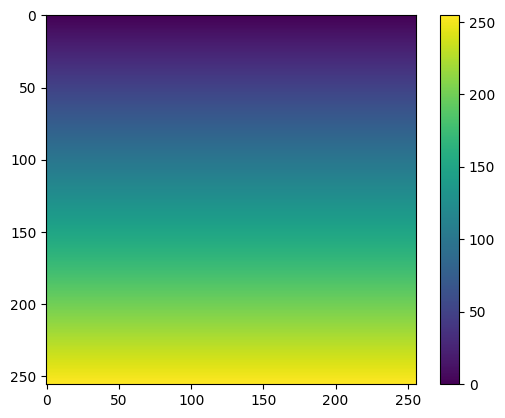

In [ ]:
plt.imshow(image_stack[:,:,0].get())
plt.colorbar()
plt.show()

Min of the first image 0.0
Max of the first image 255.0
1.0 255.0
1.0 255.0
(36, 255, 1)
(36, 255, 1)


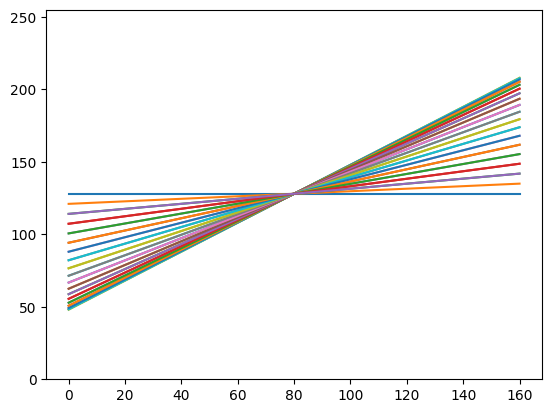

In [ ]:
import cupy as cp
from cupyx.scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt

def extract_line_profiles(image_stack, x_coords, y_coords):
    num_lines_per_image, num_pixels_per_line, num_images = x_coords.shape
    x_coords_flat = x_coords.reshape(num_lines_per_image * num_pixels_per_line, num_images)
    y_coords_flat = y_coords.reshape(num_lines_per_image * num_pixels_per_line, num_images)

    coordinates = cp.stack((y_coords_flat, x_coords_flat), axis=0)
    coordinates_flat = coordinates.reshape(2, -1)

    flattened_image_stack = image_stack.reshape(256, -1)

    line_profiles_flat = map_coordinates(flattened_image_stack, coordinates_flat, order=1, mode='nearest')
    line_profiles = line_profiles_flat.reshape(num_lines_per_image, num_pixels_per_line, num_images).transpose(1, 2, 0)

    return line_profiles

def extract_features_vectorized(Probe_image_Final, num_lines=37, pixel_size=1, r=80):
    angles = cp.linspace(0, 180, num_lines)
    j_list = pixel_size * (cp.arange(2 * r + 1) - r)
    j_list_nonzero = cp.concatenate((j_list[:r], j_list[-r:]))

    batch_shape = Probe_image_Final.shape[2:]
    num_images = cp.prod(cp.array(batch_shape)).item()
    length_of_line = 2 * r + 1
    num_lines_per_image = num_lines - 1

    Probe_image_Final_UF = Probe_image_Final[:, :, 0::2]
    Probe_image_Final_OF = Probe_image_Final[:, :, 1::2]

    x_center_UF, y_center_UF = 128, 128
    x_center_OF, y_center_OF = 128, 128

    theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)

    x1_UF = -r * cp.cos(theta_rad) + x_center_UF
    y1_UF = -r * cp.sin(theta_rad) + y_center_UF
    x2_UF = r * cp.cos(theta_rad) + x_center_UF
    y2_UF = r * cp.sin(theta_rad) + y_center_UF

    x1_OF = -r * cp.cos(theta_rad) + x_center_OF
    y1_OF = -r * cp.sin(theta_rad) + y_center_OF
    x2_OF = r * cp.cos(theta_rad) + x_center_OF
    y2_OF = r * cp.sin(theta_rad) + y_center_OF

    y_coords_UF = cp.linspace(y1_UF, y2_UF, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
    x_coords_UF = cp.linspace(x1_UF, x2_UF, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

    y_coords_OF = cp.linspace(y1_OF, y2_OF, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
    x_coords_OF = cp.linspace(x1_OF, x2_OF, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

    x_coords_UF = cp.tile(x_coords_UF, (1, 1, num_images // 2))
    y_coords_UF = cp.tile(y_coords_UF, (1, 1, num_images // 2))
    x_coords_OF = cp.tile(x_coords_OF, (1, 1, num_images // 2))
    y_coords_OF = cp.tile(y_coords_OF, (1, 1, num_images // 2))

    pj_UF = extract_line_profiles(Probe_image_Final_UF, x_coords_UF, y_coords_UF)
    pj_OF = extract_line_profiles(Probe_image_Final_OF, x_coords_OF, y_coords_OF)

    return pj_UF, pj_OF

# Create a gradient image stack for testing
image_stack = cp.zeros((256, 256, 1440))
for i in range(1440):
    image_stack[:, :, i] = cp.linspace(0, 255, 256)[:, None]

print("Min of the first image",image_stack[:,:,0].min())
print("Max of the first image",image_stack[:,:,0].max())

angles = cp.linspace(0, 180, 37)
r = 127
x_center, y_center = 128, 128

theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)
x1 = -r * cp.cos(theta_rad) + x_center
y1 = -r * cp.sin(theta_rad) + y_center
x2 = r * cp.cos(theta_rad) + x_center
y2 = r * cp.sin(theta_rad) + y_center

x_coords_UF = cp.linspace(x1, x2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
y_coords_UF = cp.linspace(y1, y2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

print(y_coords_UF.min(),y_coords_UF.max())
print(x_coords_UF.min(),x_coords_UF.max())

print(x_coords_UF.shape)
print(y_coords_UF.shape)

pj_UF, pj_OF = extract_features_vectorized(image_stack, num_lines=37, pixel_size=1, r=80)

for i in range(35):
   plt.plot(pj_UF[:, 0, i].get())
   plt.ylim(0, 255)
plt.show()


Min of the first image 0.0
Max of the first image 255.0
1.0 255.0
1.0 255.0
(36, 255, 1)
(36, 255, 1)


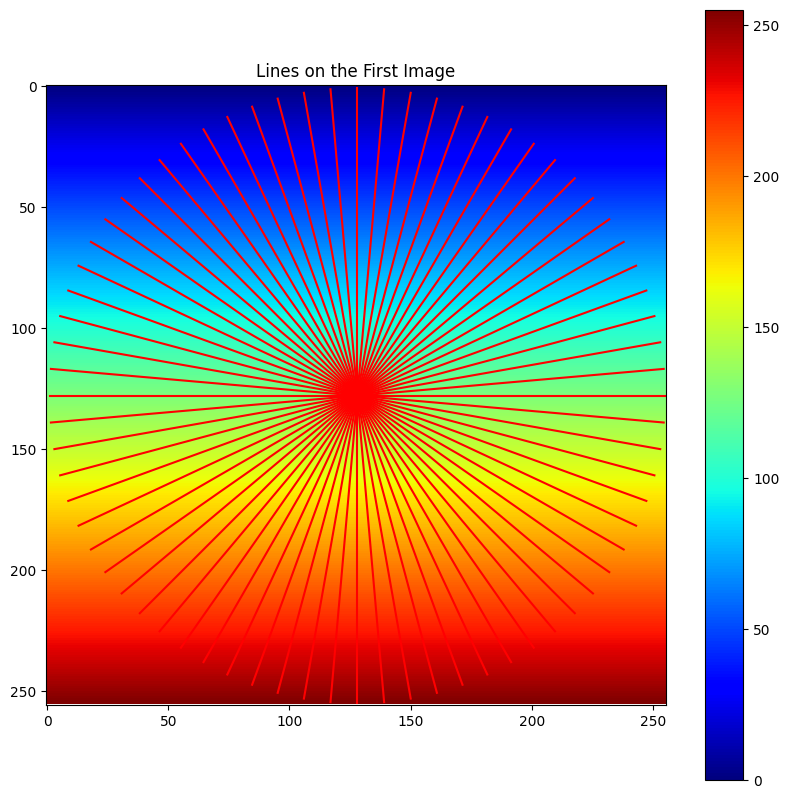

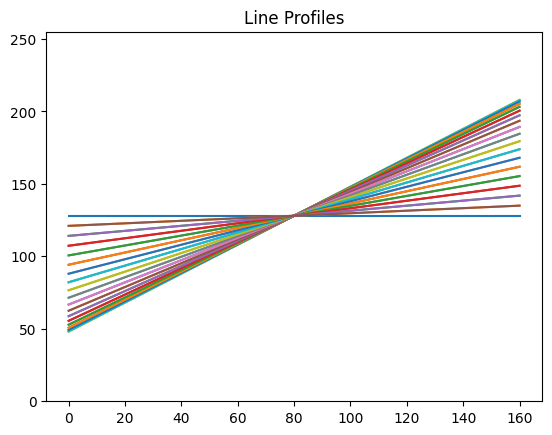

In [ ]:
import cupy as cp
from cupyx.scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt

def extract_line_profiles(image_stack, x_coords, y_coords):
    num_lines_per_image, num_pixels_per_line, num_images = x_coords.shape
    x_coords_flat = x_coords.reshape(num_lines_per_image * num_pixels_per_line, num_images)
    y_coords_flat = y_coords.reshape(num_lines_per_image * num_pixels_per_line, num_images)

    coordinates = cp.stack((y_coords_flat, x_coords_flat), axis=0)
    coordinates_flat = coordinates.reshape(2, -1)

    flattened_image_stack = image_stack.reshape(256, -1)

    line_profiles_flat = map_coordinates(flattened_image_stack, coordinates_flat, order=1, mode='nearest')
    line_profiles = line_profiles_flat.reshape(num_lines_per_image, num_pixels_per_line, num_images).transpose(1, 2, 0)

    return line_profiles

def extract_features_vectorized(Probe_image_Final, num_lines=37, pixel_size=1, r=80):
    angles = cp.linspace(0, 180, num_lines)
    j_list = pixel_size * (cp.arange(2 * r + 1) - r)
    j_list_nonzero = cp.concatenate((j_list[:r], j_list[-r:]))

    batch_shape = Probe_image_Final.shape[2:]
    num_images = cp.prod(cp.array(batch_shape)).item()
    length_of_line = 2 * r + 1
    num_lines_per_image = num_lines - 1

    Probe_image_Final_UF = Probe_image_Final[:, :, 0::2]
    Probe_image_Final_OF = Probe_image_Final[:, :, 1::2]

    x_center_UF, y_center_UF = 128, 128
    x_center_OF, y_center_OF = 128, 128

    theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)

    x1_UF = -r * cp.cos(theta_rad) + x_center_UF
    y1_UF = -r * cp.sin(theta_rad) + y_center_UF
    x2_UF = r * cp.cos(theta_rad) + x_center_UF
    y2_UF = r * cp.sin(theta_rad) + y_center_UF

    x1_OF = -r * cp.cos(theta_rad) + x_center_OF
    y1_OF = -r * cp.sin(theta_rad) + y_center_OF
    x2_OF = r * cp.cos(theta_rad) + x_center_OF
    y2_OF = r * cp.sin(theta_rad) + y_center_OF

    y_coords_UF = cp.linspace(y1_UF, y2_UF, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
    x_coords_UF = cp.linspace(x1_UF, x2_UF, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

    y_coords_OF = cp.linspace(y1_OF, y2_OF, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
    x_coords_OF = cp.linspace(x1_OF, x2_OF, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

    x_coords_UF = cp.tile(x_coords_UF, (1, 1, num_images // 2))
    y_coords_UF = cp.tile(y_coords_UF, (1, 1, num_images // 2))
    x_coords_OF = cp.tile(x_coords_OF, (1, 1, num_images // 2))
    y_coords_OF = cp.tile(y_coords_OF, (1, 1, num_images // 2))

    pj_UF = extract_line_profiles(Probe_image_Final_UF, x_coords_UF, y_coords_UF)
    pj_OF = extract_line_profiles(Probe_image_Final_OF, x_coords_OF, y_coords_OF)

    return pj_UF, pj_OF

# Create a gradient image stack for testing
image_stack = cp.zeros((256, 256, 1440))
for i in range(1440):
    image_stack[:, :, i] = cp.linspace(0, 255, 256)[:, None]

print("Min of the first image",image_stack[:,:,0].min())
print("Max of the first image",image_stack[:,:,0].max())

angles = cp.linspace(0, 180, 37)
r = 127
x_center, y_center = 128, 128

theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)
x1 = -r * cp.cos(theta_rad) + x_center
y1 = -r * cp.sin(theta_rad) + y_center
x2 = r * cp.cos(theta_rad) + x_center
y2 = r * cp.sin(theta_rad) + y_center

x_coords_UF = cp.linspace(x1, x2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
y_coords_UF = cp.linspace(y1, y2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

print(y_coords_UF.min(), y_coords_UF.max())
print(x_coords_UF.min(), x_coords_UF.max())

print(x_coords_UF.shape)
print(y_coords_UF.shape)

pj_UF, pj_OF = extract_features_vectorized(image_stack, num_lines=37, pixel_size=1, r=80)

# Plot the first image with lines overlay
plt.figure(figsize=(10, 10))
plt.imshow(image_stack[:, :, 0].get(), cmap='jet')
plt.colorbar()
for i in range(x_coords_UF.shape[0]):
    plt.plot([x1[i, 0].get(), x2[i, 0].get()], [y1[i, 0].get(), y2[i, 0].get()], 'r-')
plt.title('Lines on the First Image')
plt.show()

# Plot the line profiles
for i in range(x_coords_UF.shape[0]):
    plt.plot(pj_UF[:, 0, i].get())
    plt.ylim(0, 255)
plt.title('Line Profiles')
plt.show()


Min of the first image 0.0
Max of the first image 255.0
1.0 255.0
1.0 255.0
(36, 255, 1)
(36, 255, 1)


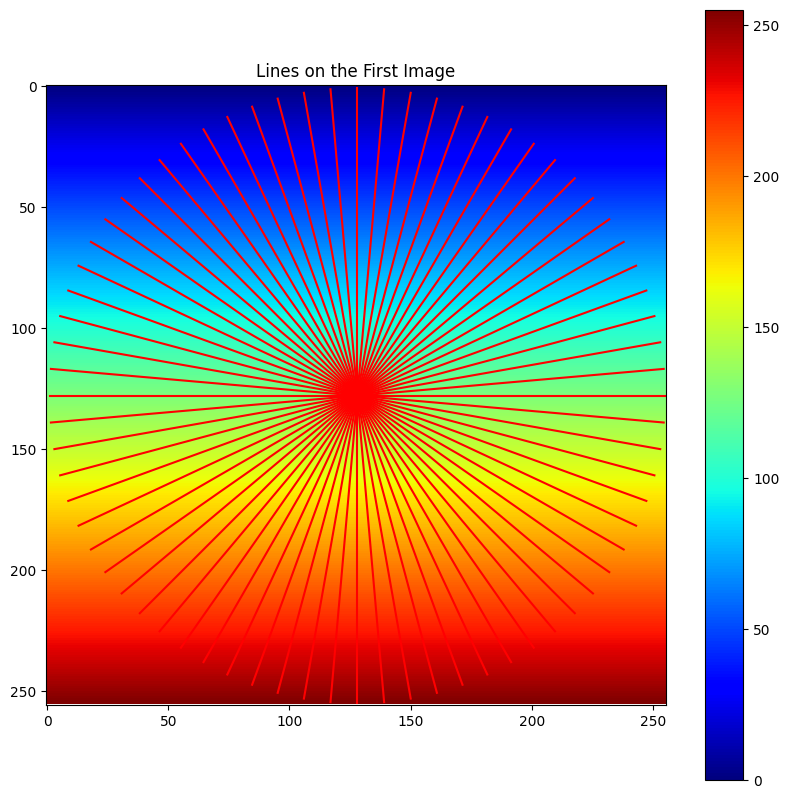

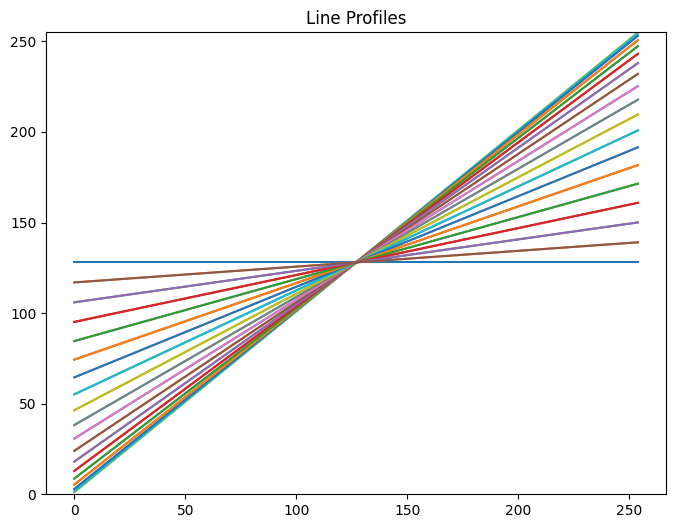

In [ ]:
import cupy as cp
from cupyx.scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt

def extract_line_profiles(image_stack, x_coords, y_coords):
    num_lines_per_image, num_pixels_per_line, num_images = x_coords.shape
    x_coords_flat = x_coords.reshape(num_lines_per_image * num_pixels_per_line, num_images)
    y_coords_flat = y_coords.reshape(num_lines_per_image * num_pixels_per_line, num_images)

    coordinates = cp.stack((y_coords_flat, x_coords_flat), axis=0)
    coordinates_flat = coordinates.reshape(2, -1)

    flattened_image_stack = image_stack.reshape(256, -1)

    line_profiles_flat = map_coordinates(flattened_image_stack, coordinates_flat, order=1, mode='nearest')
    line_profiles = line_profiles_flat.reshape(num_lines_per_image, num_pixels_per_line, num_images).transpose(1, 2, 0)

    return line_profiles

def extract_features_vectorized(Probe_image_Final, num_lines=37, pixel_size=1, r=80):
    angles = cp.linspace(0, 180, num_lines)
    j_list = pixel_size * (cp.arange(2 * r + 1) - r)
    j_list_nonzero = cp.concatenate((j_list[:r], j_list[-r:]))

    batch_shape = Probe_image_Final.shape[2:]
    num_images = cp.prod(cp.array(batch_shape)).item()
    length_of_line = 2 * r + 1
    num_lines_per_image = num_lines - 1

    Probe_image_Final_UF = Probe_image_Final[:, :, 0::2]
    Probe_image_Final_OF = Probe_image_Final[:, :, 1::2]

    x_center_UF, y_center_UF = 128, 128
    x_center_OF, y_center_OF = 128, 128

    theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)

    x1_UF = -r * cp.cos(theta_rad) + x_center_UF
    y1_UF = -r * cp.sin(theta_rad) + y_center_UF
    x2_UF = r * cp.cos(theta_rad) + x_center_UF
    y2_UF = r * cp.sin(theta_rad) + y_center_UF

    x1_OF = -r * cp.cos(theta_rad) + x_center_OF
    y1_OF = -r * cp.sin(theta_rad) + y_center_OF
    x2_OF = r * cp.cos(theta_rad) + x_center_OF
    y2_OF = r * cp.sin(theta_rad) + y_center_OF

    y_coords_UF = cp.linspace(y1_UF, y2_UF, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
    x_coords_UF = cp.linspace(x1_UF, x2_UF, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

    y_coords_OF = cp.linspace(y1_OF, y2_OF, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
    x_coords_OF = cp.linspace(x1_OF, x2_OF, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

    x_coords_UF = cp.tile(x_coords_UF, (1, 1, num_images // 2))
    y_coords_UF = cp.tile(y_coords_UF, (1, 1, num_images // 2))
    x_coords_OF = cp.tile(x_coords_OF, (1, 1, num_images // 2))
    y_coords_OF = cp.tile(y_coords_OF, (1, 1, num_images // 2))

    pj_UF = extract_line_profiles(Probe_image_Final_UF, x_coords_UF, y_coords_UF)
    pj_OF = extract_line_profiles(Probe_image_Final_OF, x_coords_OF, y_coords_OF)

    return pj_UF, pj_OF

# Create a gradient image stack for testing
image_stack = cp.zeros((256, 256, 1440))
for i in range(1440):
    image_stack[:, :, i] = cp.linspace(0, 255, 256)[:, None]

print("Min of the first image", image_stack[:, :, 0].min())
print("Max of the first image", image_stack[:, :, 0].max())

angles = cp.linspace(0, 180, 37)
r = 127
x_center, y_center = 128, 128

theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)
x1 = -r * cp.cos(theta_rad) + x_center
y1 = -r * cp.sin(theta_rad) + y_center
x2 = r * cp.cos(theta_rad) + x_center
y2 = r * cp.sin(theta_rad) + y_center

x_coords_UF = cp.linspace(x1, x2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
y_coords_UF = cp.linspace(y1, y2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

print(y_coords_UF.min(), y_coords_UF.max())
print(x_coords_UF.min(), x_coords_UF.max())

print(x_coords_UF.shape)
print(y_coords_UF.shape)

pj_UF, pj_OF = extract_features_vectorized(image_stack, num_lines=37, pixel_size=1, r=127)

# Plot the first image with lines overlay
plt.figure(figsize=(10, 10))
plt.imshow(image_stack[:, :, 0].get(), cmap='jet')
plt.colorbar()
for i in range(x_coords_UF.shape[0]):
    plt.plot([x1[i, 0].get(), x2[i, 0].get()], [y1[i, 0].get(), y2[i, 0].get()], 'r-')
plt.title('Lines on the First Image')
plt.show()

# Plot the line profiles
plt.figure(figsize=(8, 6))
for i in range(x_coords_UF.shape[0]):
    plt.plot(pj_UF[:, 0, i].get())
plt.ylim(0, 255)
plt.title('Line Profiles')
plt.show()


# This works

Min of the first image 0.0
Max of the first image 255.0
48.0 208.0
48.0 208.0
(36, 161, 1)
(36, 161, 1)


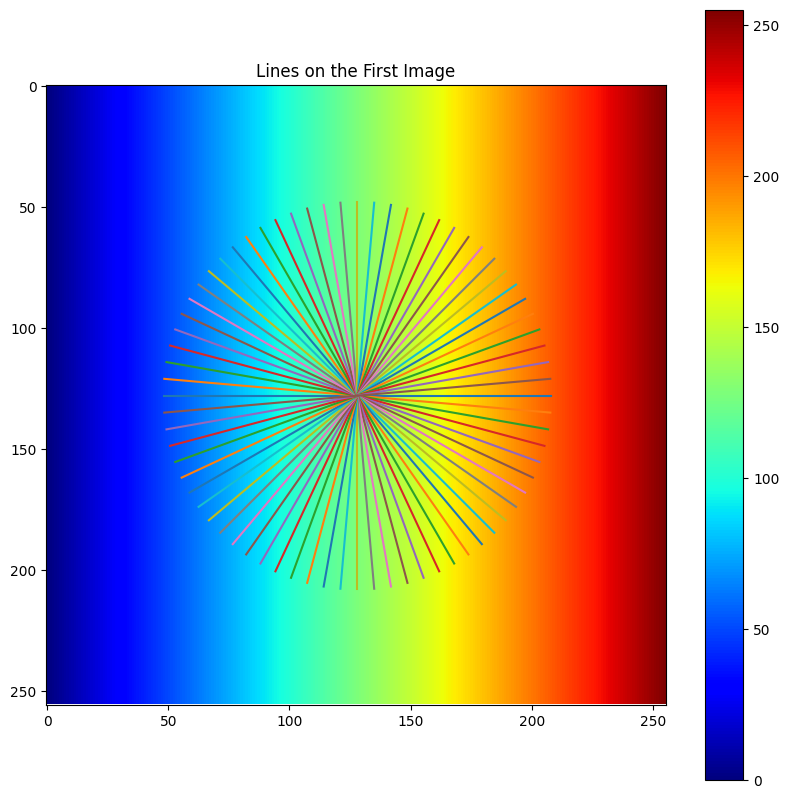

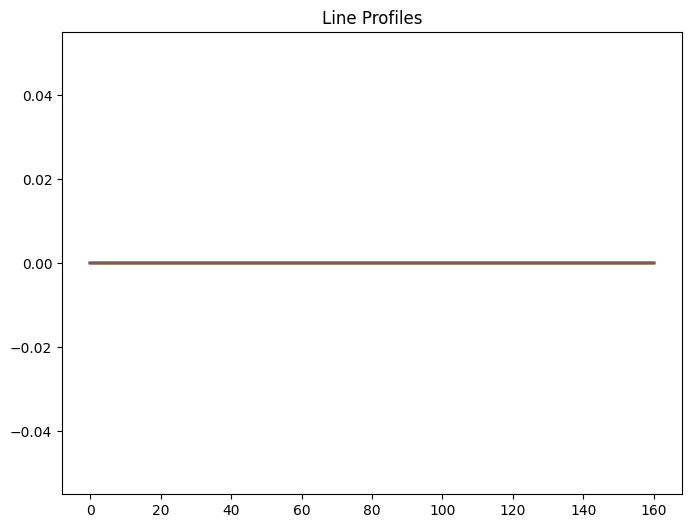

(161, 1440, 36)


In [ ]:
import cupy as cp
from cupyx.scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt

def extract_line_profiles(image_stack, x_coords, y_coords):
    num_lines_per_image, num_pixels_per_line, num_images = x_coords.shape
    x_coords_flat = x_coords.reshape(num_lines_per_image * num_pixels_per_line, num_images)
    y_coords_flat = y_coords.reshape(num_lines_per_image * num_pixels_per_line, num_images)

    coordinates = cp.stack((y_coords_flat, x_coords_flat), axis=0)
    coordinates_flat = coordinates.reshape(2, -1)

    flattened_image_stack = image_stack.reshape(256, -1)

    line_profiles_flat = map_coordinates(flattened_image_stack, coordinates_flat, order=1, mode='nearest')
    line_profiles = line_profiles_flat.reshape(num_lines_per_image, num_pixels_per_line, num_images).transpose(1, 2, 0)

    return line_profiles

def extract_features_vectorized(Probe_image_Final, num_lines=37, pixel_size=1, r=127):
    angles = cp.linspace(0, 180, num_lines)
    j_list = pixel_size * (cp.arange(2 * r + 1) - r)
    j_list_nonzero = cp.concatenate((j_list[:r], j_list[-r:]))

    batch_shape = Probe_image_Final.shape[2:]
    num_images = cp.prod(cp.array(batch_shape)).item()
    length_of_line = 2 * r + 1
    num_lines_per_image = num_lines - 1

    x_center, y_center = 128, 128

    theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)

    x1 = -r * cp.cos(theta_rad) + x_center
    y1 = -r * cp.sin(theta_rad) + y_center
    x2 = r * cp.cos(theta_rad) + x_center
    y2 = r * cp.sin(theta_rad) + y_center

    y_coords = cp.linspace(y1, y2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
    x_coords = cp.linspace(x1, x2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

    x_coords = cp.tile(x_coords, (1, 1, num_images))
    y_coords = cp.tile(y_coords, (1, 1, num_images))

    pj = extract_line_profiles(Probe_image_Final, x_coords, y_coords)

    return pj

# Create a gradient image stack for testing
image_stack = cp.zeros((256, 256, 1440))
for i in range(1440):
    image_stack[:, :, i] = cp.linspace(0, 255, 256)[None,:]

print("Min of the first image", image_stack[:, :, 0].min())
print("Max of the first image", image_stack[:, :, 0].max())

angles = cp.linspace(0, 180, 37)
r = 80
x_center, y_center = 128, 128

theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)
x1 = -r * cp.cos(theta_rad) + x_center
y1 = -r * cp.sin(theta_rad) + y_center
x2 = r * cp.cos(theta_rad) + x_center
y2 = r * cp.sin(theta_rad) + y_center

x_coords = cp.linspace(x1, x2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
y_coords = cp.linspace(y1, y2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

print(y_coords.min(), y_coords.max())
print(x_coords.min(), x_coords.max())

print(x_coords.shape)
print(y_coords.shape)

pj = extract_features_vectorized(image_stack, num_lines=37, pixel_size=1, r=r)

# Plot the first image with lines overlay
plt.figure(figsize=(10, 10))
plt.imshow(image_stack[:, :, 0].get(), cmap='jet')
plt.colorbar()
for i in range(x_coords.shape[0]):
    plt.plot([x1[i, 0].get(), x2[i, 0].get()], [y1[i, 0].get(), y2[i, 0].get()])
plt.title('Lines on the First Image')
plt.show()

# Plot the line profiles
plt.figure(figsize=(8, 6))
for i in range(x_coords.shape[0]):
    plt.plot(pj[:, 0, i].get())
# plt.ylim(0, 255)
plt.title('Line Profiles')
plt.show()

print(pj.shape)

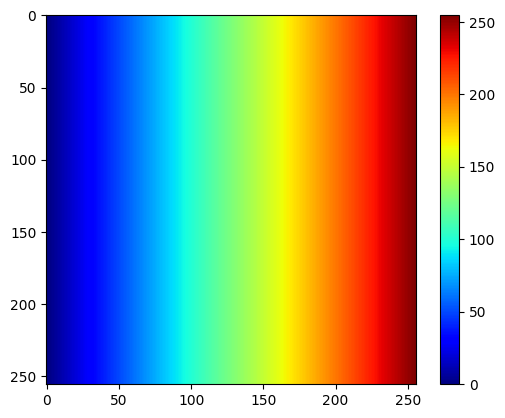

In [ ]:
plt.imshow(image_stack[:,:,0].get(),cmap='jet')
plt.colorbar()
plt.show()

Another trial for vetical gradient images

Min of the first image 0.0
Max of the first image 255.0
y_coords.min,y_coords.max
48.0 208.0
x_coords.min, x_coords.max
48.0 208.0
x_coords.shape (36, 161, 1)
y_coords.shape (36, 161, 1)
# of images 1440
x_coords.shape (36, 161, 1440)
y_coords.shape (36, 161, 1440)
x_coords_flat.shape (5796, 1440)
(5796, 1440)
coordinates_flat.shape (2, 8346240)
208.0
flattened_image_stack.shape (256, 368640)


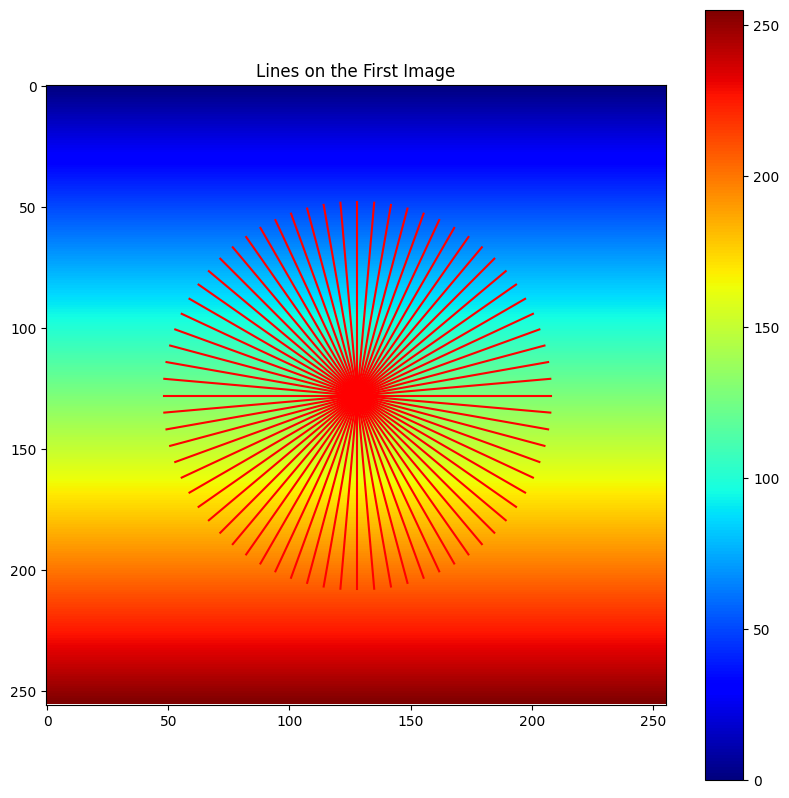

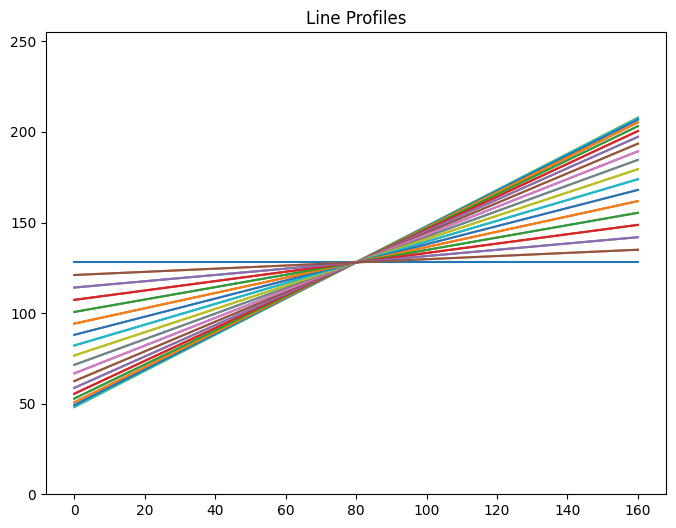

(161, 1440, 36)


In [5]:
import cupy as cp
from cupyx.scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt

def extract_line_profiles(image_stack, x_coords, y_coords):
    num_lines_per_image, num_pixels_per_line, num_images = x_coords.shape
    x_coords_flat = x_coords.reshape(num_lines_per_image * num_pixels_per_line, num_images)
    y_coords_flat = y_coords.reshape(num_lines_per_image * num_pixels_per_line, num_images)
    print('x_coords_flat.shape',x_coords_flat.shape)
    print(y_coords_flat.shape)
    coordinates = cp.stack((y_coords_flat, x_coords_flat), axis=0)
    coordinates_flat = coordinates.reshape(2, -1)
    print('coordinates_flat.shape',coordinates_flat.shape)
    print(coordinates_flat.max())


    flattened_image_stack = image_stack.reshape(256, -1)
    print('flattened_image_stack.shape',flattened_image_stack.shape)

    line_profiles_flat = map_coordinates(flattened_image_stack, coordinates_flat, order=1, mode='nearest')
    line_profiles = line_profiles_flat.reshape(num_lines_per_image, num_pixels_per_line, num_images).transpose(1, 2, 0)

    return line_profiles

def extract_features_vectorized(Probe_image_Final, num_lines=37, pixel_size=1, r=127):
    angles = cp.linspace(0, 180, num_lines)
    j_list = pixel_size * (cp.arange(2 * r + 1) - r)
    j_list_nonzero = cp.concatenate((j_list[:r], j_list[-r:]))

    batch_shape = Probe_image_Final.shape[2:]
    num_images = cp.prod(cp.array(batch_shape)).item()
    print('# of images',num_images)
    length_of_line = 2 * r + 1
    num_lines_per_image = num_lines - 1

    x_center, y_center = 128, 128

    theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)

    x1 = -r * cp.cos(theta_rad) + x_center
    y1 = -r * cp.sin(theta_rad) + y_center
    x2 = r * cp.cos(theta_rad) + x_center
    y2 = r * cp.sin(theta_rad) + y_center

    y_coords = cp.linspace(y1, y2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
    x_coords = cp.linspace(x1, x2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

    x_coords = cp.tile(x_coords, (1, 1, num_images))
    y_coords = cp.tile(y_coords, (1, 1, num_images))
    print('x_coords.shape',x_coords.shape)
    print('y_coords.shape',y_coords.shape)
    # print('x_coords',x_coords)
    # print('y_coords',y_coords)

    pj = extract_line_profiles(Probe_image_Final, x_coords, y_coords)

    return pj

# Create a gradient image stack for testing
image_stack = cp.zeros((256, 256, 1440))
for i in range(1440):
    image_stack[:, :, i] = cp.linspace(0, 255, 256)[:, None]

print("Min of the first image", image_stack[:, :, 0].min())
print("Max of the first image", image_stack[:, :, 0].max())

angles = cp.linspace(0, 180, 37)
r = 80
x_center, y_center = 128, 128

theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)
x1 = -r * cp.cos(theta_rad) + x_center
y1 = -r * cp.sin(theta_rad) + y_center
x2 = r * cp.cos(theta_rad) + x_center
y2 = r * cp.sin(theta_rad) + y_center

x_coords = cp.linspace(x1, x2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
y_coords = cp.linspace(y1, y2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

print('y_coords.min,y_coords.max')
print(y_coords.min(), y_coords.max())
print('x_coords.min, x_coords.max')
print(x_coords.min(), x_coords.max())

print('x_coords.shape',x_coords.shape)
print('y_coords.shape',y_coords.shape)

pj = extract_features_vectorized(image_stack, num_lines=37, pixel_size=1, r=r)

# Plot the first image with lines overlay
plt.figure(figsize=(10, 10))
plt.imshow(image_stack[:, :, 0].get(), cmap='jet')
plt.colorbar()
for i in range(x_coords.shape[0]):
    plt.plot([x1[i, 0].get(), x2[i, 0].get()], [y1[i, 0].get(), y2[i, 0].get()], 'r-')
plt.title('Lines on the First Image')
plt.show()

# Plot the line profiles
plt.figure(figsize=(8, 6))
for i in range(x_coords.shape[0]):
    plt.plot(pj[:, 0, i].get())
plt.ylim(0, 255)
plt.title('Line Profiles')
plt.show()

print(pj.shape)


Min of the first image 0.0
Max of the first image 255.0
48.0 208.0
48.0 208.0
(36, 161, 1)
(36, 161, 1)
x_coords.shape (36, 161, 1)
y_coords.shape (36, 161, 1)
x_coords_adjusted.shape (36, 161, 1440)
y_coords.shape (36, 161, 1)
y_coords_adjusted.shape (36, 161, 1440)
x_coords_flat.shape (8346240,)
y_coords_flat.shape (8346240,)
x_coords_flat.max 368592.0
y_coords_flat.max 208.0
coordinates.shape (2, 8346240)
coordinates.max 368592.0
coordinates[:,0],coordinates[:,1],coordinates[:,100] [128.  48.] [128. 304.] [128. 560.] [  128. 25648.]
flattened_image_stack.shape (256, 368640)
line_profiles.shape (36, 161, 1440)
pj.shape (36, 161, 1440)


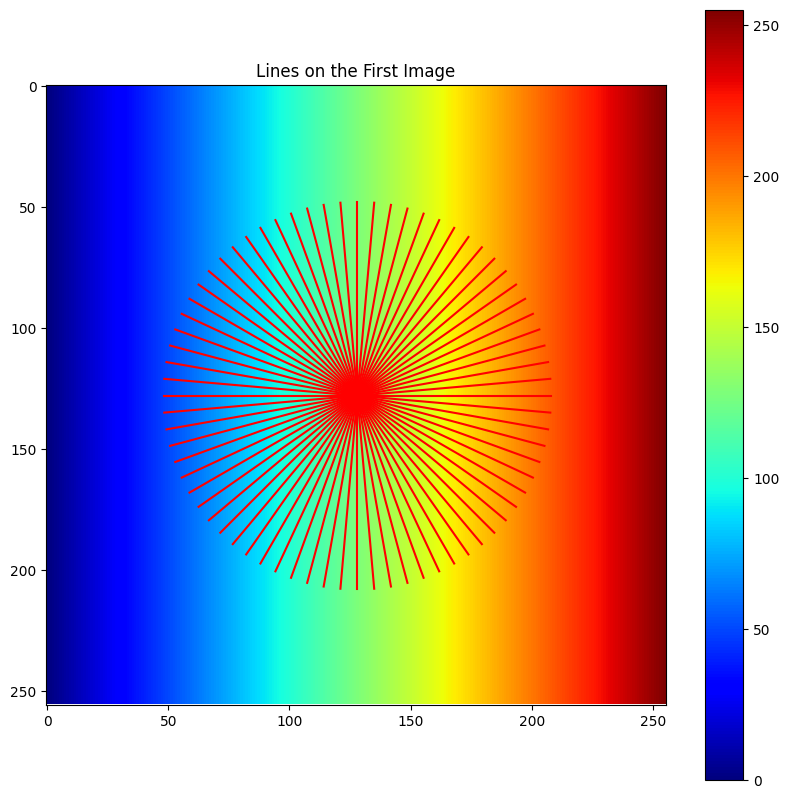

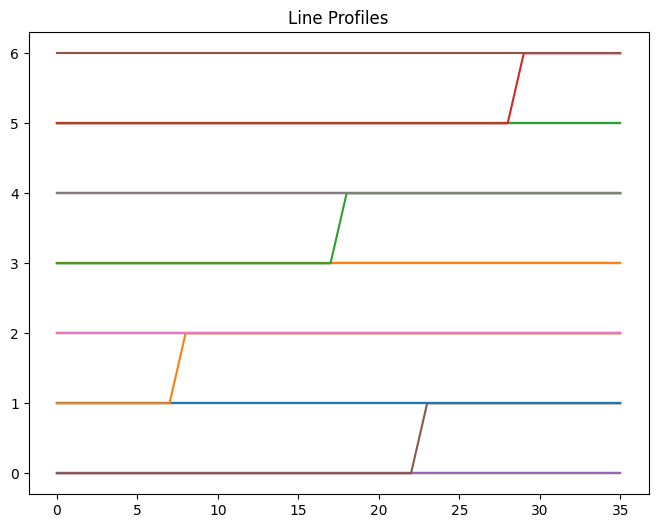

(36, 161, 1440)


In [2]:
import cupy as cp
from cupyx.scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt

def extract_line_profiles(image_stack, x_coords, y_coords):
    # Reshape the coordinates to be compatible with map_coordinates
    num_lines_per_image, num_pixels_per_line, num_images = x_coords.shape
    num_images=1440
    x_coords_flat = x_coords.reshape(num_lines_per_image * num_pixels_per_line * num_images)
    y_coords_flat = y_coords.reshape(num_lines_per_image * num_pixels_per_line * num_images)
    print('x_coords_flat.shape',x_coords_flat.shape)
    print('y_coords_flat.shape',y_coords_flat.shape)
    print('x_coords_flat.max',x_coords_flat.max())
    print('y_coords_flat.max',y_coords_flat.max())
    # Stack the coordinates
    coordinates = cp.vstack((y_coords_flat, x_coords_flat))
    print('coordinates.shape',coordinates.shape)
    print('coordinates.max',coordinates.max())
    print('coordinates[:,0],coordinates[:,1],coordinates[:,100]',coordinates[:,0],coordinates[:,1],coordinates[:,2],coordinates[:,100])
    # Reshape the coordinates back to the original shape
    # Flatten the image stack
    flattened_image_stack = image_stack.reshape(256, -1)
    print('flattened_image_stack.shape',flattened_image_stack.shape)
    # Use map_coordinates to extract the line profiles
    line_profiles_flat = map_coordinates(flattened_image_stack, coordinates, order=1, mode='nearest')

    # Reshape the result to get the original structure back
    line_profiles = line_profiles_flat.reshape(num_lines_per_image, num_pixels_per_line, num_images)
    print('line_profiles.shape',line_profiles.shape)
    return line_profiles

def extract_features_vectorized(image_stack, num_lines=37, pixel_size=1, r=80):
    angles = cp.linspace(0, 180, num_lines)
    length_of_line = 2 * r + 1
    num_lines_per_image = num_lines - 1

    x_center, y_center = 128, 128

    theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)

    x1 = -r * cp.cos(theta_rad) + x_center
    y1 = -r * cp.sin(theta_rad) + y_center
    x2 = r * cp.cos(theta_rad) + x_center
    y2 = r * cp.sin(theta_rad) + y_center

    y_coords = cp.linspace(y1, y2, num=length_of_line, axis=-1).transpose(0, 2, 1)
    x_coords = cp.linspace(x1, x2, num=length_of_line, axis=-1).transpose(0, 2, 1)
    print('x_coords.shape',x_coords.shape)
    print('y_coords.shape',y_coords.shape)

    # Adjust x_coords for each image
    x_coords_adjusted = cp.zeros((num_lines_per_image, length_of_line, 1440))
    for i in range(1440):
        x_coords_adjusted[:, :, i] = x_coords[:, :, 0] + 256 * i
    print('x_coords_adjusted.shape',x_coords_adjusted.shape)
    print('y_coords.shape',y_coords.shape)
    # Repeat y_coords for each image
    y_coords_adjusted = cp.tile(y_coords, (1, 1, 1440))
    print('y_coords_adjusted.shape',y_coords_adjusted.shape)

    # Extract line profiles
    pj = extract_line_profiles(image_stack, x_coords_adjusted, y_coords_adjusted)
    print('pj.shape',pj.shape)
    return pj

# Create a gradient image stack for testing
image_stack = cp.zeros((256, 256, 1440))
for i in range(1440):
    image_stack[:, :, i] = cp.linspace(0, 255, 256)[None,:] #cp.linspace(0, 255, 256)[:, None]

print("Min of the first image", image_stack[:, :, 0].min())
print("Max of the first image", image_stack[:, :, 0].max())

angles = cp.linspace(0, 180, 37)
r = 80
x_center, y_center = 128, 128

theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)
x1 = -r * cp.cos(theta_rad) + x_center
y1 = -r * cp.sin(theta_rad) + y_center
x2 = r * cp.cos(theta_rad) + x_center
y2 = r * cp.sin(theta_rad) + y_center

x_coords = cp.linspace(x1, x2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
y_coords = cp.linspace(y1, y2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

print(y_coords.min(), y_coords.max())
print(x_coords.min(), x_coords.max())

print(x_coords.shape)
print(y_coords.shape)

pj = extract_features_vectorized(image_stack, num_lines=37, pixel_size=1, r=r)

# Plot the first image with lines overlay
plt.figure(figsize=(10, 10))
plt.imshow(image_stack[:, :, 0].get(), cmap='jet')
plt.colorbar()
for i in range(x_coords.shape[0]):
    plt.plot([x1[i, 0].get(), x2[i, 0].get()], [y1[i, 0].get(), y2[i, 0].get()], 'r-')
plt.title('Lines on the First Image')
plt.show()

# Plot the line profiles
plt.figure(figsize=(8, 6))
for i in range(x_coords.shape[0]):
    plt.plot(pj[:, 0, i].get())
# plt.ylim(0, 255)
plt.title('Line Profiles')
plt.show()

print(pj.shape)


# **Debug** the line profile extraction This works!::

In [109]:
# Create a gradient image stack for testing
image_stack = cp.zeros((256, 256, 1440))
for i in range(1440):
    image_stack[:, :, i] = cp.linspace(0, 255, 256)[:, None]# cp.linspace(0, 255, 256)[None,:] #cp.linspace(0, 255, 256)[:, None]

print("Min of the first image", image_stack[:, :, 0].min())
print("Max of the first image", image_stack[:, :, 0].max())

angles = cp.linspace(0, 180, 37)
r = 80
x_center, y_center = 128, 128

theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)
print(theta_rad.shape)
x1 = -r * cp.cos(theta_rad) + x_center
y1 = -r * cp.sin(theta_rad) + y_center
x2 = r * cp.cos(theta_rad) + x_center
y2 = r * cp.sin(theta_rad) + y_center

x_coords = cp.linspace(x1, x2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
y_coords = cp.linspace(y1, y2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

print(y_coords.min(), y_coords.max())
print(x_coords.min(), x_coords.max())

print(x_coords.shape)
print(y_coords.shape)

print(x_coords[0,:,0])

Min of the first image 0.0
Max of the first image 255.0
(36, 1)
48.0 208.0
48.0 208.0
(36, 161, 1)
(36, 161, 1)
[ 48.  49.  50.  51.  52.  53.  54.  55.  56.  57.  58.  59.  60.  61.
  62.  63.  64.  65.  66.  67.  68.  69.  70.  71.  72.  73.  74.  75.
  76.  77.  78.  79.  80.  81.  82.  83.  84.  85.  86.  87.  88.  89.
  90.  91.  92.  93.  94.  95.  96.  97.  98.  99. 100. 101. 102. 103.
 104. 105. 106. 107. 108. 109. 110. 111. 112. 113. 114. 115. 116. 117.
 118. 119. 120. 121. 122. 123. 124. 125. 126. 127. 128. 129. 130. 131.
 132. 133. 134. 135. 136. 137. 138. 139. 140. 141. 142. 143. 144. 145.
 146. 147. 148. 149. 150. 151. 152. 153. 154. 155. 156. 157. 158. 159.
 160. 161. 162. 163. 164. 165. 166. 167. 168. 169. 170. 171. 172. 173.
 174. 175. 176. 177. 178. 179. 180. 181. 182. 183. 184. 185. 186. 187.
 188. 189. 190. 191. 192. 193. 194. 195. 196. 197. 198. 199. 200. 201.
 202. 203. 204. 205. 206. 207. 208.]


In [110]:
 # Flatten the image stack
# flattened_image_stack = image_stack.reshape(256, -1)
# Correctly flatten the image stack
# flattened_image_stack = image_stack.transpose(1, 0, 2).reshape(256, -1)
# Flatten the image stack
flattened_image_stack = image_stack.transpose(0, 2, 1).reshape(256, -1)


print('flattened_image_stack.shape',flattened_image_stack.shape)

flattened_image_stack.shape (256, 368640)


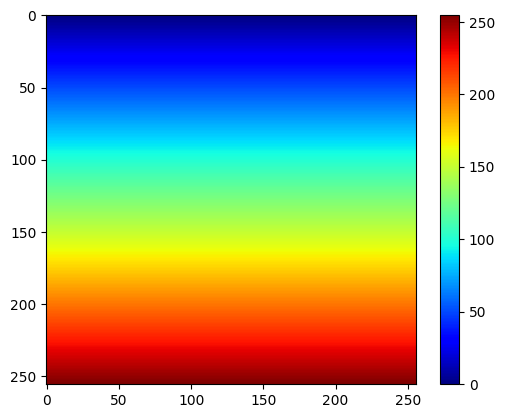

In [111]:
plt.imshow(flattened_image_stack[:,:256].get(),cmap='jet')
plt.colorbar()
plt.show()

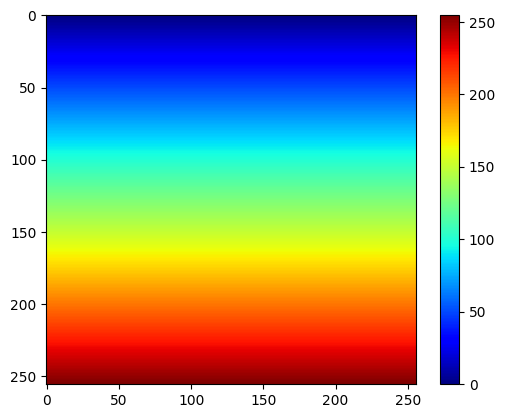

In [112]:
plt.imshow(image_stack[:, :, 0].get(),cmap='jet')
plt.colorbar()
plt.show()

In [113]:
 # Adjust x_coords for each image
num_lines_per_image, length_of_line, num_images = x_coords.shape
num_images=1440

x_coords_adjusted = cp.zeros((num_lines_per_image, length_of_line, 1440))
for i in range(1440):
    x_coords_adjusted[:, :, i] = x_coords[:, :, 0] + 256 * i
print('x_coords_adjusted.shape',x_coords_adjusted.shape)
print('y_coords.shape',y_coords.shape)
# Repeat y_coords for each image
y_coords_adjusted = cp.tile(y_coords, (1, 1, 1440))
print('y_coords_adjusted.shape',y_coords_adjusted.shape)

x_coords_adjusted.shape (36, 161, 1440)
y_coords.shape (36, 161, 1)
y_coords_adjusted.shape (36, 161, 1440)


In [114]:
# y_coords_adjusted[0,:,10]
x_coords_adjusted[0,:,2]

array([560., 561., 562., 563., 564., 565., 566., 567., 568., 569., 570.,
       571., 572., 573., 574., 575., 576., 577., 578., 579., 580., 581.,
       582., 583., 584., 585., 586., 587., 588., 589., 590., 591., 592.,
       593., 594., 595., 596., 597., 598., 599., 600., 601., 602., 603.,
       604., 605., 606., 607., 608., 609., 610., 611., 612., 613., 614.,
       615., 616., 617., 618., 619., 620., 621., 622., 623., 624., 625.,
       626., 627., 628., 629., 630., 631., 632., 633., 634., 635., 636.,
       637., 638., 639., 640., 641., 642., 643., 644., 645., 646., 647.,
       648., 649., 650., 651., 652., 653., 654., 655., 656., 657., 658.,
       659., 660., 661., 662., 663., 664., 665., 666., 667., 668., 669.,
       670., 671., 672., 673., 674., 675., 676., 677., 678., 679., 680.,
       681., 682., 683., 684., 685., 686., 687., 688., 689., 690., 691.,
       692., 693., 694., 695., 696., 697., 698., 699., 700., 701., 702.,
       703., 704., 705., 706., 707., 708., 709., 71

In [115]:
flattened_image_stack.shape

(256, 368640)

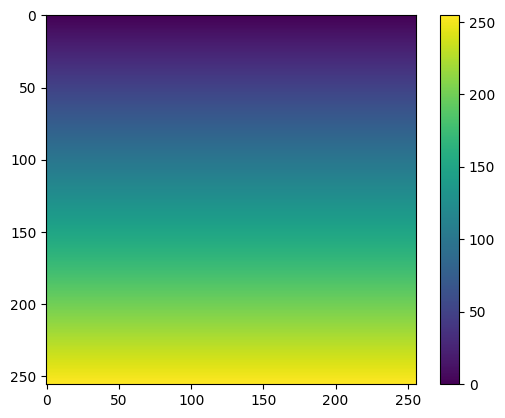

In [116]:
plt.imshow(flattened_image_stack[:,256:512].get())
plt.colorbar()
plt.show()

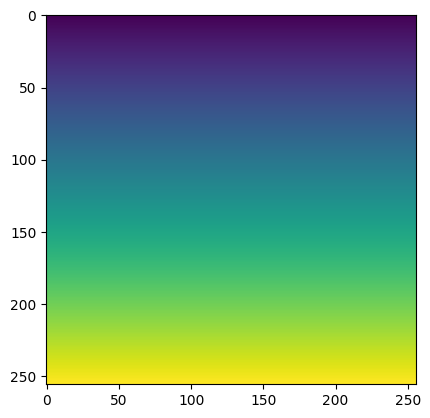

In [117]:
plt.imshow(image_stack[:, :, 1].get())

In [118]:
# y_coords_adjusted[0,:,10]
# x_coords_adjusted[0,:,10]

x_coords_flat = x_coords_adjusted.reshape(x_coords_adjusted.shape[0] * x_coords_adjusted.shape[1] * x_coords_adjusted.shape[2])
y_coords_flat = y_coords_adjusted.reshape(y_coords_adjusted.shape[0] * y_coords_adjusted.shape[1] * y_coords_adjusted.shape[2])
print('x_coords_flat.shape',x_coords_flat.shape)
print('y_coords_flat.shape',y_coords_flat.shape)
print('x_coords_flat.max',x_coords_flat.max())
print('y_coords_flat.max',y_coords_flat.max())
# Stack the coordinates
coordinates = cp.vstack((y_coords_flat, x_coords_flat))
print('coordinates.shape',coordinates.shape)
print('coordinates.max',coordinates.max())
print('coordinates[:,0],coordinates[:,1],coordinates[:,100]',coordinates[:,0],coordinates[:,1],coordinates[:,100])

x_coords_flat.shape (8346240,)
y_coords_flat.shape (8346240,)
x_coords_flat.max 368592.0
y_coords_flat.max 208.0
coordinates.shape (2, 8346240)
coordinates.max 368592.0
coordinates[:,0],coordinates[:,1],coordinates[:,100] [128.  48.] [128. 304.] [  128. 25648.]


In [119]:
coordinates.max()

array(368592.)

In [120]:
coordinates[:,2]

array([128., 560.])

In [121]:
# Use map_coordinates to extract the line profiles
line_profiles_flat = map_coordinates(flattened_image_stack, coordinates, order=1, mode='nearest')
# Reshape the result to get the original structure back
line_profiles = line_profiles_flat.reshape(x_coords_adjusted.shape[0],x_coords_adjusted.shape[1],x_coords_adjusted.shape[2])
print('line_profiles.shape',line_profiles.shape)

line_profiles.shape (36, 161, 1440)


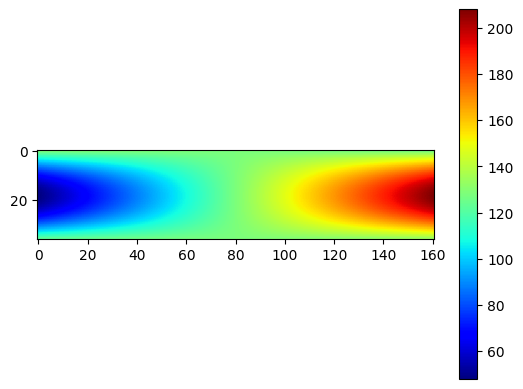

In [122]:
plt.imshow(line_profiles[:,:,0].get(),cmap='jet')
plt.colorbar()
plt.show()

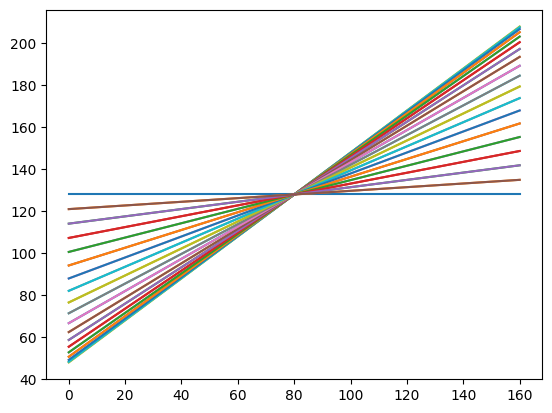

In [127]:
for i in range(line_profiles.shape[0]):
    plt.plot(line_profiles[i,:,1439].get())

In [59]:
coordinates_reshaped=coordinates.reshape(2,x_coords_adjusted.shape[0],x_coords_adjusted.shape[1],x_coords_adjusted.shape[2])
coordinates_reshaped.shape

coordinates_reshaped[:,0,:,0]

array([[128., 128., 128., 128., 128., 128., 128., 128., 128., 128., 128.,
        128., 128., 128., 128., 128., 128., 128., 128., 128., 128., 128.,
        128., 128., 128., 128., 128., 128., 128., 128., 128., 128., 128.,
        128., 128., 128., 128., 128., 128., 128., 128., 128., 128., 128.,
        128., 128., 128., 128., 128., 128., 128., 128., 128., 128., 128.,
        128., 128., 128., 128., 128., 128., 128., 128., 128., 128., 128.,
        128., 128., 128., 128., 128., 128., 128., 128., 128., 128., 128.,
        128., 128., 128., 128., 128., 128., 128., 128., 128., 128., 128.,
        128., 128., 128., 128., 128., 128., 128., 128., 128., 128., 128.,
        128., 128., 128., 128., 128., 128., 128., 128., 128., 128., 128.,
        128., 128., 128., 128., 128., 128., 128., 128., 128., 128., 128.,
        128., 128., 128., 128., 128., 128., 128., 128., 128., 128., 128.,
        128., 128., 128., 128., 128., 128., 128., 128., 128., 128., 128.,
        128., 128., 128., 128., 128., 

In [128]:
line_profiles.shape

(36, 161, 1440)

# Wrap up in a function

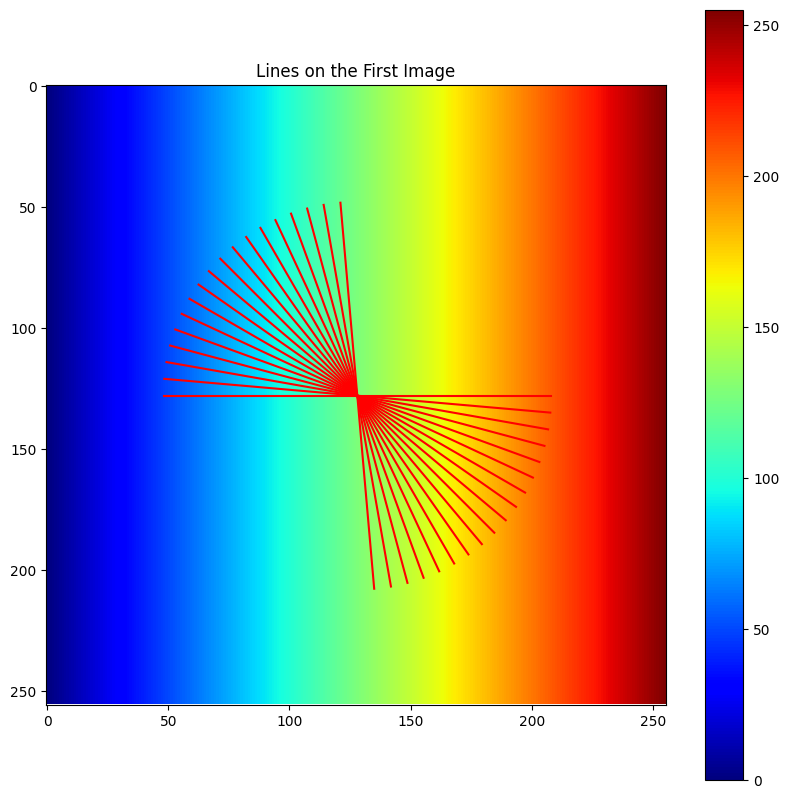

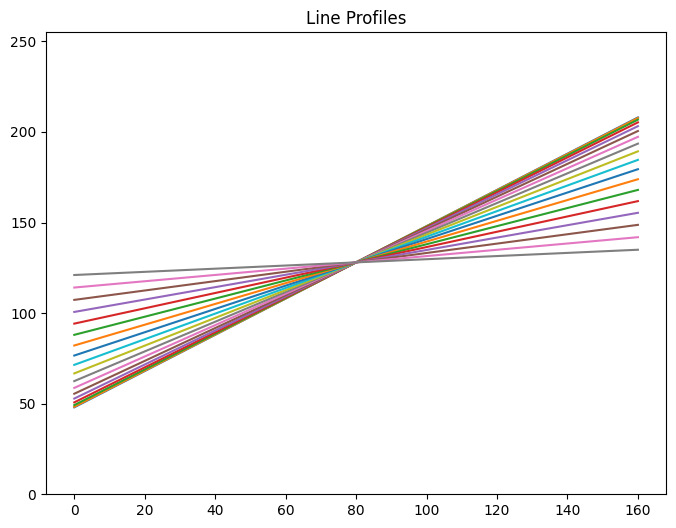

(36, 161, 1440)


In [136]:
import cupy as cp
from cupyx.scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt

def extract_line_profiles_from_stack(image_stack):
    angles = cp.linspace(0, 180, 37)
    r = 80
    x_center, y_center = 128, 128

    theta_rad = cp.radians(angles[:-1]).reshape(-1, 1)
    x1 = -r * cp.cos(theta_rad) + x_center
    y1 = -r * cp.sin(theta_rad) + y_center
    x2 = r * cp.cos(theta_rad) + x_center
    y2 = r * cp.sin(theta_rad) + y_center

    x_coords = cp.linspace(x1, x2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)
    y_coords = cp.linspace(y1, y2, num=2 * r + 1, axis=-1).transpose(0, 2, 1)

    flattened_image_stack = image_stack.transpose(0, 2, 1).reshape(256, -1)

    num_lines_per_image, length_of_line, num_images = x_coords.shape
    num_images = 1440

    x_coords_adjusted = cp.zeros((num_lines_per_image, length_of_line, 1440))
    for i in range(1440):
        x_coords_adjusted[:, :, i] = x_coords[:, :, 0] + 256 * i

    y_coords_adjusted = cp.tile(y_coords, (1, 1, 1440))

    x_coords_flat = x_coords_adjusted.reshape(-1)
    y_coords_flat = y_coords_adjusted.reshape(-1)

    coordinates = cp.vstack((y_coords_flat, x_coords_flat))

    line_profiles_flat = map_coordinates(flattened_image_stack, coordinates, order=1, mode='nearest')
    line_profiles = line_profiles_flat.reshape(num_lines_per_image, length_of_line, 1440)

    return line_profiles, x1, y1, x2, y2

# Create a gradient image stack for testing
image_stack = cp.zeros((256, 256, 1440))
for i in range(1440):
    image_stack[:, :, i] = cp.linspace(0, 255, 256)[None,:] # cp.linspace(0, 255, 256)[:, None]

line_profiles, x1, y1, x2, y2 = extract_line_profiles_from_stack(image_stack)

# Plot the first image with lines overlay
plt.figure(figsize=(10, 10))
plt.imshow(image_stack[:, :, 0].get(), cmap='jet')
plt.colorbar()
for i in range(int(x1.shape[0]/2)):
    plt.plot([x1[i, 0].get(), x2[i, 0].get()], [y1[i, 0].get(), y2[i, 0].get()], 'r-')
plt.title('Lines on the First Image')
plt.show()

# Plot the line profiles
plt.figure(figsize=(8, 6))
for i in range(int(line_profiles.shape[0]/2)):
    plt.plot(line_profiles[i, :, 0].get())
plt.ylim(0, 255)
plt.title('Line Profiles')
plt.show()

print(line_profiles.shape)


# Try to understand the indexing

In [ ]:
# Define input sequences of aberration coefficients
C1_offset_sequence = cp.array([-909, 909])
A3_amp_sequence = cp.array([0, 10, 20, 30])
A2_amp_sequence = cp.array([2,4, 8, 16,17,18])
C1_sequence = cp.linspace(-50, 50, 11)
C3_sequence = cp.array([ 1.2, 1.5,1.8,2,2.1,2.2])
A1_amp_sequence = cp.array([0, 10, 20])
A1_phase_sequence = cp.linspace(0, 180, 3)
A2_phase_sequence = cp.linspace(0, 120, 3)
A3_phase_sequence = cp.linspace(0, 90, 3)


In [ ]:
import cupy as cp
    # Create a meshgrid of all parameter combinations
C1_offsets, A3_amps, A2_amps, C1s, C3s, A1_amps, A1_phases, A2_phases, A3_phases = cp.meshgrid(
        C1_offset_sequence,
        A3_amp_sequence,
        A2_amp_sequence,
        C1_sequence,
        C3_sequence,
        A1_amp_sequence,
        A1_phase_sequence,
        A2_phase_sequence,
        A3_phase_sequence,
        indexing="ij",
    )

    # Flatten the meshgrid outputs
C1_offsets_flat = C1_offsets.ravel()
A3_amps_flat = A3_amps.ravel()
A2_amps_flat = A2_amps.ravel()
C1s_flat = C1s.ravel()
C3s_flat = C3s.ravel()
A1_amps_flat = A1_amps.ravel()
A1_phases_flat = A1_phases.ravel()
A2_phases_flat = A2_phases.ravel()
A3_phases_flat = A3_phases.ravel()

In [ ]:
C1_offsets_flat.shape

(256608,)

In [ ]:
i=0
while C1_offsets_flat[i]<0:
      i+=1
print(i)


128304


In [ ]:
i=0
for i in range(len(C1_offsets_flat)):
    if A3_amps_flat[i]==A3_amps_flat[i+128304]:
        print(i)
        break


0


In [ ]:
C1_offsets_flat.shape

(256608,)

In [ ]:
A3_amps_flat

array([ 0,  0,  0, ..., 30, 30, 30])

In [ ]:
def extract_and_save_features(CTF_tensor, batch_index, h5_file, group_name):
    # Compute the probe image
    Probe_image_Final = ac.compute_probe_image(CTF_tensor)

    # Extract features from the probe image
    Xigma_UF, Xigma_OF, Mu_UF, Mu_OF, Rou_UF, Rou_OF = ac.extract_features_vectorized(Probe_image_Final)

    # Save the extracted features to the HDF5 file
    group = h5_file.require_group(group_name)
    group.create_dataset(f'Xigma_UF_batch_{batch_index}', data=Xigma_UF.get())
    group.create_dataset(f'Xigma_OF_batch_{batch_index}', data=Xigma_OF.get())
    group.create_dataset(f'Mu_UF_batch_{batch_index}', data=Mu_UF.get())
    group.create_dataset(f'Mu_OF_batch_{batch_index}', data=Mu_OF.get())
    group.create_dataset(f'Rou_UF_batch_{batch_index}', data=Rou_UF.get())
    group.create_dataset(f'Rou_OF_batch_{batch_index}', data=Rou_OF.get())

    # Return the last processed Probe_image_Final
    return Probe_image_Final

In [ ]:
# Execute the processing
import aberration_computation as ac
import cupy as cp
import gc
import numpy as np
import h5py  # Using HDF5 for efficient storage

# Define input sequences of aberration coefficients
C1_offset_sequence = cp.array([-909, 909])
A3_amp_sequence = cp.array([0, 10, 20, 30])
A2_amp_sequence = cp.array([0, 1, 2, 4, 8, 16])
C1_sequence = cp.linspace(-50, 50, 11)
C3_sequence = cp.array([0, 0.3, 0.6, 0.9, 1.2, 1.5])
A1_amp_sequence = cp.array([0, 10, 20])
A1_phase_sequence = cp.linspace(0, 180, 3)
A2_phase_sequence = cp.linspace(0, 120, 3)
A3_phase_sequence = cp.linspace(0, 90, 3)

# Define other parameters
pix_dim = [256, 256]
real_dim = [1280, 1280]
eV = 0.8e3
app = 30  # example aperture size in mrad
optic_axis = [0, 0]  # Example optic axis
aperture_shift = [0, 0]  # Example aperture shift
tilt_units = "mrad"  # Example tilt units
df = 0  # Example defocus
app_units = "mrad"  # Example aperture units

# Calculate the total number of combinations
total_combinations = (len(C1_offset_sequence) *
                      len(A3_amp_sequence) *
                      len(A2_amp_sequence) *
                      len(C1_sequence) *
                      len(C3_sequence) *
                      len(A1_amp_sequence) *
                      len(A1_phase_sequence) *
                      len(A2_phase_sequence) *
                      len(A3_phase_sequence))

print(f"Total combinations: {total_combinations}")

# Define the batch size
batch_size = 2880

# Calculate the number of batches
num_batches = (total_combinations + batch_size - 1) // batch_size

print(f"Number of batches: {num_batches}")

# Save the results to an HDF5 file
with h5py.File('results.h5', 'w') as f:
    # Save aberration coefficients once
    f.create_dataset('C1_offset_sequence', data=C1_offset_sequence.get())
    f.create_dataset('A3_amp_sequence', data=A3_amp_sequence.get())
    f.create_dataset('A2_amp_sequence', data=A2_amp_sequence.get())
    f.create_dataset('C1_sequence', data=C1_sequence.get())
    f.create_dataset('C3_sequence', data=C3_sequence.get())
    f.create_dataset('A1_amp_sequence', data=A1_amp_sequence.get())
    f.create_dataset('A1_phase_sequence', data=A1_phase_sequence.get())
    f.create_dataset('A2_phase_sequence', data=A2_phase_sequence.get())
    f.create_dataset('A3_phase_sequence', data=A3_phase_sequence.get())

    # Process each batch
    for batch_index in range(num_batches):
        print(f"Processing batch {batch_index + 1}/{num_batches}")

        # Compute the CTF tensor for the current batch
        CTF_tensor_batch = ac.make_contrast_transfer_function(
            pix_dim=pix_dim,
            real_dim=real_dim,
            eV=eV,
            app=app,
            optic_axis=optic_axis,
            aperture_shift=aperture_shift,
            tilt_units=tilt_units,
            df=df,
            C1_offset_sequence=C1_offset_sequence,
            A3_amp_sequence=A3_amp_sequence,
            A2_amp_sequence=A2_amp_sequence,
            C1_sequence=C1_sequence,
            C3_sequence=C3_sequence,
            A1_amp_sequence=A1_amp_sequence,
            A1_phase_sequence=A1_phase_sequence,
            A2_phase_sequence=A2_phase_sequence,
            A3_phase_sequence=A3_phase_sequence,
            batch_index=batch_index,
            batch_size=batch_size
        )

        # Extract and save features for the current batch
        last_Probe_image_Final = extract_and_save_features(CTF_tensor_batch, batch_index, f, group_name='features')

        # Free GPU memory
        del CTF_tensor_batch
        cp.get_default_memory_pool().free_all_blocks()
        gc.collect()

    # Save the last Probe_image_Final for reference or further processing
    with h5py.File('last_probe_image_final.h5', 'w') as last_f:
        last_f.create_dataset('Probe_image_Final', data=last_Probe_image_Final.get())

print("All batches processed and saved.")


Total combinations: 256608
Number of batches: 90
Processing batch 1/90
Shape of Probe_image_Final: (256, 256, 2880)
batch_shape: (2880,)
num_images: 2880
Shape of Probe_image_Final_UF: (256, 256, 1440)
Shape of Probe_image_Final_OF: (256, 256, 1440)
Shape of x_center_UF: (1440,)
Shape of y_center_UF: (1440,)
Shape of x_center_OF: (1440,)
Shape of y_center_OF: (1440,)
Shape of x1_UF: (36, 1440)
Shape of y1_UF: (36, 1440)
Shape of x2_UF: (36, 1440)
Shape of y2_UF: (36, 1440)
Shape of x1_OF: (36, 1440)
Shape of y1_OF: (36, 1440)
Shape of x2_OF: (36, 1440)
Shape of y2_OF: (36, 1440)
Shape of y_coords_UF: (36, 161, 1, 1440)
Shape of x_coords_UF: (36, 161, 1, 1440)
Shape of y_coords_OF: (36, 161, 1, 1440)
Shape of x_coords_OF: (36, 161, 1, 1440)
Shape of pj_UF: (161, 1, 1440)
Shape of pj_OF: (161, 1, 1440)
Shape of W_UF: (1, 1440)
Shape of T_UF: (1, 1440)
Shape of W_OF: (1, 1440)
Shape of T_OF: (1, 1440)


ValueError: operands could not be broadcast together with shapes (161, 1440) (36, 1440)

In [ ]:

def extract_and_save_features(CTF_tensor, batch_index, h5_file, group_name):
    # Compute the probe image
    Probe_image_Final = ac.compute_probe_image(CTF_tensor)

    # Extract features from the probe image
    Xigma_UF, Xigma_OF, Mu_UF, Mu_OF, Rou_UF, Rou_OF = ac.extract_features_vectorized(Probe_image_Final)

    # Save the extracted features to the HDF5 file
    group = h5_file.require_group(group_name)
    group.create_dataset(f'Xigma_UF_batch_{batch_index}', data=Xigma_UF.get())
    group.create_dataset(f'Xigma_OF_batch_{batch_index}', data=Xigma_OF.get())
    group.create_dataset(f'Mu_UF_batch_{batch_index}', data=Mu_UF.get())
    group.create_dataset(f'Mu_OF_batch_{batch_index}', data=Mu_OF.get())
    group.create_dataset(f'Rou_UF_batch_{batch_index}', data=Rou_UF.get())
    group.create_dataset(f'Rou_OF_batch_{batch_index}', data=Rou_OF.get())

    # Return the last processed Probe_image_Final
    return Probe_image_Final

# Execute the processing
import aberration_computation as ac
import cupy as cp
import gc
import numpy as np
import h5py  # Using HDF5 for efficient storage

# Define input sequences of aberration coefficients
C1_offset_sequence = cp.array([-909, 909])
A3_amp_sequence = cp.array([0, 10, 20, 30])
A2_amp_sequence = cp.array([0, 1, 2, 4, 8, 16])
C1_sequence = cp.linspace(-50, 50, 11)
C3_sequence = cp.array([0, 0.3, 0.6, 0.9, 1.2, 1.5])
A1_amp_sequence = cp.array([0, 10, 20])
A1_phase_sequence = cp.linspace(0, 180, 3)
A2_phase_sequence = cp.linspace(0, 120, 3)
A3_phase_sequence = cp.linspace(0, 90, 3)

# Define other parameters
pix_dim = [256, 256]
real_dim = [1280, 1280]
eV = 0.8e3
app = 30  # example aperture size in mrad
optic_axis = [0, 0]  # Example optic axis
aperture_shift = [0, 0]  # Example aperture shift
tilt_units = "mrad"  # Example tilt units
df = 0  # Example defocus
app_units = "mrad"  # Example aperture units

# Calculate the total number of combinations
total_combinations = (len(C1_offset_sequence) *
                      len(A3_amp_sequence) *
                      len(A2_amp_sequence) *
                      len(C1_sequence) *
                      len(C3_sequence) *
                      len(A1_amp_sequence) *
                      len(A1_phase_sequence) *
                      len(A2_phase_sequence) *
                      len(A3_phase_sequence))

print(f"Total combinations: {total_combinations}")

# Define the batch size
batch_size = 2880

# Calculate the number of batches
num_batches = (total_combinations + batch_size - 1) // batch_size

print(f"Number of batches: {num_batches}")

# Save the results to an HDF5 file
with h5py.File('results.h5', 'w') as f:
    # Save aberration coefficients once
    f.create_dataset('C1_offset_sequence', data=C1_offset_sequence.get())
    f.create_dataset('A3_amp_sequence', data=A3_amp_sequence.get())
    f.create_dataset('A2_amp_sequence', data=A2_amp_sequence.get())
    f.create_dataset('C1_sequence', data=C1_sequence.get())
    f.create_dataset('C3_sequence', data=C3_sequence.get())
    f.create_dataset('A1_amp_sequence', data=A1_amp_sequence.get())
    f.create_dataset('A1_phase_sequence', data=A1_phase_sequence.get())
    f.create_dataset('A2_phase_sequence', data=A2_phase_sequence.get())
    f.create_dataset('A3_phase_sequence', data=A3_phase_sequence.get())

    # Process each batch
    for batch_index in range(num_batches):
        print(f"Processing batch {batch_index + 1}/{num_batches}")

        # Compute the CTF tensor for the current batch
        CTF_tensor_batch = ac.make_contrast_transfer_function(
            pix_dim=pix_dim,
            real_dim=real_dim,
            eV=eV,
            app=app,
            optic_axis=optic_axis,
            aperture_shift=aperture_shift,
            tilt_units=tilt_units,
            df=df,
            C1_offset_sequence=C1_offset_sequence,
            A3_amp_sequence=A3_amp_sequence,
            A2_amp_sequence=A2_amp_sequence,
            C1_sequence=C1_sequence,
            C3_sequence=C3_sequence,
            A1_amp_sequence=A1_amp_sequence,
            A1_phase_sequence=A1_phase_sequence,
            A2_phase_sequence=A2_phase_sequence,
            A3_phase_sequence=A3_phase_sequence,
            batch_index=batch_index,
            batch_size=batch_size
        )

        # Extract and save features for the current batch
        last_Probe_image_Final = extract_and_save_features(CTF_tensor_batch, batch_index, f, group_name='features')

        # Free GPU memory
        del CTF_tensor_batch
        cp.get_default_memory_pool().free_all_blocks()
        gc.collect()

    # Save the last Probe_image_Final for reference or further analysis
    f.create_dataset('last_Probe_image_Final', data=last_Probe_image_Final.get())

print("All batches processed and saved.")

Total combinations: 256608
Number of batches: 90
Processing batch 1/90
Shape of Probe_image_Final: (256, 256, 2880)
batch_shape: (2880,)
num_images: 2880
Shape of Probe_image_Final_UF: (256, 256, 1440)
Shape of Probe_image_Final_OF: (256, 256, 1440)
Shape of x_center_UF: (2,)
Shape of y_center_UF: (2,)
Shape of x_center_OF: (2,)
Shape of y_center_OF: (2,)
Shape of x1_UF: (36, 2)
Shape of y1_UF: (36, 2)
Shape of x2_UF: (36, 2)
Shape of y2_UF: (36, 2)
Shape of x1_OF: (36, 2)
Shape of y1_OF: (36, 2)
Shape of x2_OF: (36, 2)
Shape of y2_OF: (36, 2)
Shape of y_coords_UF: (36, 161, 1, 2)
Shape of x_coords_UF: (36, 161, 1, 2)
Shape of y_coords_OF: (36, 161, 1, 2)
Shape of x_coords_OF: (36, 161, 1, 2)
Shape of pj_UF: (161, 1, 2)
Shape of pj_OF: (161, 1, 2)
Shape of W_UF: (161, 2)
Shape of T_UF: (161, 2)
Shape of W_OF: (161, 2)
Shape of T_OF: (161, 2)


ValueError: operands could not be broadcast together with shapes (161, 2) (36, 1440)

In [ ]:
import aberration_computation as ac
import cupy as cp
import gc
import numpy as np
import h5py  # Using HDF5 for efficient storage

# Define input sequences of aberration coefficients
C1_offset_sequence = cp.array([-909, 909])
A3_amp_sequence = cp.array([0, 10, 20, 30])
A2_amp_sequence = cp.array([0, 1, 2, 4, 8, 16])
C1_sequence = cp.linspace(-50, 50, 11)
C3_sequence = cp.array([0, 0.3, 0.6, 0.9, 1.2, 1.5])
A1_amp_sequence = cp.array([0, 10, 20])
A1_phase_sequence = cp.linspace(0, 180, 3)  # cp.linspace(0, 180, 7)
A2_phase_sequence = cp.linspace(0, 120, 3)  # cp.linspace(0, 120, 5)
A3_phase_sequence = cp.linspace(0, 90, 3)  # cp.linspace(0, 90, 4)

# Define other parameters
pix_dim = [256, 256]
real_dim = [1280, 1280]
eV = 0.8e3
app = 30  # example aperture size in mrad
optic_axis = [0, 0]  # Example optic axis
aperture_shift = [0, 0]  # Example aperture shift
tilt_units = "mrad"  # Example tilt units
df = 0  # Example defocus
app_units = "mrad"  # Example aperture units

# Calculate the total number of combinations
total_combinations = (len(C1_offset_sequence) *
                      len(A3_amp_sequence) *
                      len(A2_amp_sequence) *
                      len(C1_sequence) *
                      len(C3_sequence) *
                      len(A1_amp_sequence) *
                      len(A1_phase_sequence) *
                      len(A2_phase_sequence) *
                      len(A3_phase_sequence))

print(f"Total combinations: {total_combinations}")

# Define the batch size
batch_size = 2880

# Calculate the number of batches
num_batches = (total_combinations + batch_size - 1) // batch_size

print(f"Number of batches: {num_batches}")

def extract_and_save_features(CTF_tensor, batch_index, h5_file, group_name='features'):
    # Compute the probe image for the current batch
    Probe_image_Final = ac.compute_probe_image(CTF_tensor, Sigma=2)

    # Print shape of Probe_image_Final
    print(f"Shape of Probe_image_Final: {Probe_image_Final.shape}")

    # Extract features from the probe image
    Xigma_UF, Xigma_OF, Mu_UF, Mu_OF, Rou_UF, Rou_OF = ac.extract_features_vectorized(Probe_image_Final)

    # Save the extracted features to the HDF5 file
    group = h5_file.require_group(group_name)
    group.create_dataset(f'Xigma_UF_batch_{batch_index}', data=Xigma_UF.get())
    group.create_dataset(f'Xigma_OF_batch_{batch_index}', data=Xigma_OF.get())
    group.create_dataset(f'Mu_UF_batch_{batch_index}', data=Mu_UF.get())
    group.create_dataset(f'Mu_OF_batch_{batch_index}', data=Mu_OF.get())
    group.create_dataset(f'Rou_UF_batch_{batch_index}', data=Rou_UF.get())
    group.create_dataset(f'Rou_OF_batch_{batch_index}', data=Rou_OF.get())

    # Return the last processed Probe_image_Final
    return Probe_image_Final

# Save the results to an HDF5 file
with h5py.File('results.h5', 'w') as f:
    # Save aberration coefficients once
    f.create_dataset('C1_offset_sequence', data=C1_offset_sequence.get())
    f.create_dataset('A3_amp_sequence', data=A3_amp_sequence.get())
    f.create_dataset('A2_amp_sequence', data=A2_amp_sequence.get())
    f.create_dataset('C1_sequence', data=C1_sequence.get())
    f.create_dataset('C3_sequence', data=C3_sequence.get())
    f.create_dataset('A1_amp_sequence', data=A1_amp_sequence.get())
    f.create_dataset('A1_phase_sequence', data=A1_phase_sequence.get())
    f.create_dataset('A2_phase_sequence', data=A2_phase_sequence.get())
    f.create_dataset('A3_phase_sequence', data=A3_phase_sequence.get())

    last_Probe_image_Final = None

    # Process each batch
    for batch_index in range(num_batches):
        print(f"Processing batch {batch_index + 1}/{num_batches}")

        # Compute the CTF tensor for the current batch
        CTF_tensor_batch = ac.make_contrast_transfer_function(
            pix_dim=pix_dim,
            real_dim=real_dim,
            eV=eV,
            app=app,
            optic_axis=optic_axis,
            aperture_shift=aperture_shift,
            tilt_units=tilt_units,
            df=df,
            C1_offset_sequence=C1_offset_sequence,
            A3_amp_sequence=A3_amp_sequence,
            A2_amp_sequence=A2_amp_sequence,
            C1_sequence=C1_sequence,
            C3_sequence=C3_sequence,
            A1_amp_sequence=A1_amp_sequence,
            A1_phase_sequence=A1_phase_sequence,
            A2_phase_sequence=A2_phase_sequence,
            A3_phase_sequence=A3_phase_sequence,
            batch_index=batch_index,
            batch_size=batch_size
        )

        # Extract and save features for the current batch
        last_Probe_image_Final = extract_and_save_features(CTF_tensor_batch, batch_index, f, group_name='features')

        # Free GPU memory
        del CTF_tensor_batch
        cp.get_default_memory_pool().free_all_blocks()
        gc.collect()

    # Save the last Probe_image_Final separately
    f.create_dataset('last_Probe_image_Final', data=last_Probe_image_Final.get())

print("All batches processed and saved.")


Total combinations: 256608
Number of batches: 90
Processing batch 1/90
Shape of Probe_image_Final: (256, 256, 2880)
Shape of Probe_image_Final: (256, 256, 2880)
batch_shape: (2880,)
num_images: 2880
Shape of Probe_image_Final_UF: (256, 256, 1440)
Shape of Probe_image_Final_OF: (256, 256, 1440)
Shape of x_center_UF: (2,)
Shape of y_center_UF: (2,)
Shape of x_center_OF: (2,)
Shape of y_center_OF: (2,)
Shape of x1_UF: (36, 2)
Shape of y1_UF: (36, 2)
Shape of x2_UF: (36, 2)
Shape of y2_UF: (36, 2)
Shape of x1_OF: (36, 2)
Shape of y1_OF: (36, 2)
Shape of x2_OF: (36, 2)
Shape of y2_OF: (36, 2)
Shape of y_coords_UF: (36, 161, 1, 2)
Shape of x_coords_UF: (36, 161, 1, 2)
Shape of y_coords_OF: (36, 161, 1, 2)
Shape of x_coords_OF: (36, 161, 1, 2)
Shape of pj_UF: (161, 1, 2)
Shape of pj_OF: (161, 1, 2)
Shape of W_UF: (161, 2)
Shape of T_UF: (161, 2)
Shape of W_OF: (161, 2)
Shape of T_OF: (161, 2)


ValueError: operands could not be broadcast together with shapes (161, 2) (36, 1440)

In [ ]:
import aberration_computation as ac
import cupy as cp
import gc
import numpy as np
import h5py  # Using HDF5 for efficient storage

# Define input sequences of aberration coefficients
C1_offset_sequence = cp.array([-909, 909])
A3_amp_sequence = cp.array([0, 10, 20, 30])
A2_amp_sequence = cp.array([0, 1, 2, 4, 8, 16])
C1_sequence = cp.linspace(-50, 50, 11)
C3_sequence = cp.array([0, 0.3, 0.6, 0.9, 1.2, 1.5])
A1_amp_sequence = cp.array([0, 10, 20])
A1_phase_sequence = cp.linspace(0, 180, 3)  # cp.linspace(0, 180, 7)
A2_phase_sequence = cp.linspace(0, 120, 3)  # cp.linspace(0, 120, 5)
A3_phase_sequence = cp.linspace(0, 90, 3)  # cp.linspace(0, 90, 4)

# Define other parameters
pix_dim = [256, 256]
real_dim = [1280, 1280]
eV = 0.8e3
app = 30  # example aperture size in mrad
optic_axis = [0, 0]  # Example optic axis
aperture_shift = [0, 0]  # Example aperture shift
tilt_units = "mrad"  # Example tilt units
df = 0  # Example defocus
app_units = "mrad"  # Example aperture units

# Calculate the total number of combinations
total_combinations = (len(C1_offset_sequence) *
                      len(A3_amp_sequence) *
                      len(A2_amp_sequence) *
                      len(C1_sequence) *
                      len(C3_sequence) *
                      len(A1_amp_sequence) *
                      len(A1_phase_sequence) *
                      len(A2_phase_sequence) *
                      len(A3_phase_sequence))

print(f"Total combinations: {total_combinations}")

# Define the batch size
batch_size = 2880

# Calculate the number of batches
num_batches = (total_combinations + batch_size - 1) // batch_size

print(f"Number of batches: {num_batches}")

def extract_and_save_features(CTF_tensor, batch_index, h5_file, group_name='features'):
    # Compute the probe image for the current batch
    Probe_image_Final = ac.compute_probe_image(CTF_tensor, Sigma=2)

    # Print shape of Probe_image_Final
    print(f"Shape of Probe_image_Final: {Probe_image_Final.shape}")

    # Extract features from the probe image
    Xigma_UF, Xigma_OF, Mu_UF, Mu_OF, Rou_UF, Rou_OF = ac.extract_features_vectorized(Probe_image_Final)

    # Save the extracted features to the HDF5 file
    group = h5_file.require_group(group_name)
    group.create_dataset(f'Xigma_UF_batch_{batch_index}', data=Xigma_UF.get())
    group.create_dataset(f'Xigma_OF_batch_{batch_index}', data=Xigma_OF.get())
    group.create_dataset(f'Mu_UF_batch_{batch_index}', data=Mu_UF.get())
    group.create_dataset(f'Mu_OF_batch_{batch_index}', data=Mu_OF.get())
    group.create_dataset(f'Rou_UF_batch_{batch_index}', data=Rou_UF.get())
    group.create_dataset(f'Rou_OF_batch_{batch_index}', data=Rou_OF.get())

    # Return the last processed Probe_image_Final
    return Probe_image_Final

# Save the results to an HDF5 file
with h5py.File('results.h5', 'w') as f:
    # Save aberration coefficients once
    f.create_dataset('C1_offset_sequence', data=C1_offset_sequence.get())
    f.create_dataset('A3_amp_sequence', data=A3_amp_sequence.get())
    f.create_dataset('A2_amp_sequence', data=A2_amp_sequence.get())
    f.create_dataset('C1_sequence', data=C1_sequence.get())
    f.create_dataset('C3_sequence', data=C3_sequence.get())
    f.create_dataset('A1_amp_sequence', data=A1_amp_sequence.get())
    f.create_dataset('A1_phase_sequence', data=A1_phase_sequence.get())
    f.create_dataset('A2_phase_sequence', data=A2_phase_sequence.get())
    f.create_dataset('A3_phase_sequence', data=A3_phase_sequence.get())

    last_Probe_image_Final = None

    # Process each batch
    for batch_index in range(num_batches):
        print(f"Processing batch {batch_index + 1}/{num_batches}")

        # Compute the CTF tensor for the current batch
        CTF_tensor_batch = ac.make_contrast_transfer_function(
            pix_dim=pix_dim,
            real_dim=real_dim,
            eV=eV,
            app=app,
            optic_axis=optic_axis,
            aperture_shift=aperture_shift,
            tilt_units=tilt_units,
            df=df,
            C1_offset_sequence=C1_offset_sequence,
            A3_amp_sequence=A3_amp_sequence,
            A2_amp_sequence=A2_amp_sequence,
            C1_sequence=C1_sequence,
            C3_sequence=C3_sequence,
            A1_amp_sequence=A1_amp_sequence,
            A1_phase_sequence=A1_phase_sequence,
            A2_phase_sequence=A2_phase_sequence,
            A3_phase_sequence=A3_phase_sequence,
            batch_index=batch_index,
            batch_size=batch_size
        )

        # Extract and save features for the current batch
        last_Probe_image_Final = extract_and_save_features(CTF_tensor_batch, batch_index, f, group_name='features')

        # Free GPU memory
        del CTF_tensor_batch
        cp.get_default_memory_pool().free_all_blocks()
        gc.collect()

    # Save the last Probe_image_Final separately
    f.create_dataset('last_Probe_image_Final', data=last_Probe_image_Final.get())

print("All batches processed and saved.")


Total combinations: 256608
Number of batches: 90
Processing batch 1/90
Shape of Probe_image_Final: (256, 256, 2880)


ValueError: cannot reshape array of size 65536 into shape (256, 256, 2880)

In [ ]:
import aberration_computation as ac
import cupy as cp
import gc
import numpy as np
import h5py  # Using HDF5 for efficient storage

# Define input sequences of aberration coefficients
C1_offset_sequence = cp.array([-909, 909])
A3_amp_sequence = cp.array([0, 10, 20, 30])
A2_amp_sequence = cp.array([0, 1, 2, 4, 8, 16])
C1_sequence = cp.linspace(-50, 50, 11)
C3_sequence = cp.array([0, 0.3, 0.6, 0.9, 1.2, 1.5])
A1_amp_sequence = cp.array([0, 10, 20])
A1_phase_sequence = cp.linspace(0, 180, 3)
A2_phase_sequence = cp.linspace(0, 120, 3)
A3_phase_sequence = cp.linspace(0, 90, 3)

# Define other parameters
pix_dim = [256, 256]
real_dim = [1280, 1280]
eV = 0.8e3
app = 30  # example aperture size in mrad
optic_axis = [0, 0]  # Example optic axis
aperture_shift = [0, 0]  # Example aperture shift
tilt_units = "mrad"  # Example tilt units
df = 0  # Example defocus
app_units = "mrad"  # Example aperture units

# Calculate the total number of combinations
total_combinations = (len(C1_offset_sequence) *
                      len(A3_amp_sequence) *
                      len(A2_amp_sequence) *
                      len(C1_sequence) *
                      len(C3_sequence) *
                      len(A1_amp_sequence) *
                      len(A1_phase_sequence) *
                      len(A2_phase_sequence) *
                      len(A3_phase_sequence))

print(f"Total combinations: {total_combinations}")

# Define the batch size
batch_size = 2880

# Calculate the number of batches
num_batches = (total_combinations + batch_size - 1) // batch_size

print(f"Number of batches: {num_batches}")

# Function to extract features and save to HDF5
def extract_and_save_features(CTF_tensor, batch_index, h5_file, group_name='features'):
    # Compute the probe image
    Probe_image_Final = ac.compute_probe_image(CTF_tensor, Sigma=2)

    # Extract features from the probe image
    Xigma_UF, Xigma_OF, Mu_UF, Mu_OF, Rou_UF, Rou_OF = ac.extract_features_vectorized(Probe_image_Final)

    # Save the extracted features to the HDF5 file
    group = h5_file.require_group(group_name)
    group.create_dataset(f'Xigma_UF_batch_{batch_index}', data=Xigma_UF.get())
    group.create_dataset(f'Xigma_OF_batch_{batch_index}', data=Xigma_OF.get())
    group.create_dataset(f'Mu_UF_batch_{batch_index}', data=Mu_UF.get())
    group.create_dataset(f'Mu_OF_batch_{batch_index}', data=Mu_OF.get())
    group.create_dataset(f'Rou_UF_batch_{batch_index}', data=Rou_UF.get())
    group.create_dataset(f'Rou_OF_batch_{batch_index}', data=Rou_OF.get())

    # Return the last processed Probe_image_Final
    return Probe_image_Final

# Save the results to an HDF5 file
with h5py.File('results.h5', 'w') as f:
    # Save aberration coefficients once
    f.create_dataset('C1_offset_sequence', data=C1_offset_sequence.get())
    f.create_dataset('A3_amp_sequence', data=A3_amp_sequence.get())
    f.create_dataset('A2_amp_sequence', data=A2_amp_sequence.get())
    f.create_dataset('C1_sequence', data=C1_sequence.get())
    f.create_dataset('C3_sequence', data=C3_sequence.get())
    f.create_dataset('A1_amp_sequence', data=A1_amp_sequence.get())
    f.create_dataset('A1_phase_sequence', data=A1_phase_sequence.get())
    f.create_dataset('A2_phase_sequence', data=A2_phase_sequence.get())
    f.create_dataset('A3_phase_sequence', data=A3_phase_sequence.get())

    last_Probe_image_Final = None

    # Process each batch
    for batch_index in range(num_batches):
        print(f"Processing batch {batch_index + 1}/{num_batches}")

        # Compute the CTF tensor for the current batch
        CTF_tensor_batch = ac.make_contrast_transfer_function(
            pix_dim=pix_dim,
            real_dim=real_dim,
            eV=eV,
            app=app,
            optic_axis=optic_axis,
            aperture_shift=aperture_shift,
            tilt_units=tilt_units,
            df=df,
            C1_offset_sequence=C1_offset_sequence,
            A3_amp_sequence=A3_amp_sequence,
            A2_amp_sequence=A2_amp_sequence,
            C1_sequence=C1_sequence,
            C3_sequence=C3_sequence,
            A1_amp_sequence=A1_amp_sequence,
            A1_phase_sequence=A1_phase_sequence,
            A2_phase_sequence=A2_phase_sequence,
            A3_phase_sequence=A3_phase_sequence,
            batch_index=batch_index,
            batch_size=batch_size
        )

        # Extract and save features for the current batch
        last_Probe_image_Final = extract_and_save_features(CTF_tensor_batch, batch_index, f, group_name='features')

        # Free GPU memory
        del CTF_tensor_batch
        cp.get_default_memory_pool().free_all_blocks()
        gc.collect()

    # Save the last Probe_image_Final separately
    f.create_dataset('last_Probe_image_Final', data=last_Probe_image_Final.get())

print("All batches processed and saved.")


Total combinations: 256608
Number of batches: 90
Processing batch 1/90
Shape of Probe_image_Final: (256, 256, 2880)
batch_shape: ()
num_images: 1
Shape of Probe_image_Final_UF: (256, 256, 1)
Shape of Probe_image_Final_OF: (256, 256, 1)
Shape of x_center_UF: (1,)
Shape of y_center_UF: (1,)
Shape of x_center_OF: (1,)
Shape of y_center_OF: (1,)
Shape of x1_UF: (36, 1)
Shape of y1_UF: (36, 1)
Shape of x2_UF: (36, 1)
Shape of y2_UF: (36, 1)
Shape of y_coords_UF: (36, 161, 1, 1)
Shape of x_coords_UF: (36, 161, 1, 1)
Shape of y_coords_OF: (36, 161, 1, 1)
Shape of x_coords_OF: (36, 161, 1, 1)
Shape of pj_UF: (161, 1, 1)
Shape of pj_OF: (161, 1, 1)
Shape of W_UF: (161, 1)
Shape of T_UF: (161, 1)
Shape of W_OF: (161, 1)
Shape of T_OF: (161, 1)
Shape of j_list_broadcast: (1, 161, 1)


ValueError: operands could not be broadcast together with shapes (161, 1) (36, 1)

In [ ]:
import aberration_computation as ac
import cupy as cp
import gc
import numpy as np
import h5py  # Using HDF5 for efficient storage

# Define input sequences of aberration coefficients
C1_offset_sequence = cp.array([-909, 909])
A3_amp_sequence = cp.array([0, 10, 20, 30])
A2_amp_sequence = cp.array([0, 1, 2, 4, 8, 16])
C1_sequence = cp.linspace(-50, 50, 11)
C3_sequence = cp.array([0, 0.3, 0.6, 0.9, 1.2, 1.5])
A1_amp_sequence = cp.array([0, 10, 20])
A1_phase_sequence = cp.linspace(0, 180, 3)  # cp.linspace(0, 180, 7)
A2_phase_sequence = cp.linspace(0, 120, 3)  # cp.linspace(0, 120, 5)
A3_phase_sequence = cp.linspace(0, 90, 3)  # cp.linspace(0, 90, 4)

# Define other parameters
pix_dim = [256, 256]
real_dim = [1280, 1280]
eV = 0.8e3
app = 30  # example aperture size in mrad
optic_axis = [0, 0]  # Example optic axis
aperture_shift = [0, 0]  # Example aperture shift
tilt_units = "mrad"  # Example tilt units
df = 0  # Example defocus
app_units = "mrad"  # Example aperture units

# Calculate the total number of combinations
total_combinations = (len(C1_offset_sequence) *
                      len(A3_amp_sequence) *
                      len(A2_amp_sequence) *
                      len(C1_sequence) *
                      len(C3_sequence) *
                      len(A1_amp_sequence) *
                      len(A1_phase_sequence) *
                      len(A2_phase_sequence) *
                      len(A3_phase_sequence))

print(f"Total combinations: {total_combinations}")

# Define the batch size
batch_size = 2880

# Calculate the number of batches
num_batches = (total_combinations + batch_size - 1) // batch_size

print(f"Number of batches: {num_batches}")

# Save the results to an HDF5 file
with h5py.File('results.h5', 'w') as f:
    # Save aberration coefficients once
    f.create_dataset('C1_offset_sequence', data=C1_offset_sequence.get())
    f.create_dataset('A3_amp_sequence', data=A3_amp_sequence.get())
    f.create_dataset('A2_amp_sequence', data=A2_amp_sequence.get())
    f.create_dataset('C1_sequence', data=C1_sequence.get())
    f.create_dataset('C3_sequence', data=C3_sequence.get())
    f.create_dataset('A1_amp_sequence', data=A1_amp_sequence.get())
    f.create_dataset('A1_phase_sequence', data=A1_phase_sequence.get())
    f.create_dataset('A2_phase_sequence', data=A2_phase_sequence.get())
    f.create_dataset('A3_phase_sequence', data=A3_phase_sequence.get())

    # Function to extract and save features for a batch
    def extract_and_save_features(CTF_tensor, batch_index, h5_file, group_name='features'):
        Probe_image_Final = ac.compute_probe_image(CTF_tensor, Sigma=2)

        # Extract features from the probe image
        Xigma_UF, Xigma_OF, Mu_UF, Mu_OF, Rou_UF, Rou_OF = ac.extract_features_vectorized(Probe_image_Final)

        # Save the extracted features to the HDF5 file
        group = h5_file.create_group(f'{group_name}/batch_{batch_index}')
        group.create_dataset('Xigma_UF', data=Xigma_UF.get())
        group.create_dataset('Xigma_OF', data=Xigma_OF.get())
        group.create_dataset('Mu_UF', data=Mu_UF.get())
        group.create_dataset('Mu_OF', data=Mu_OF.get())
        group.create_dataset('Rou_UF', data=Rou_UF.get())
        group.create_dataset('Rou_OF', data=Rou_OF.get())

        return Probe_image_Final

    # Process each batch
    for batch_index in range(num_batches):
        print(f"Processing batch {batch_index + 1}/{num_batches}")

        # Compute the CTF tensor for the current batch
        CTF_tensor_batch = ac.make_contrast_transfer_function(
            pix_dim=pix_dim,
            real_dim=real_dim,
            eV=eV,
            app=app,
            optic_axis=optic_axis,
            aperture_shift=aperture_shift,
            tilt_units=tilt_units,
            df=df,
            C1_offset_sequence=C1_offset_sequence,
            A3_amp_sequence=A3_amp_sequence,
            A2_amp_sequence=A2_amp_sequence,
            C1_sequence=C1_sequence,
            C3_sequence=C3_sequence,
            A1_amp_sequence=A1_amp_sequence,
            A1_phase_sequence=A1_phase_sequence,
            A2_phase_sequence=A2_phase_sequence,
            A3_phase_sequence=A3_phase_sequence,
            batch_index=batch_index,
            batch_size=batch_size
        )

        # Extract and save features for the current batch
        last_Probe_image_Final = extract_and_save_features(CTF_tensor_batch, batch_index, f, group_name='features')

        # Free GPU memory
        del CTF_tensor_batch
        cp.get_default_memory_pool().free_all_blocks()
        gc.collect()

    # Save the last Probe_image_Final to verify the final probe image
    f.create_dataset('last_Probe_image_Final', data=last_Probe_image_Final.get())

print("All batches processed and saved.")


Total combinations: 256608
Number of batches: 90
Processing batch 1/90
batch_shape: ()
num_images: 1
Shape of Probe_image_Final_UF: (256, 256, 1)
Shape of Probe_image_Final_OF: (256, 256, 1)
Shape of x_center_UF: (1,)
Shape of y_center_UF: (1,)
Shape of x_center_OF: (1,)
Shape of y_center_OF: (1,)
Shape of x1_UF: (36, 1)
Shape of y1_UF: (36, 1)
Shape of x2_UF: (36, 1)
Shape of y2_UF: (36, 1)
Shape of y_coords_UF: (36, 161, 1, 1)
Shape of x_coords_UF: (36, 161, 1, 1)
Shape of y_coords_OF: (36, 161, 1, 1)
Shape of x_coords_OF: (36, 161, 1, 1)
Shape of pj_UF: (161, 1, 1)
Shape of pj_OF: (161, 1, 1)
Shape of W_UF: (161, 1)
Shape of T_UF: (161, 1)
Shape of W_OF: (161, 1)
Shape of T_OF: (161, 1)
Shape of j_list_broadcast: (1, 161, 1)


ValueError: operands could not be broadcast together with shapes (161, 1) (36, 1)

In [ ]:
import aberration_computation as ac
import cupy as cp
import gc
import numpy as np
import h5py  # Using HDF5 for efficient storage

# Define input sequences of aberration coefficients
C1_offset_sequence = cp.array([-909, 909])
A3_amp_sequence = cp.array([0, 10, 20, 30])
A2_amp_sequence = cp.array([0, 1, 2, 4, 8, 16])
C1_sequence = cp.linspace(-50, 50, 11)
C3_sequence = cp.array([0, 0.3, 0.6, 0.9, 1.2, 1.5])
A1_amp_sequence = cp.array([0, 10, 20])
A1_phase_sequence = cp.linspace(0, 180, 3)
A2_phase_sequence = cp.linspace(0, 120, 3)
A3_phase_sequence = cp.linspace(0, 90, 3)

# Define other parameters
pix_dim = [256, 256]
real_dim = [1280, 1280]
eV = 0.8e3
app = 30  # example aperture size in mrad
optic_axis = [0, 0]  # Example optic axis
aperture_shift = [0, 0]  # Example aperture shift
tilt_units = "mrad"  # Example tilt units
df = 0  # Example defocus
app_units = "mrad"  # Example aperture units

# Calculate the total number of combinations
total_combinations = (len(C1_offset_sequence) *
                      len(A3_amp_sequence) *
                      len(A2_amp_sequence) *
                      len(C1_sequence) *
                      len(C3_sequence) *
                      len(A1_amp_sequence) *
                      len(A1_phase_sequence) *
                      len(A2_phase_sequence) *
                      len(A3_phase_sequence))

print(f"Total combinations: {total_combinations}")

# Define the batch size
batch_size = 2880

# Calculate the number of batches
num_batches = (total_combinations + batch_size - 1) // batch_size

print(f"Number of batches: {num_batches}")

# Function to extract features in batches
def extract_and_save_features(CTF_tensor, batch_index, h5_file, group_name):
    # Compute the probe image for the current batch
    Probe_image_Final = ac.compute_probe_image(CTF_tensor, Sigma=2)

    # Extract features from the probe image
    Xigma_UF, Xigma_OF, Mu_UF, Mu_OF, Rou_UF, Rou_OF = ac.extract_features_vectorized(Probe_image_Final)

    # Save the extracted features to the HDF5 file
    h5_file.create_dataset(f'{group_name}/Xigma_UF_batch_{batch_index}', data=Xigma_UF.get())
    h5_file.create_dataset(f'{group_name}/Xigma_OF_batch_{batch_index}', data=Xigma_OF.get())
    h5_file.create_dataset(f'{group_name}/Mu_UF_batch_{batch_index}', data=Mu_UF.get())
    h5_file.create_dataset(f'{group_name}/Mu_OF_batch_{batch_index}', data=Mu_OF.get())
    h5_file.create_dataset(f'{group_name}/Rou_UF_batch_{batch_index}', data=Rou_UF.get())
    h5_file.create_dataset(f'{group_name}/Rou_OF_batch_{batch_index}', data=Rou_OF.get())

    return Probe_image_Final

# Save the results to an HDF5 file on the local disk
with h5py.File('results.h5', 'w') as f:
    # Save aberration coefficients once
    f.create_dataset('C1_offset_sequence', data=C1_offset_sequence.get())
    f.create_dataset('A3_amp_sequence', data=A3_amp_sequence.get())
    f.create_dataset('A2_amp_sequence', data=A2_amp_sequence.get())
    f.create_dataset('C1_sequence', data=C1_sequence.get())
    f.create_dataset('C3_sequence', data=C3_sequence.get())
    f.create_dataset('A1_amp_sequence', data=A1_amp_sequence.get())
    f.create_dataset('A1_phase_sequence', data=A1_phase_sequence.get())
    f.create_dataset('A2_phase_sequence', data=A2_phase_sequence.get())
    f.create_dataset('A3_phase_sequence', data=A3_phase_sequence.get())

    last_Probe_image_Final = None

    # Process each batch
    for batch_index in range(num_batches):
        print(f"Processing batch {batch_index + 1}/{num_batches}")

        # Compute the CTF tensor for the current batch
        CTF_tensor_batch = ac.make_contrast_transfer_function(
            pix_dim=pix_dim,
            real_dim=real_dim,
            eV=eV,
            app=app,
            optic_axis=optic_axis,
            aperture_shift=aperture_shift,
            tilt_units=tilt_units,
            df=df,
            C1_offset_sequence=C1_offset_sequence,
            A3_amp_sequence=A3_amp_sequence,
            A2_amp_sequence=A2_amp_sequence,
            C1_sequence=C1_sequence,
            C3_sequence=C3_sequence,
            A1_amp_sequence=A1_amp_sequence,
            A1_phase_sequence=A1_phase_sequence,
            A2_phase_sequence=A2_phase_sequence,
            A3_phase_sequence=A3_phase_sequence,
            batch_index=batch_index,
            batch_size=batch_size
        )

        # Extract and save features for the current batch
        last_Probe_image_Final = extract_and_save_features(CTF_tensor_batch, batch_index, f, group_name='features')

        # Free GPU memory
        del CTF_tensor_batch
        cp.get_default_memory_pool().free_all_blocks()
        gc.collect()

# Save the last Probe_image_Final to a separate HDF5 file on the local disk
with h5py.File('last_probe_image_final.h5', 'w') as f:
    if last_Probe_image_Final is not None:
        f.create_dataset('last_Probe_image_Final', data=last_Probe_image_Final.get())

print("All batches processed and saved.")


Total combinations: 256608
Number of batches: 90
Processing batch 1/90


ValueError: operands could not be broadcast together with shapes (161, 161) (36, 1)

# Execute the module

In [ ]:
import aberration_computation as ac
import cupy as cp
import gc
import numpy as np
import h5py  # Using HDF5 for efficient storage

# Define input sequences of aberration coefficients
C1_offset_sequence = cp.array([-909, 909])
A3_amp_sequence = cp.array([0, 10, 20, 30])
A2_amp_sequence = cp.array([0, 1, 2, 4, 8, 16])
C1_sequence = cp.linspace(-50, 50, 11)
C3_sequence = cp.array([0, 0.3, 0.6, 0.9, 1.2, 1.5])
A1_amp_sequence = cp.array([0, 10, 20])
A1_phase_sequence = cp.linspace(0, 180, 3) #cp.linspace(0, 180, 7)
A2_phase_sequence = cp.linspace(0, 120, 3) # cp.linspace(0, 120, 5)
A3_phase_sequence = cp.linspace(0, 90, 3) # cp.linspace(0, 90, 4)

# Define other parameters
pix_dim = [256, 256]
real_dim = [1280, 1280]
eV = 0.8e3
app = 30  # example aperture size in mrad
optic_axis = [0, 0]  # Example optic axis
aperture_shift = [0, 0]  # Example aperture shift
tilt_units = "mrad"  # Example tilt units
df = 0  # Example defocus
app_units = "mrad"  # Example aperture units

# Calculate the total number of combinations
total_combinations = (len(C1_offset_sequence) *
                      len(A3_amp_sequence) *
                      len(A2_amp_sequence) *
                      len(C1_sequence) *
                      len(C3_sequence) *
                      len(A1_amp_sequence) *
                      len(A1_phase_sequence) *
                      len(A2_phase_sequence) *
                      len(A3_phase_sequence))

print(f"Total combinations: {total_combinations}")

# Define the batch size
batch_size = 2880

# Calculate the number of batches
num_batches = (total_combinations + batch_size - 1) // batch_size

print(f"Number of batches: {num_batches}")

# Save the results to an HDF5 file
with h5py.File('results.h5', 'w') as f:
    # Save aberration coefficients once
    f.create_dataset('C1_offset_sequence', data=C1_offset_sequence.get())
    f.create_dataset('A3_amp_sequence', data=A3_amp_sequence.get())
    f.create_dataset('A2_amp_sequence', data=A2_amp_sequence.get())
    f.create_dataset('C1_sequence', data=C1_sequence.get())
    f.create_dataset('C3_sequence', data=C3_sequence.get())
    f.create_dataset('A1_amp_sequence', data=A1_amp_sequence.get())
    f.create_dataset('A1_phase_sequence', data=A1_phase_sequence.get())
    f.create_dataset('A2_phase_sequence', data=A2_phase_sequence.get())
    f.create_dataset('A3_phase_sequence', data=A3_phase_sequence.get())

    # Process each batch
    for batch_index in range(num_batches):
        print(f"Processing batch {batch_index + 1}/{num_batches}")

        # Compute the CTF tensor for the current batch
        CTF_tensor_batch = ac.make_contrast_transfer_function(
            pix_dim=pix_dim,
            real_dim=real_dim,
            eV=eV,
            app=app,
            optic_axis=optic_axis,
            aperture_shift=aperture_shift,
            tilt_units=tilt_units,
            df=df,
            C1_offset_sequence=C1_offset_sequence,
            A3_amp_sequence=A3_amp_sequence,
            A2_amp_sequence=A2_amp_sequence,
            C1_sequence=C1_sequence,
            C3_sequence=C3_sequence,
            A1_amp_sequence=A1_amp_sequence,
            A1_phase_sequence=A1_phase_sequence,
            A2_phase_sequence=A2_phase_sequence,
            A3_phase_sequence=A3_phase_sequence,
            batch_index=batch_index,
            batch_size=batch_size
        )

        # Compute the probe image for the current batch
        Probe_image_Final_batch = ac.compute_probe_image(CTF_tensor_batch, Sigma=2)

        # Save the batch results to the HDF5 file
        f.create_dataset(f'Probe_image_Final_batch_{batch_index}', data=Probe_image_Final_batch.get())

        # Free GPU memory
        del CTF_tensor_batch, Probe_image_Final_batch
        cp.get_default_memory_pool().free_all_blocks()
        gc.collect()

print("All batches processed and saved.")


Total combinations: 256608
Number of batches: 90
Processing batch 1/90
Processing batch 2/90
Processing batch 3/90


KeyboardInterrupt: 

# Mount Google Drive and save the big data directly to the drive

Mount the Google Drive first

In [ ]:
import aberration_computation as ac
import cupy as cp
import gc
import numpy as np
import h5py
import shutil
import os

def check_disk_usage(path="/"):
    total, used, free = shutil.disk_usage(path)
    print(f"Total: {total // (2**30)} GiB")
    print(f"Used: {used // (2**30)} GiB")
    print(f"Free: {free // (2**30)} GiB")
    return free // (2**30)

def save_incremental_results(batch_index, data, filename):
    with h5py.File(filename, 'a') as f:
        f.create_dataset(f'Probe_image_Final_batch_{batch_index}', data=data.get(), compression="gzip")
        print(f"Saved batch {batch_index} results to {filename}")

def delete_file(file_path):
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Deleted file: {file_path}")
    else:
        print(f"File not found: {file_path}")

# Define input sequences of aberration coefficients
C1_offset_sequence = cp.array([-909, 909])
A3_amp_sequence = cp.array([0, 10, 30, 60,100,150])
A2_amp_sequence = cp.array([0, 1, 2, 4, 8, 16])
C1_sequence = cp.linspace(-50, 50, 11)
C3_sequence = cp.array([0, 0.2, 0.5, 0.9, 1.4, 2])
A1_amp_sequence = cp.array([0, 10, 20, 40])
A1_phase_sequence = cp.linspace(0, 180, 6)
A2_phase_sequence = cp.linspace(0, 120, 5)
A3_phase_sequence = cp.linspace(0, 90, 4)

# Define other parameters
pix_dim = [256, 256]
real_dim = [1280, 1280]
eV = 0.8e3
app = 30  # example aperture size in mrad
optic_axis = [0, 0]  # Example optic axis
aperture_shift = [0, 0]  # Example aperture shift
tilt_units = "mrad"  # Example tilt units
df = 0  # Example defocus
app_units = "mrad"  # Example aperture units

# Calculate the total number of combinations
total_combinations = (len(C1_offset_sequence) *
                      len(A3_amp_sequence) *
                      len(A2_amp_sequence) *
                      len(C1_sequence) *
                      len(C3_sequence) *
                      len(A1_amp_sequence) *
                      len(A1_phase_sequence) *
                      len(A2_phase_sequence) *
                      len(A3_phase_sequence))

print(f"Total combinations: {total_combinations}")

# Define the batch size
batch_size = 2880

# Calculate the number of batches
num_batches = (total_combinations + batch_size - 1) // batch_size

print(f"Number of batches: {num_batches}")

# Path to save the results on Google Drive
drive_results_path = '/content/drive/Shareddrives/TMD_NIST/Aberration Simulations/results.h5'

# Save the results to an HDF5 file
with h5py.File(drive_results_path, 'w') as f:
    # Save aberration coefficients once
    f.create_dataset('C1_offset_sequence', data=C1_offset_sequence.get())
    f.create_dataset('A3_amp_sequence', data=A3_amp_sequence.get())
    f.create_dataset('A2_amp_sequence', data=A2_amp_sequence.get())
    f.create_dataset('C1_sequence', data=C1_sequence.get())
    f.create_dataset('C3_sequence', data=C3_sequence.get())
    f.create_dataset('A1_amp_sequence', data=A1_amp_sequence.get())
    f.create_dataset('A1_phase_sequence', data=A1_phase_sequence.get())
    f.create_dataset('A2_phase_sequence', data=A2_phase_sequence.get())
    f.create_dataset('A3_phase_sequence', data=A3_phase_sequence.get())

    # Process each batch
    for batch_index in range(num_batches):
        print(f"Processing batch {batch_index + 1}/{num_batches}")

        # Compute the CTF tensor for the current batch
        CTF_tensor_batch = ac.make_contrast_transfer_function(
            pix_dim=pix_dim,
            real_dim=real_dim,
            eV=eV,
            app=app,
            optic_axis=optic_axis,
            aperture_shift=aperture_shift,
            tilt_units=tilt_units,
            df=df,
            C1_offset_sequence=C1_offset_sequence,
            A3_amp_sequence=A3_amp_sequence,
            A2_amp_sequence=A2_amp_sequence,
            C1_sequence=C1_sequence,
            C3_sequence=C3_sequence,
            A1_amp_sequence=A1_amp_sequence,
            A1_phase_sequence=A1_phase_sequence,
            A2_phase_sequence=A2_phase_sequence,
            A3_phase_sequence=A3_phase_sequence,
            batch_index=batch_index,
            batch_size=batch_size
        )

        # Compute the probe image for the current batch
        Probe_image_Final_batch = ac.compute_probe_image(CTF_tensor_batch, Sigma=2)

        # Save the batch results to the HDF5 file on Google Drive
        save_incremental_results(batch_index, Probe_image_Final_batch, drive_results_path)

        # Free GPU memory
        del CTF_tensor_batch, Probe_image_Final_batch
        cp.get_default_memory_pool().free_all_blocks()
        gc.collect()

print("All batches processed and saved.")


Total combinations: 2280960
Number of batches: 792
Processing batch 1/792
Saved batch 0 results to /content/drive/Shareddrives/TMD_NIST/Aberration Simulations/results.h5
Processing batch 2/792
Saved batch 1 results to /content/drive/Shareddrives/TMD_NIST/Aberration Simulations/results.h5
Processing batch 3/792
Saved batch 2 results to /content/drive/Shareddrives/TMD_NIST/Aberration Simulations/results.h5
Processing batch 4/792
Saved batch 3 results to /content/drive/Shareddrives/TMD_NIST/Aberration Simulations/results.h5
Processing batch 5/792
Saved batch 4 results to /content/drive/Shareddrives/TMD_NIST/Aberration Simulations/results.h5
Processing batch 6/792
Saved batch 5 results to /content/drive/Shareddrives/TMD_NIST/Aberration Simulations/results.h5
Processing batch 7/792
Saved batch 6 results to /content/drive/Shareddrives/TMD_NIST/Aberration Simulations/results.h5
Processing batch 8/792
Saved batch 7 results to /content/drive/Shareddrives/TMD_NIST/Aberration Simulations/results.

KeyboardInterrupt: 

In [ ]:
import aberration_computation as ac
import cupy as cp
import gc
import numpy as np
import matplotlib.pyplot as plt

# Define input sequences of aberration coefficients
C1_offset_sequence = cp.array([-909, 909])
A3_amp_sequence = cp.array([0, 20])  # Reduce the size for testing
A2_amp_sequence = cp.array([0, 2])  # Reduce the size for testing
C1_sequence = cp.linspace(-50, 50, 5)
C3_sequence = cp.array([0, 0.3,0.6])
A1_amp_sequence = cp.array([0, 20, 40])
A1_phase_sequence = cp.linspace(0, 180, 2)
A2_phase_sequence = cp.linspace(0, 60, 2)
A3_phase_sequence = cp.linspace(0, 90, 2)

# Define other parameters
pix_dim = [256, 256]
real_dim = [1280, 1280]
eV = 0.8e3
app = 30  # example aperture size in mrad
optic_axis = [0, 0]  # Example optic axis
aperture_shift = [0, 0]  # Example aperture shift
tilt_units = "mrad"  # Example tilt units
df = 0  # Example defocus
app_units = "mrad"  # Example aperture units

# Compute the CTF tensor
CTF_tensor = ac.make_contrast_transfer_function(
    pix_dim=pix_dim,
    real_dim=real_dim,
    eV=eV,
    app=app,
    optic_axis=optic_axis,
    aperture_shift=aperture_shift,
    tilt_units=tilt_units,
    df=df,
    C1_offset_sequence=C1_offset_sequence,
    A3_amp_sequence=A3_amp_sequence,
    A2_amp_sequence=A2_amp_sequence,
    C1_sequence=C1_sequence,
    C3_sequence=C3_sequence,
    A1_amp_sequence=A1_amp_sequence,
    A1_phase_sequence=A1_phase_sequence,
    A2_phase_sequence=A2_phase_sequence,
    A3_phase_sequence=A3_phase_sequence
)

# Compute the probe image
Probe_image_Final = ac.compute_probe_image(CTF_tensor, Sigma=2)

# Save the results
ac.save_results(Probe_image_Final, {
    'C1_offset_sequence': C1_offset_sequence,
    'A3_amp_sequence': A3_amp_sequence,
    'A2_amp_sequence': A2_amp_sequence,
    'C1_sequence': C1_sequence,
    'C3_sequence': C3_sequence,
    'A1_amp_sequence': A1_amp_sequence,
    'A1_phase_sequence': A1_phase_sequence,
    'A2_phase_sequence': A2_phase_sequence,
    'A3_phase_sequence': A3_phase_sequence
}, 'results.npy')

del CTF_tensor, Probe_image_Final
cp.get_default_memory_pool().free_all_blocks()
gc.collect()
cp.get_default_memory_pool().free_all_blocks()
gc.collect()

0

In [ ]:
# del CTF_tensor, Probe_image_Final
cp.get_default_memory_pool().free_all_blocks()
gc.collect()
cp.get_default_memory_pool().free_all_blocks()
gc.collect()

0

In [ ]:
import numpy as np

In [ ]:
def load_results(filename):
    with open(filename, 'rb') as f:
        results = np.load(f, allow_pickle=True).item()
    return results

# Load the results
loaded_results = load_results('results.npy')

# Access the Probe_image_Final and aberrations
Probe_image_Final_loaded = loaded_results['Probe_image_Final']
aberrations_loaded = loaded_results['aberrations']


In [ ]:
Probe_image_Final_loaded.shape

(256, 256, 2, 2, 2, 5, 3, 3, 2, 2, 2)

In [ ]:
aberrations_loaded

{'C1_offset_sequence': array([-909,  909]),
 'A3_amp_sequence': array([ 0, 20]),
 'A2_amp_sequence': array([0, 2]),
 'C1_sequence': array([-50., -25.,   0.,  25.,  50.]),
 'C3_sequence': array([0. , 0.3, 0.6]),
 'A1_amp_sequence': array([ 0, 20, 40]),
 'A1_phase_sequence': array([  0., 180.]),
 'A2_phase_sequence': array([ 0., 60.]),
 'A3_phase_sequence': array([ 0., 90.])}

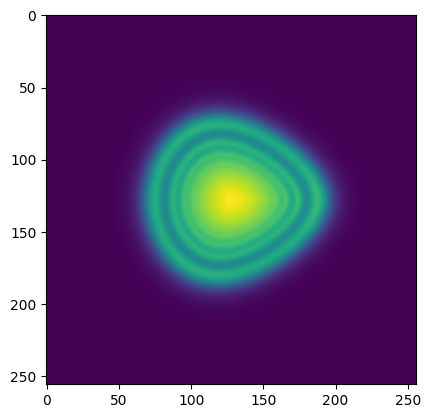

In [ ]:
plt.imshow(Probe_image_Final_loaded[:,:,1, 1, 1, 0, 1, 2, 1, 0, 1])

In [ ]:
index = 0  # Change this index to access different images
specific_image = Probe_image_Final_loaded[:, :, index]
specific_aberrations = {key: aberrations_loaded[key][index] for key in aberrations_loaded}


{'C1_offset': array(909), 'A3_amp': array(20), 'A2_amp': array(2), 'C1': array(-50.), 'C3': array(0.3), 'A1_amp': array(40), 'A1_phase': array(180.), 'A2_phase': array(0.), 'A3_phase': array(90.)}


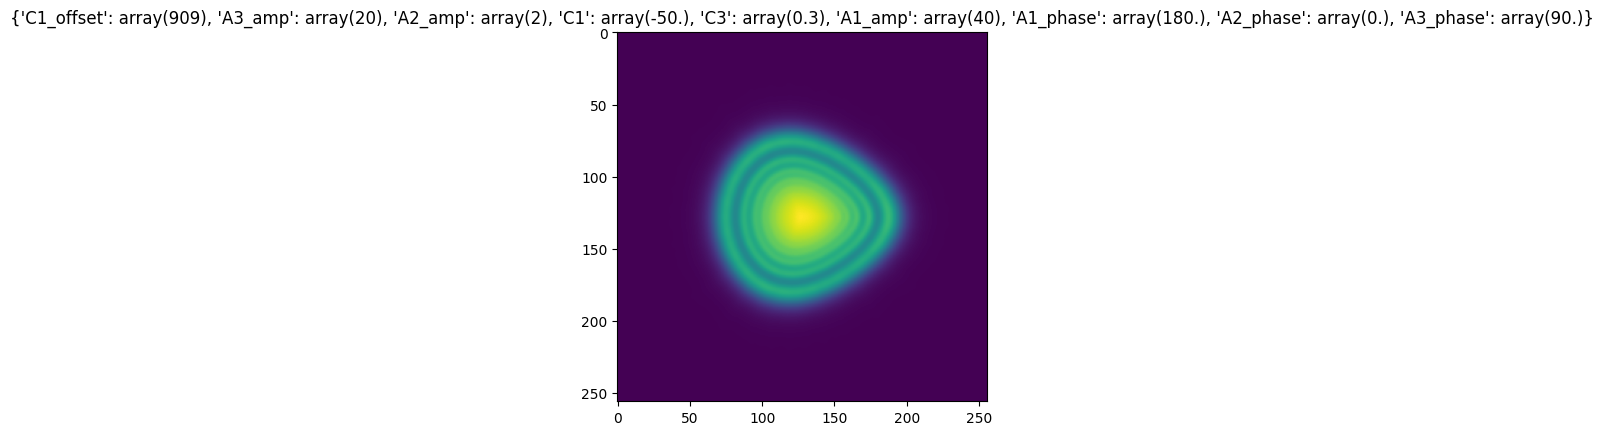

In [ ]:

def load_results(filename):
    with open(filename, 'rb') as f:
        results = np.load(f, allow_pickle=True).item()
    return results

# Load the results
loaded_results = load_results('results.npy')

# Access the images and aberrations
Probe_image_Final_loaded = loaded_results['Probe_image_Final']
aberrations_loaded = loaded_results['aberrations']

# Define the indices
C1_offset_index = 1
A3_amp_index = 1
A2_amp_index = 1
C1_index = 0
C3_index = 1
A1_amp_index = 2
A1_phase_index = 1
A2_phase_index = 0
A3_phase_index = 1

# Access the aberration coefficients
specific_aberrations = {
    'C1_offset': aberrations_loaded['C1_offset_sequence'][C1_offset_index],
    'A3_amp': aberrations_loaded['A3_amp_sequence'][A3_amp_index],
    'A2_amp': aberrations_loaded['A2_amp_sequence'][A2_amp_index],
    'C1': aberrations_loaded['C1_sequence'][C1_index],
    'C3': aberrations_loaded['C3_sequence'][C3_index],
    'A1_amp': aberrations_loaded['A1_amp_sequence'][A1_amp_index],
    'A1_phase': aberrations_loaded['A1_phase_sequence'][A1_phase_index],
    'A2_phase': aberrations_loaded['A2_phase_sequence'][A2_phase_index],
    'A3_phase': aberrations_loaded['A3_phase_sequence'][A3_phase_index]
}

print(specific_aberrations)

# Access the corresponding image from the Probe_image_Final
specific_image = Probe_image_Final_loaded[
    :, :,
    C1_offset_index, A3_amp_index, A2_amp_index,
    C1_index, C3_index, A1_amp_index,
    A1_phase_index, A2_phase_index, A3_phase_index
]

plt.imshow(specific_image)
plt.title(specific_aberrations)
plt.show()
